In [1]:
import random
import time
import os
import sys
# Automatically find and add the project root directory to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from tsai.all import *
from fastai.vision.all import *
from sklearn.model_selection import train_test_split
from fastai.callback.tracker import EarlyStoppingCallback
from fastai.vision.all import *
from torch.utils.data.dataset import ConcatDataset
from tsai.utils import set_seed
from sklearn.preprocessing import MinMaxScaler
from scipy.interpolate import interp1d
# from aeon.datasets import load_classification
# from sktime.datasets import load_UCR_UEA_dataset
from lomatce.explainer import LomatceExplainer
import lomatce.perturbation as perturbation 
import lomatce.utils.test_dataloader as test_loader




set_seed(1024)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = "cpu"
print(f"device: {device}")
my_setup()

device: cuda
os              : Windows-10-10.0.26200-SP0
python          : 3.11.13
tsai            : 0.3.9
fastai          : 2.7.14
fastcore        : 1.5.29
torch           : 2.2.2+cu118
device          : 1 gpu (['NVIDIA GeForce RTX 4050 Laptop GPU'])
cpu cores       : 14
threads per cpu : 1
RAM             : 15.68 GB
GPU memory      : [6.0] GB


In [2]:
# Set a random seed to ensure that the results are reproducible
random_seed = 45

torch.manual_seed(random_seed)
random.seed(random_seed)
np.random.seed(random_seed)

In [3]:
# List of univariate datasets from UCR archive
print(get_UCR_univariate_list())

# List of multivariate datasets from UCR archieve
print(get_UCR_multivariate_list())

['ACSF1', 'Adiac', 'AllGestureWiimoteX', 'AllGestureWiimoteY', 'AllGestureWiimoteZ', 'ArrowHead', 'Beef', 'BeetleFly', 'BirdChicken', 'BME', 'Car', 'CBF', 'Chinatown', 'ChlorineConcentration', 'CinCECGTorso', 'Coffee', 'Computers', 'CricketX', 'CricketY', 'CricketZ', 'Crop', 'DiatomSizeReduction', 'DistalPhalanxOutlineAgeGroup', 'DistalPhalanxOutlineCorrect', 'DistalPhalanxTW', 'DodgerLoopDay', 'DodgerLoopGame', 'DodgerLoopWeekend', 'Earthquakes', 'ECG200', 'ECG5000', 'ECGFiveDays', 'ElectricDevices', 'EOGHorizontalSignal', 'EOGVerticalSignal', 'EthanolLevel', 'FaceAll', 'FaceFour', 'FacesUCR', 'FiftyWords', 'Fish', 'FordA', 'FordB', 'FreezerRegularTrain', 'FreezerSmallTrain', 'Fungi', 'GestureMidAirD1', 'GestureMidAirD2', 'GestureMidAirD3', 'GesturePebbleZ1', 'GesturePebbleZ2', 'GunPoint', 'GunPointAgeSpan', 'GunPointMaleVersusFemale', 'GunPointOldVersusYoung', 'Ham', 'HandOutlines', 'Haptics', 'Herring', 'HouseTwenty', 'InlineSkate', 'InsectEPGRegularTrain', 'InsectEPGSmallTrain', 'I

In [4]:
dataset = 'ECG200'
dataset_name = dataset.lower()
model = 'TST'.lower()

cur_time = time.strftime('%Y-%m-%d_%H-%M-%S')
if 'cuda' in str(device):
    base_dir = f'results/{dataset_name}/{model}--{cur_time}' 
else:
    base_dir = f'results/ecg200--2023-12-28_16-37-54' 
#Create the base directory if not exist
os.makedirs(base_dir, exist_ok=True)

In [5]:
dsid= 'ECG200'
X, y, splits  = get_UCR_data(dsid, on_disk=True, return_split=False)

In [6]:
unique_classes, counts = np.unique(y, return_counts=True)
for cls, count in zip(unique_classes, counts):
    print(f"Class {cls}: {count} instances")

Class -1: 67 instances
Class 1: 133 instances


### Load and preprocess data

In [7]:
def data_preparation(X, y, test_size=0.3, random_state=12):
    # X_train, y_train = load_UCR_UEA_dataset(name=dataset, split='train', return_type='numpyflat')
    # X_test, y_test = load_UCR_UEA_dataset(name=dataset, split='test', return_type='numpyflat')
    # # Reshape the train and test data
    # X_train = X_train.reshape(-1, 1, X_train.shape[1])
    # X_test = X_test.reshape(-1, 1, X_test.shape[1])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, stratify=y, random_state=random_state)
    #Reserve 10% for validation, validation set is required in fastai
    X_test, X_valid, y_test, y_valid = train_test_split(X_test, y_test, test_size=0.5, stratify=y_test, random_state=random_state)


    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=12)
    # X_valid, X_test, y_valid, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=12)
    print(f'Shape of X_train :{X_train.shape}')
    print(f'Shape of y_train :{y_train.shape}')
    # X_valid, X_test, y_valid, y_test = train_test_split(X_test,y_test, test_size=0.65, random_state=1024)
    print(f'Shape of X_valid :{X_valid.shape}')
    print(f'Shape of X_test :{X_test.shape}')

    tfms  = [None, [Categorize()]]
    train_ds = TSDatasets(X_train, y_train, tfms=tfms)
    # valid_ds = TSDatasets(X_valid, y_valid, tfms=tfms)
    valid_ds = TSDatasets(X_valid, y_valid, tfms=tfms)


    combined_ds = ConcatDataset([train_ds, valid_ds])
    # print(combined_ds[0][0].shape)
    tfms = [None, [Categorize()]]
    # dls = get_ts_dls(combined_ds, tfms=tfms, bs=64)
    dls = TSDataLoaders.from_dsets(train_ds, valid_ds, bs=[8, 32], batch_tfms=[TSStandardize()], num_workers=0,  device=device, shuffle=True )
    print(f' Number of classes : {dls.c}')
    return dls, X_train, X_test, y_test, X_valid, y_valid

In [8]:
lomatce_explainer = LomatceExplainer(base_dir=base_dir)
dls, X_train, X_test, y_test, X_valid, y_valid = data_preparation(X, y)

Shape of X_train :(140, 1, 96)
Shape of y_train :(140,)
Shape of X_valid :(30, 1, 96)
Shape of X_test :(30, 1, 96)
 Number of classes : 2


### Build learner and train model

In [9]:
def trainer (model, dls, epochs=100, learning_rate=1e-3, patience=15):
    kwargs = {}
    metrics=[accuracy]
    path = f'{base_dir}/export'
    os.makedirs(path, exist_ok=True)
    # Create model
    model = create_model(model, dls=dls, **kwargs)
    # Define early stopping criteria
    early_stopping = EarlyStoppingCallback(monitor='valid_loss', min_delta=0.001, patience=patience)

    # Define a call back to save the best model
    save_callback = SaveModelCallback(monitor='accuracy')
    # Train and evaluate model with early stopping
    # set_seed(42)
    cbs = [early_stopping, save_callback,ShowGraph()]
    learn = Learner(dls=dls, model=model, opt_func=Adam, metrics=metrics,cbs=cbs) #
    learn.fit_one_cycle(epochs, learning_rate)
    learn.save_all(path=path, dls_fname='dls', model_fname='model', learner_fname='learner')
    return learn

def validator(learn, X_test, y_test):
    dls = learn.dls
    valid_dl = dls.valid
    train_dl = dls.train
    # Labelled test data
    test_ds = valid_dl.dataset.add_test(X_test, y_test)# In this case I'll use X and y, but this would be your test data
    test_dl = valid_dl.new(test_ds)
    test_probas, test_targets, test_preds = learn.get_preds(dl=test_dl, with_decoded=True, save_preds=None, save_targs=None)
    # print(f'Test Accuracy: {skm.accuracy_score(test_targets, test_preds):10.6f}')
    valid_probas, valid_targets, valid_preds = learn.get_preds(dl=valid_dl, with_decoded=True)
    train_probas, train_targets, train_preds = learn.get_preds(dl=train_dl, with_decoded=True)
    
    valid_accuracy = (valid_targets == valid_preds).float().mean()
    test_accuracy = (test_targets == test_preds).float().mean()
    train_accuracy = (train_targets == train_preds).float().mean()

    print(f"Validation Accuracy :{valid_accuracy:.2f}")
    print(f"Test Accuracy :{test_accuracy:.2f}")
    print(f"Train Accuracy :{train_accuracy:.2f}")
    valid_dl.show_batch(sharey=True)
    test_dl.show_batch(sharey=True)
    learn.show_results(max_n=9)

    return train_accuracy, valid_accuracy, test_accuracy, test_preds, valid_preds

Shape of X_train :(140, 1, 96)
Shape of y_train :(140,)
Shape of X_valid :(30, 1, 96)
Shape of X_test :(30, 1, 96)
 Number of classes : 2
Start training...


epoch,train_loss,valid_loss,accuracy,time
0,0.629886,0.534666,0.666667,00:00
1,0.533529,0.470271,0.766667,00:00
2,0.483311,0.432994,0.766667,00:00
3,0.444155,0.450411,0.800000,00:00
4,0.412696,0.420244,0.833333,00:00
5,0.380047,0.467839,0.733333,00:00
6,0.354170,0.491220,0.766667,00:00
7,0.342446,0.488235,0.833333,00:00
8,0.330769,0.476615,0.766667,00:00
9,0.314918,0.526807,0.866667,00:00


Better model found at epoch 0 with accuracy value: 0.6666666865348816.


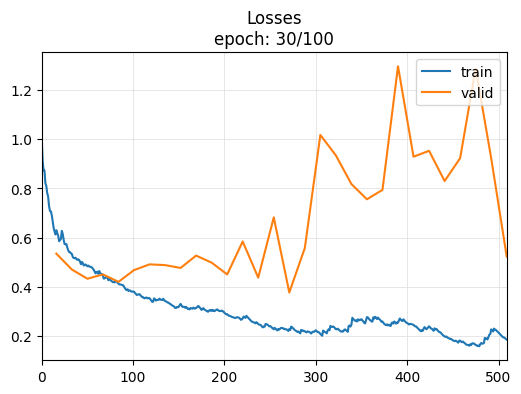

Better model found at epoch 1 with accuracy value: 0.7666667103767395.
Better model found at epoch 3 with accuracy value: 0.8000000715255737.
Better model found at epoch 4 with accuracy value: 0.8333333730697632.
Better model found at epoch 9 with accuracy value: 0.8666667342185974.
Better model found at epoch 15 with accuracy value: 0.9000000357627869.
Better model found at epoch 25 with accuracy value: 0.9333333969116211.
No improvement since epoch 15: early stopping


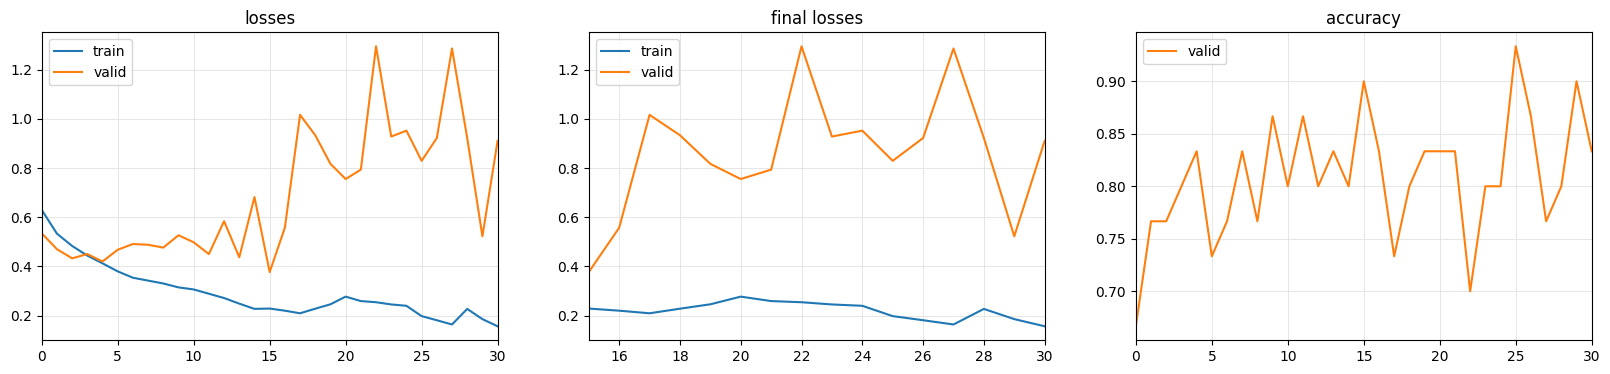

cuda


In [10]:
dls, X_train, X_test, y_test, X_valid, y_valid = data_preparation(X, y)
# Run the trainer function only if CUDA is available
if 'cuda' in str(device):
    print('Start training...')
    learn_new = trainer(TST, dls)
# else:
#     learn_new = load_learner_all(path=f'{base_dir}/export/',
#                                dls_fname='dls', model_fname='model', learner_fname='learner')
    # train_acc, valid_acc, test_acc, test_preds, valid_preds = validator(learn_new, X_test, y_test)
print(device)

Validation Accuracy :0.93
Test Accuracy :0.87
Train Accuracy :0.94


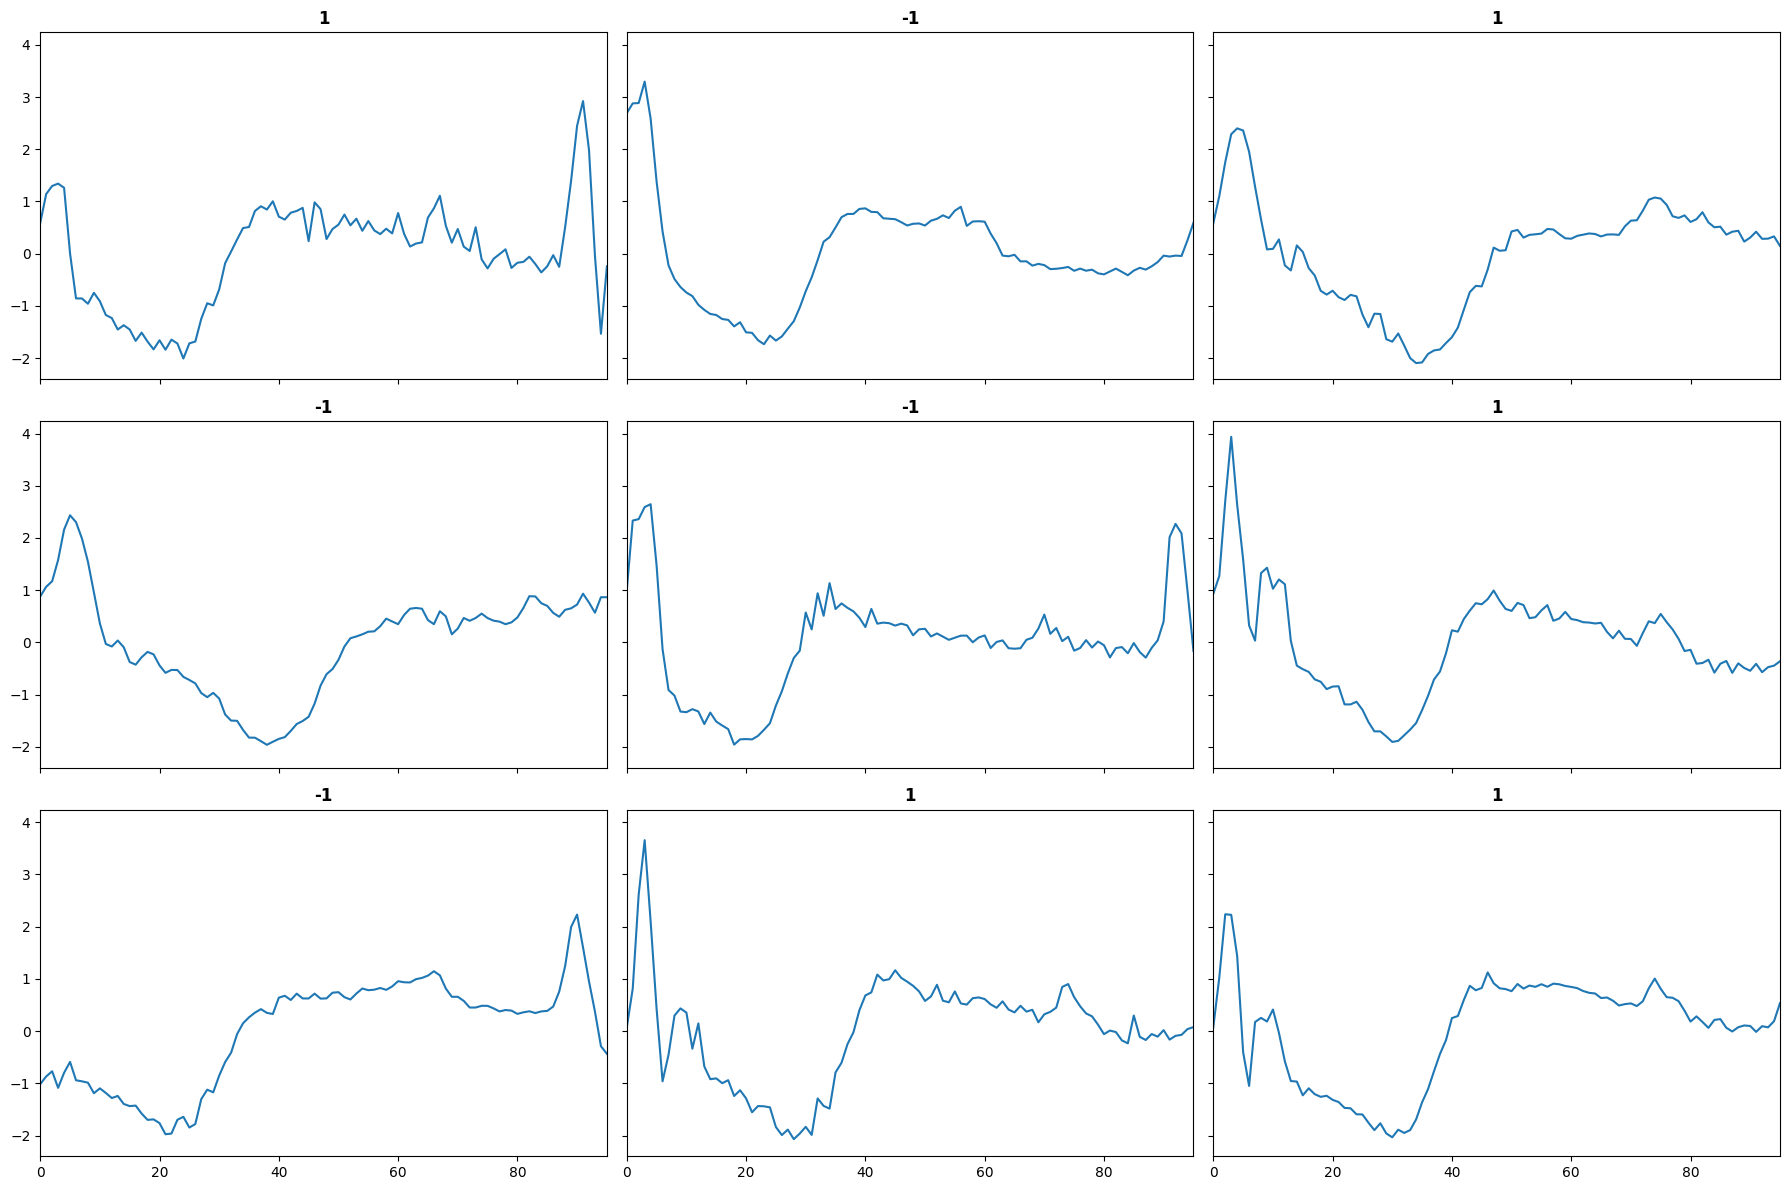

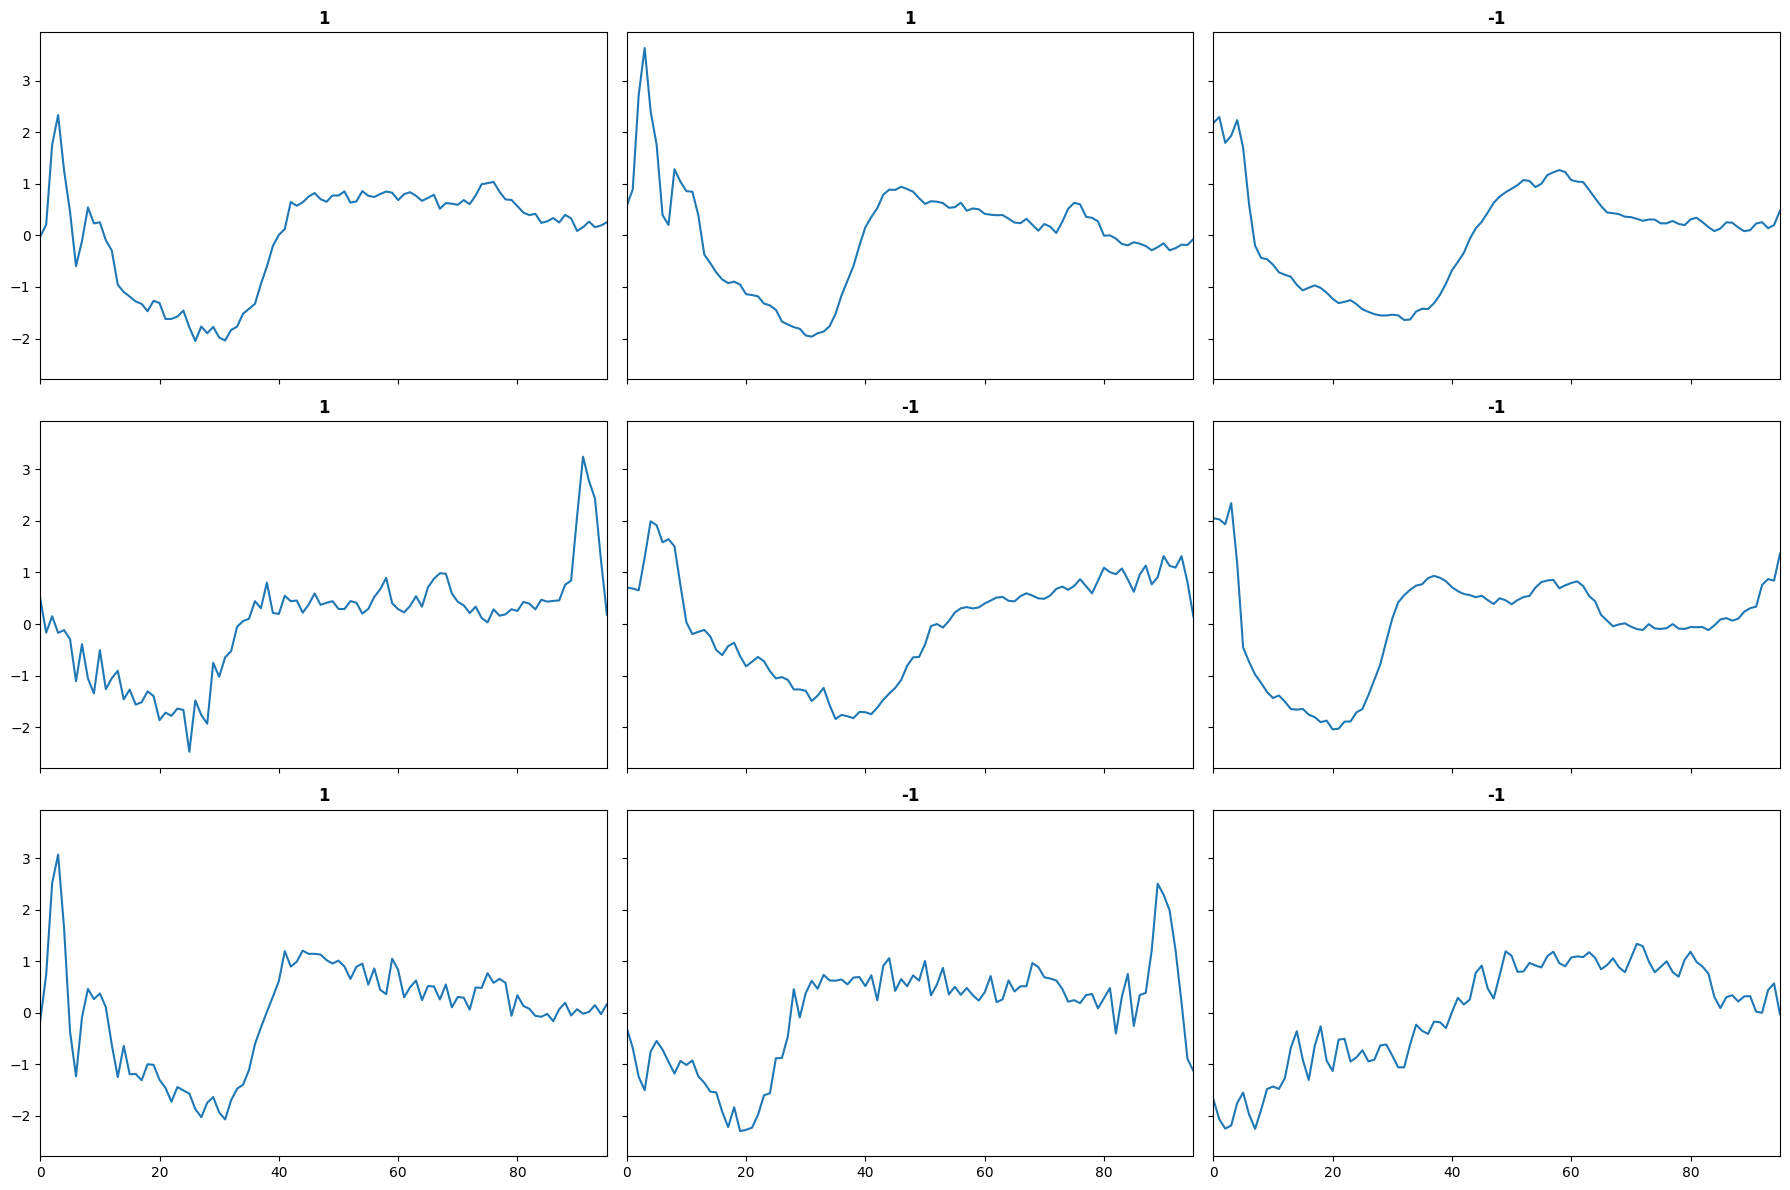

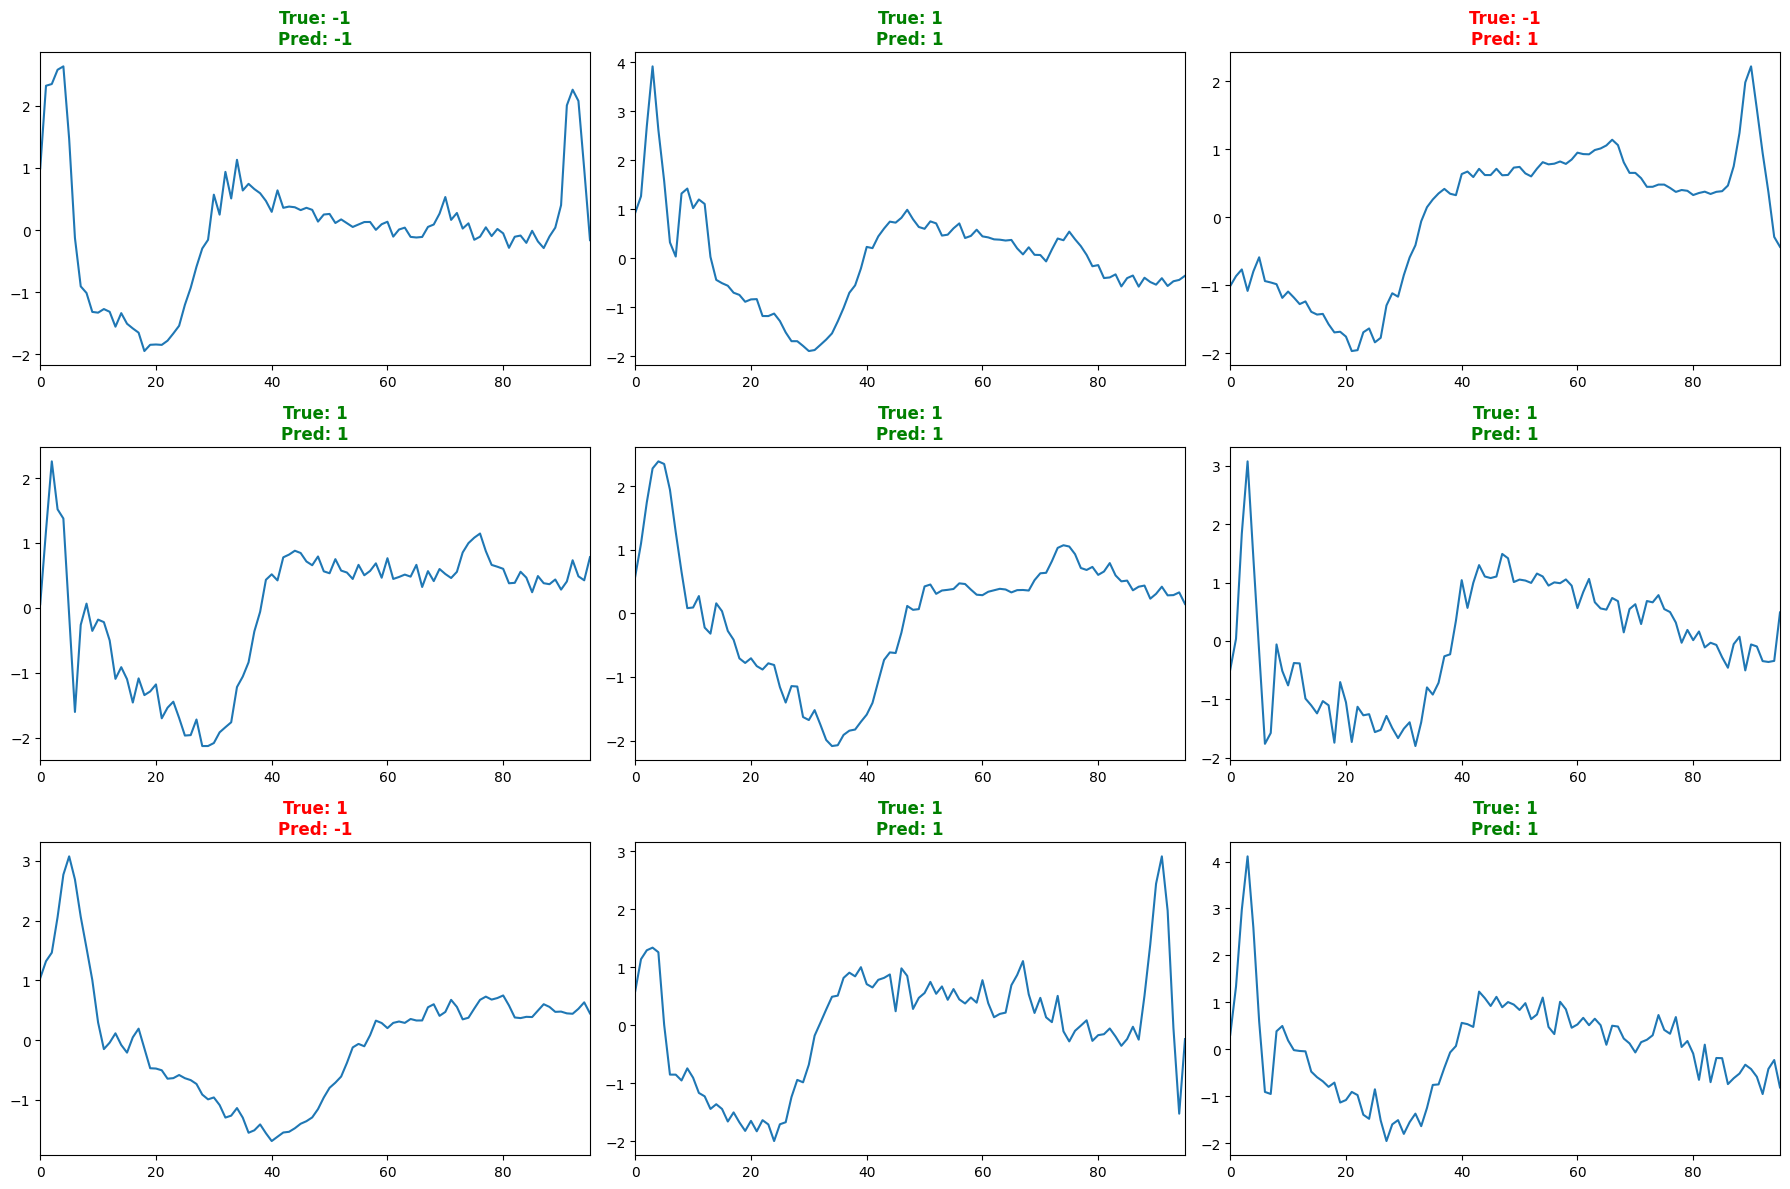

In [11]:
train_acc, valid_acc, test_acc, test_preds, valid_preds = validator(learn_new, X_test, y_test)

In [12]:
learn_new.summary()

not enough values to plot a chart


TST (Input shape: 8 x 1 x 96)
Layer (type)         Output Shape         Param #    Trainable 
                     8 x 96 x 128        
Linear                                    256        True      
Dropout                                                        
Linear                                    16384      True      
Linear                                    16384      True      
Linear                                    16384      True      
Linear                                    16384      True      
Dropout                                                        
____________________________________________________________________________
                     8 x 128 x 96        
Transpose                                                      
BatchNorm1d                               256        True      
____________________________________________________________________________
                     8 x 96 x 128        
Transpose                                         

In [13]:
class_labels = ['Myocardial Infarction','Normal Heartbeat']

In [14]:
def predict_fn(data, learner):
    if len(data.shape) == 2:
        data = data.reshape(data.shape[0], 1, data.shape[1])
    data_dl = test_loader.test_dataloader(learner, data)
    data_probas, _, data_preds = learner.get_preds(dl=data_dl, with_decoded=True, save_preds=None)
    return data_probas, data_preds

### Apply LOMATCE (LOcal Model-Agnostic Time-series Classifers Explanation)
LOMATCE is a novel Explainable AI (XAI) method designed specifically for time series classifiers. It generates explanations that preserve the temporal characteristics of time series data.

INFO:lomatce.explainer:Starting time series local explanation
INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 9203 samples)
Optimal number of clusters for Increasing_ch1: 16
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 12336 samples)
Optimal number of clusters for Decreasing_ch1: 18
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 23941 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 23658 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 72) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 72


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.18
INFO:lomatce.explainer:Local Prediction (Linear Model): 1.01
INFO:lomatce.explainer:Model Type: Ridge


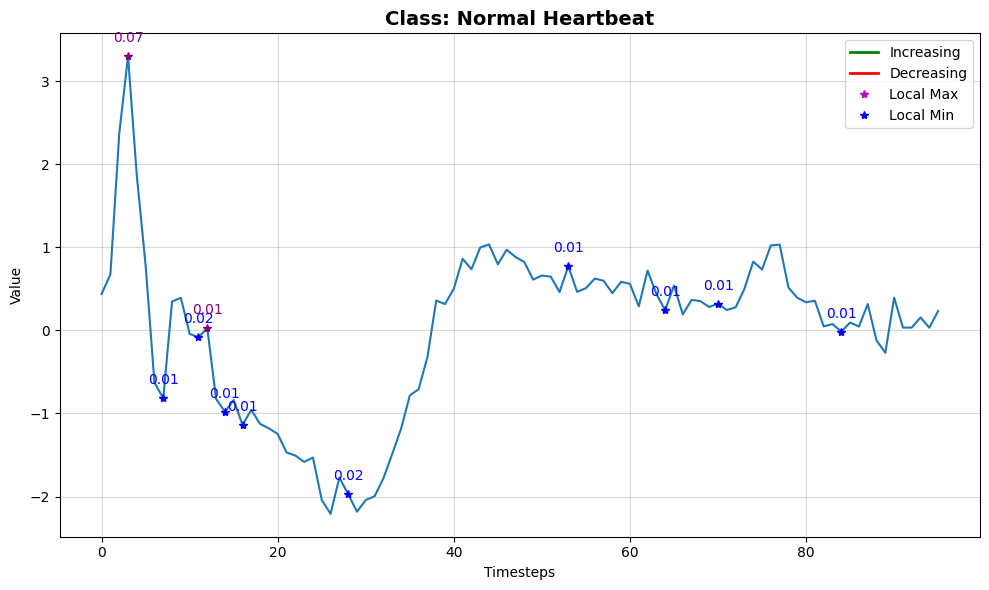

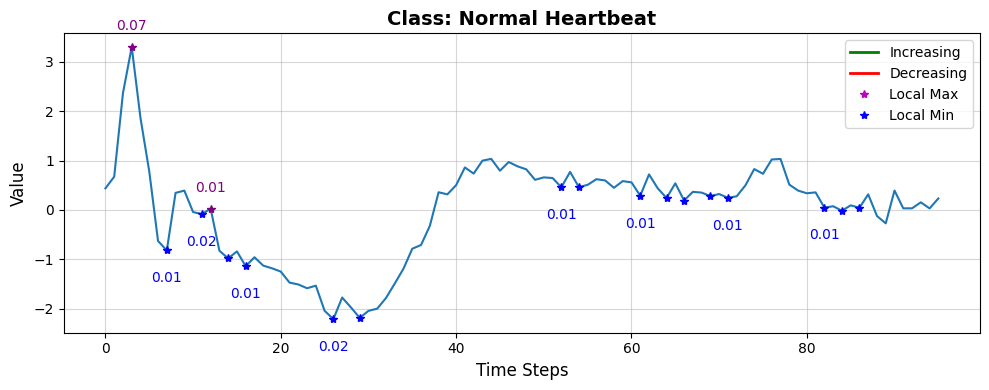

Prediction probability : tensor([1.2820e-13, 1.0000e+00])
Myocardial Infarction:                      0.0000
Normal Heartbeat:                      1.0000


In [15]:
origi_instance_0 = X_test[5] # Instance that is classified as Myocardial Infraction
explanation = lomatce_explainer.explain_instance(origi_instance_0, lambda data: predict_fn(data, learn_new), num_perturbations=1000, top_n=15, class_names=class_labels, replacement_method='zero', analysis=True)

In [16]:
explanation.analysis_metrics

{'Increasing_ch1': {'optimal_k': 16,
  'silhouette_score': 0.9522204903399304,
  'clustering_time': 5.719389200210571,
  'n_samples': 9203,
  'n_jobs': 5},
 'Decreasing_ch1': {'optimal_k': 18,
  'silhouette_score': 0.9041650206287141,
  'clustering_time': 2.5435597896575928,
  'n_samples': 12336,
  'n_jobs': 5},
 'LocalMax_ch1': {'optimal_k': 19,
  'silhouette_score': 0.8456557794680778,
  'clustering_time': 5.307242155075073,
  'n_samples': 23941,
  'n_jobs': 5},
 'LocalMin_ch1': {'optimal_k': 19,
  'silhouette_score': 0.8693748243249307,
  'clustering_time': 4.086431264877319,
  'n_samples': 23658,
  'n_jobs': 5}}

INFO:lomatce.explainer:Starting time series local explanation
INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 8/20 CPU cores
Testing up to 20 clusters (adaptive based on 9913 samples)
Optimal number of clusters for Increasing_ch1: 18
Running on 8/20 CPU cores
Testing up to 20 clusters (adaptive based on 11681 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 8/20 CPU cores
Testing up to 20 clusters (adaptive based on 14377 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 8/20 CPU cores
Testing up to 20 clusters (adaptive based on 13352 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 75) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 75


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.57
INFO:lomatce.explainer:Local Prediction (Linear Model): 0.99
INFO:lomatce.explainer:Model Type: Ridge


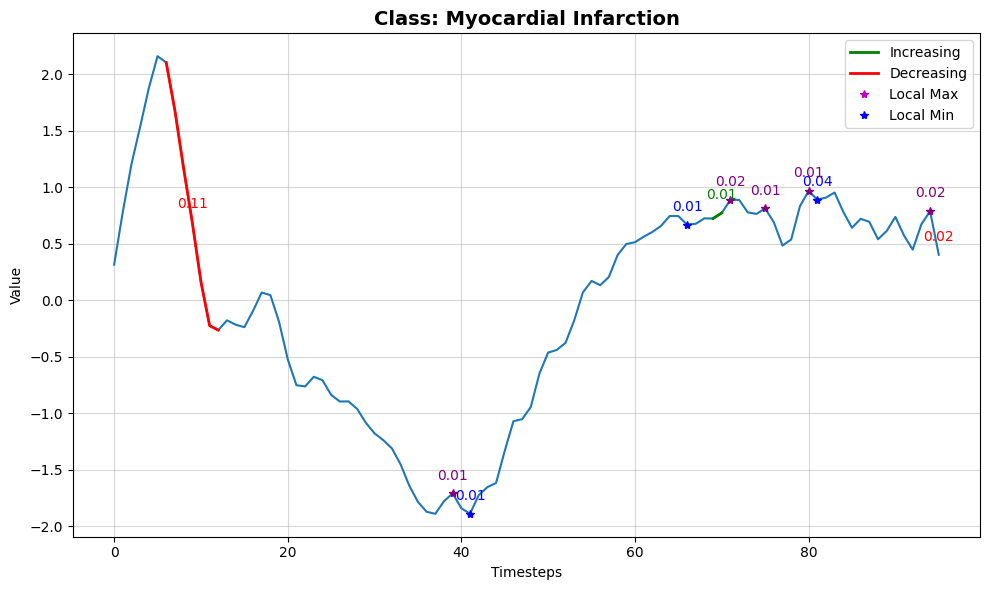

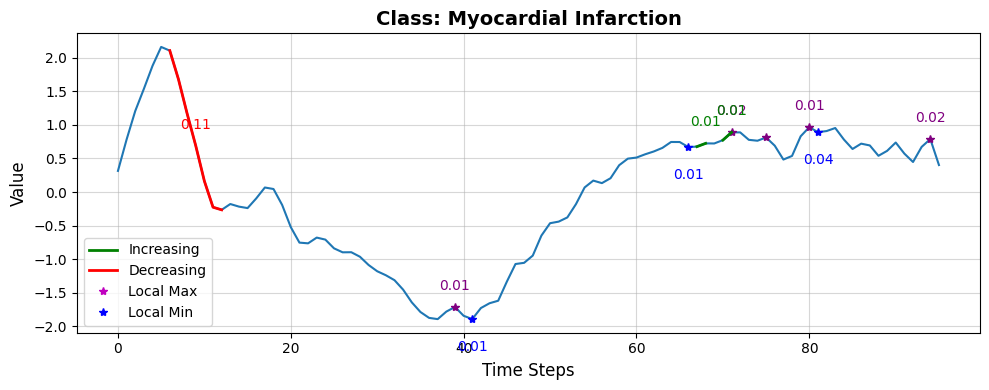

Prediction probability : tensor([0.9984, 0.0016])
Myocardial Infarction:                      0.9984
Normal Heartbeat:                      0.0016


In [17]:
origi_instance_0 = X_test[7] # Instance that is classified as Myocardial Infraction
explanation = lomatce_explainer.explain_instance(origi_instance_0, lambda data: predict_fn(data, learn_new), num_perturbations=1000, top_n=15, class_names=class_labels, replacement_method='zero',n_jobs=8)


📊 Visual 1: Cluster centroids overlaid on the original time series.


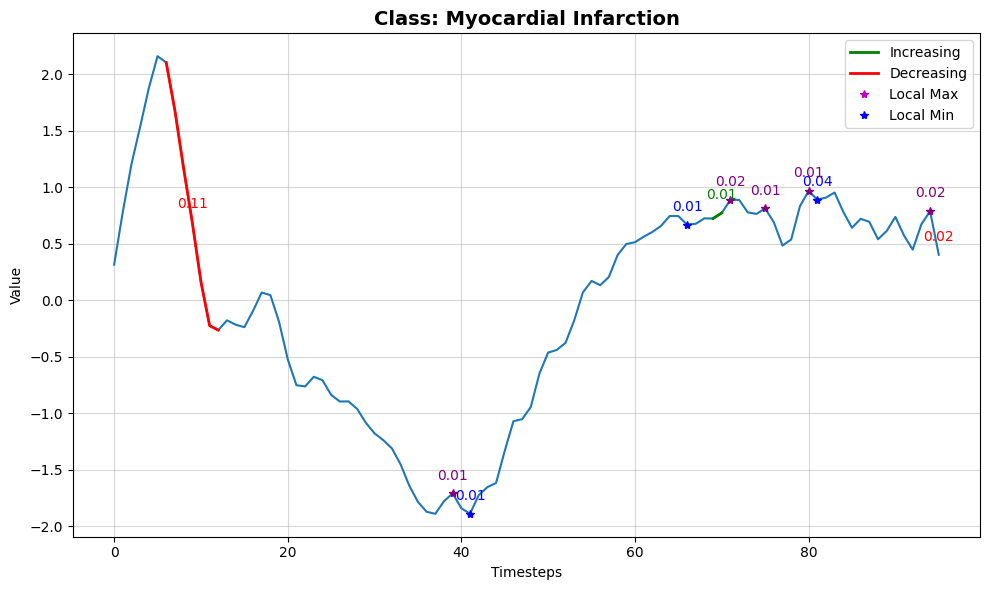

📌 Visual 2: Important events belong to the top-k clusters overlaid on the original time series.


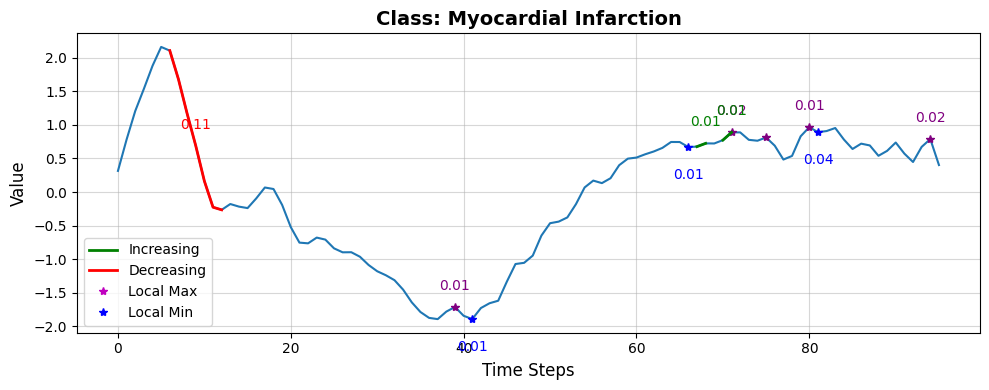

🧠 Explanation Summary:
• Local prediction (interpretable model): 0.9865
• Black-box model prediction: 0 or 'Myocardial Infarction'
• Local fidelity score (R²): 0.5723

 Class Probabilities (from black-box model):
Myocardial Infarction:                      0.9984
Normal Heartbeat:                      0.0016


In [18]:
explanation.visualise(origi_instance_0)

INFO:lomatce.explainer:Starting time series local explanation
INFO:lomatce.explainer:Perturbed instances shape for classifier: (1501, 1, 96)
INFO:lomatce.explainer:Processing events for 1501 instances


Running on 5/20 CPU cores
Testing up to 25 clusters (adaptive based on 13903 samples)
Optimal number of clusters for Increasing_ch1: 23
Running on 5/20 CPU cores
Testing up to 25 clusters (adaptive based on 17171 samples)
Optimal number of clusters for Decreasing_ch1: 24
Running on 5/20 CPU cores
Testing up to 25 clusters (adaptive based on 35920 samples)
Optimal number of clusters for LocalMax_ch1: 24
Running on 5/20 CPU cores
Testing up to 25 clusters (adaptive based on 35599 samples)
Optimal number of clusters for LocalMin_ch1: 23


INFO:lomatce.explainer:Final data shape: (1501, 94) (instances x features)
INFO:lomatce.explainer:Number of instances: 1501
INFO:lomatce.explainer:Number of features (clusters): 94


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.26
INFO:lomatce.explainer:Local Prediction (Linear Model): 1.0
INFO:lomatce.explainer:Model Type: Ridge


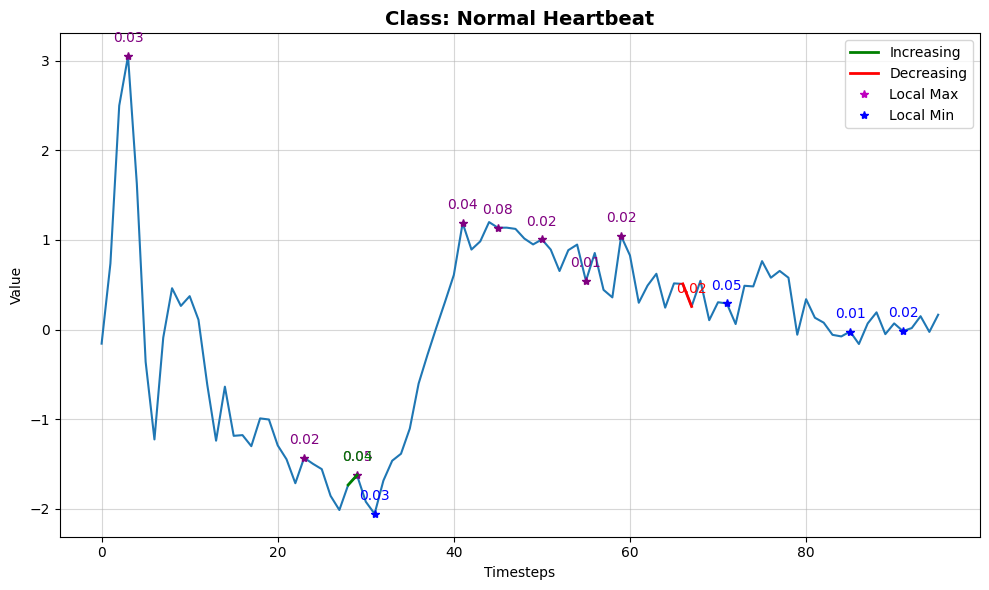

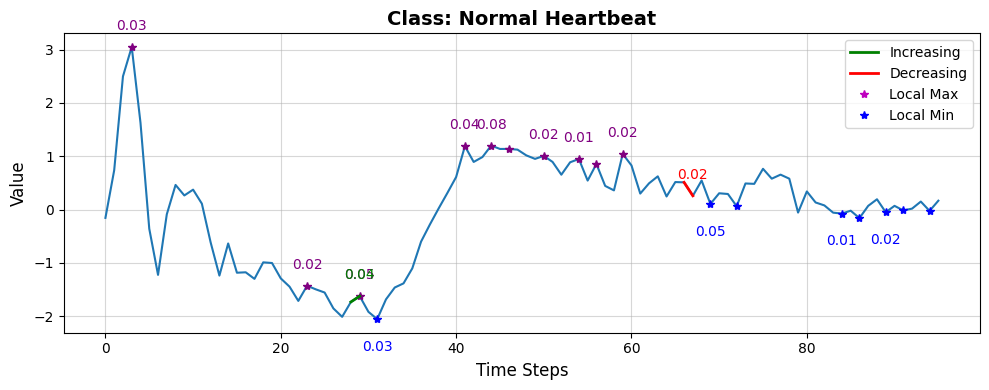

Prediction probability : tensor([1.9722e-12, 1.0000e+00])
Myocardial Infarction:                      0.0000
Normal Heartbeat:                      1.0000


In [19]:
origi_instance_1 = X_test[1] # Instance that is classified as Normal heartbeat
explanation = lomatce_explainer.explain_instance(origi_instance_1, lambda data: predict_fn(data, learn_new), num_perturbations=1500, top_n=15, class_names=class_labels, replacement_method='zero', n_clusters=25)

INFO:lomatce.explainer:Starting time series local explanation


Replacement methods: zero


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 13365 samples)
Optimal number of clusters for Increasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 9789 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 25385 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 25261 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 76) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 76


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.8
INFO:lomatce.explainer:Local Prediction (Linear Model): 1.0
INFO:lomatce.explainer:Model Type: Ridge


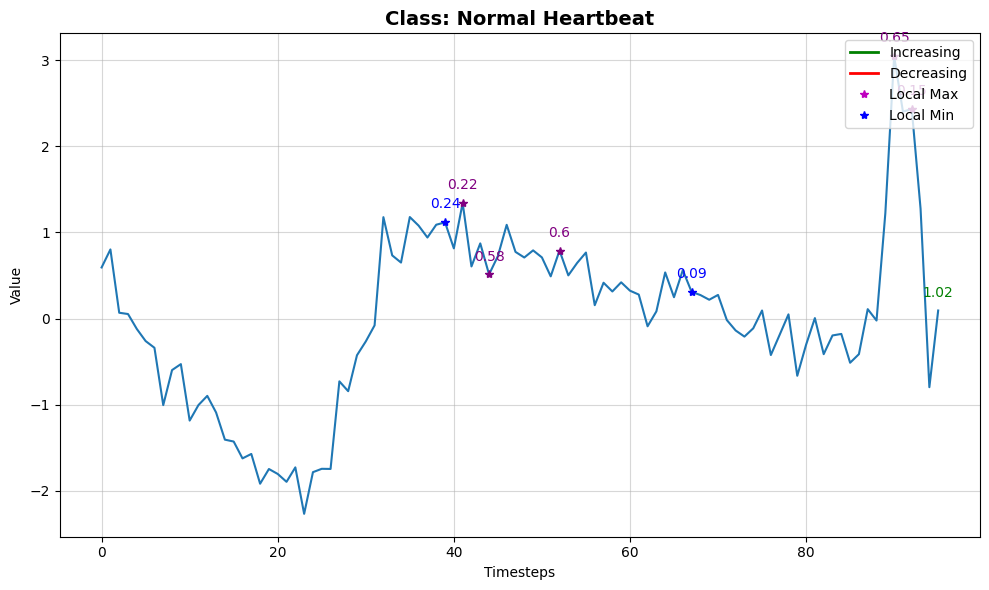

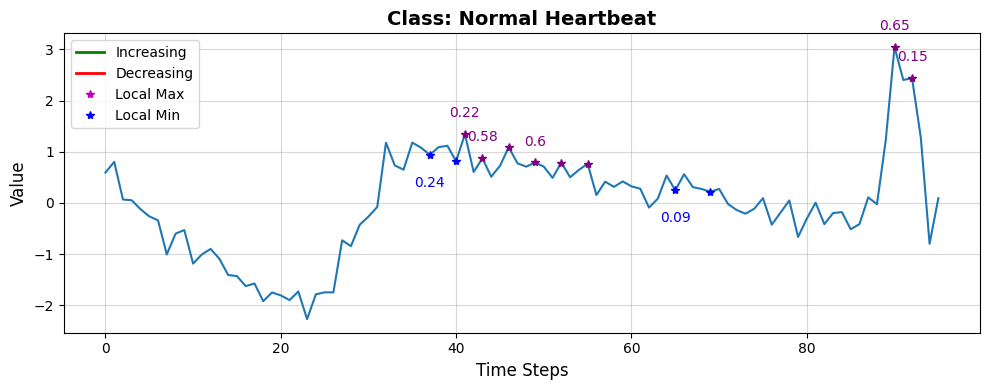

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([1.9931e-06, 1.0000e+00])
Myocardial Infarction:                      0.0000
Normal Heartbeat:                      1.0000


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 8877 samples)
Optimal number of clusters for Increasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 11496 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 23847 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 23469 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 76) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 76


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.83
INFO:lomatce.explainer:Local Prediction (Linear Model): 0.91
INFO:lomatce.explainer:Model Type: Ridge


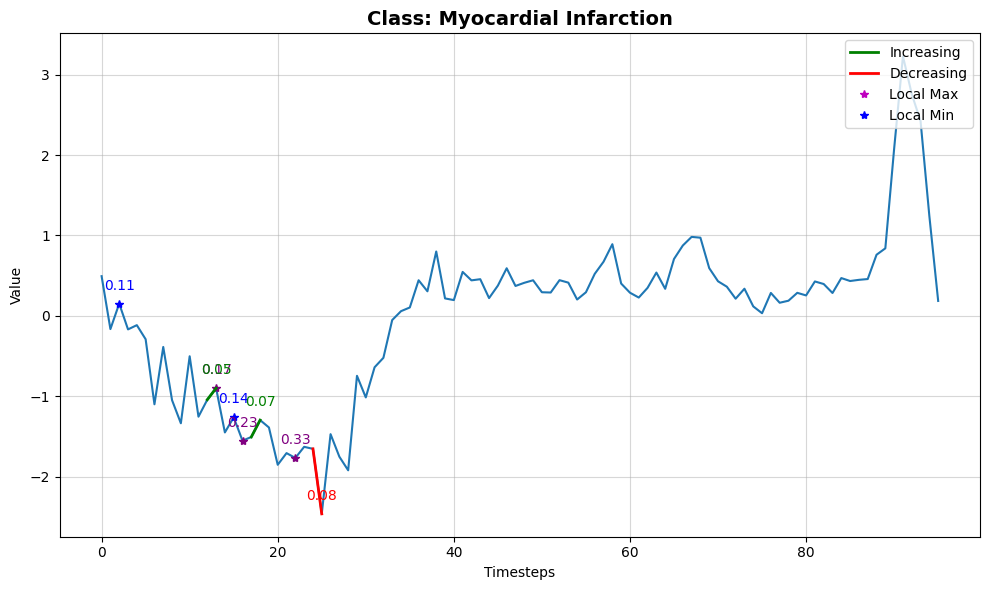

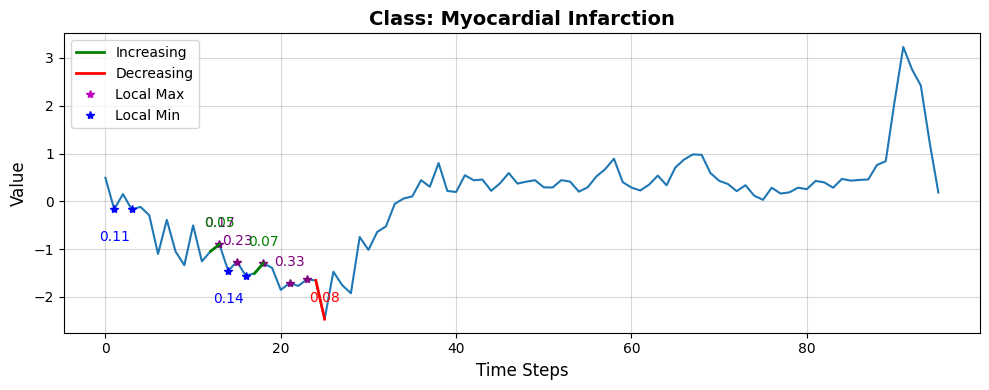

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([0.9368, 0.0632])
Myocardial Infarction:                      0.9368
Normal Heartbeat:                      0.0632


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 9180 samples)
Optimal number of clusters for Increasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 12332 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 23984 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 23709 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 76) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 76


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.24
INFO:lomatce.explainer:Local Prediction (Linear Model): 1.01
INFO:lomatce.explainer:Model Type: Ridge


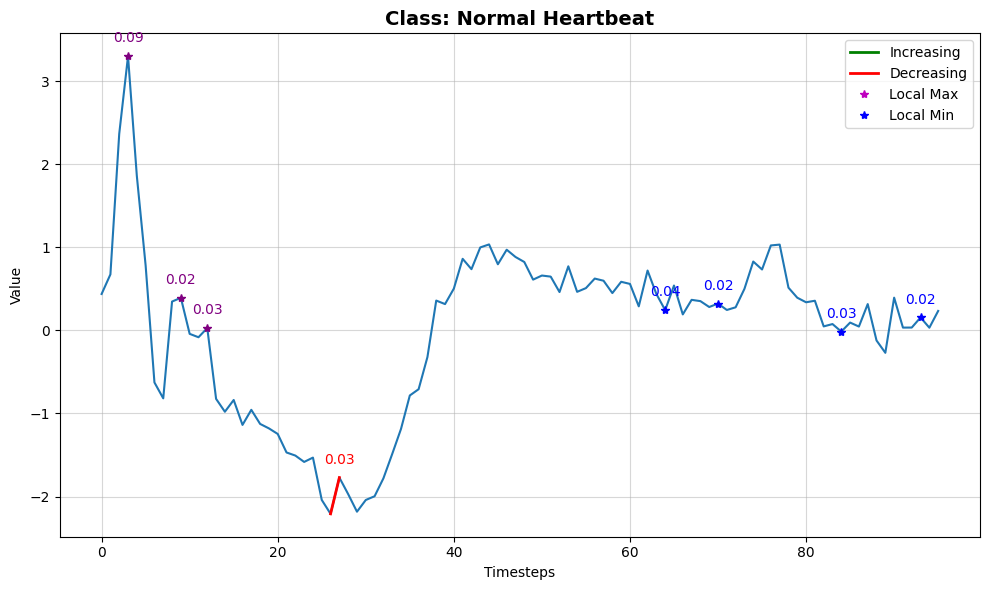

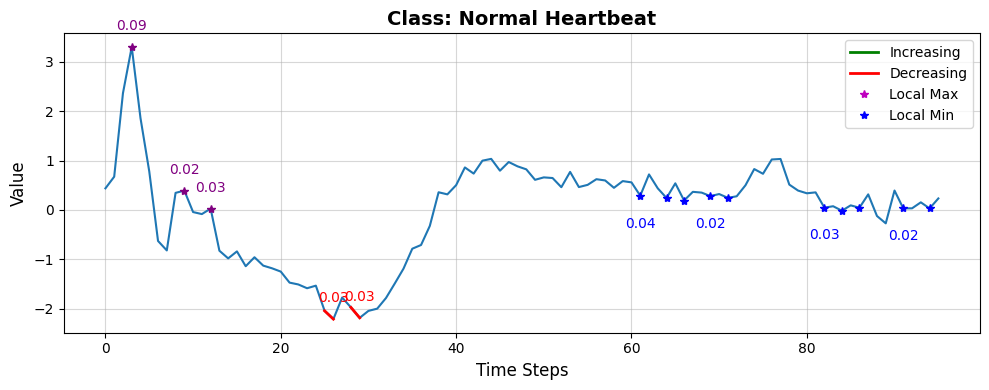

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([1.2820e-13, 1.0000e+00])
Myocardial Infarction:                      0.0000
Normal Heartbeat:                      1.0000
Replacement methods: total_mean


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 6643 samples)
Optimal number of clusters for Increasing_ch1: 13
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 8941 samples)
Optimal number of clusters for Decreasing_ch1: 18
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 16955 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 16690 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 69) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 69


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.48
INFO:lomatce.explainer:Local Prediction (Linear Model): 1.01
INFO:lomatce.explainer:Model Type: Ridge


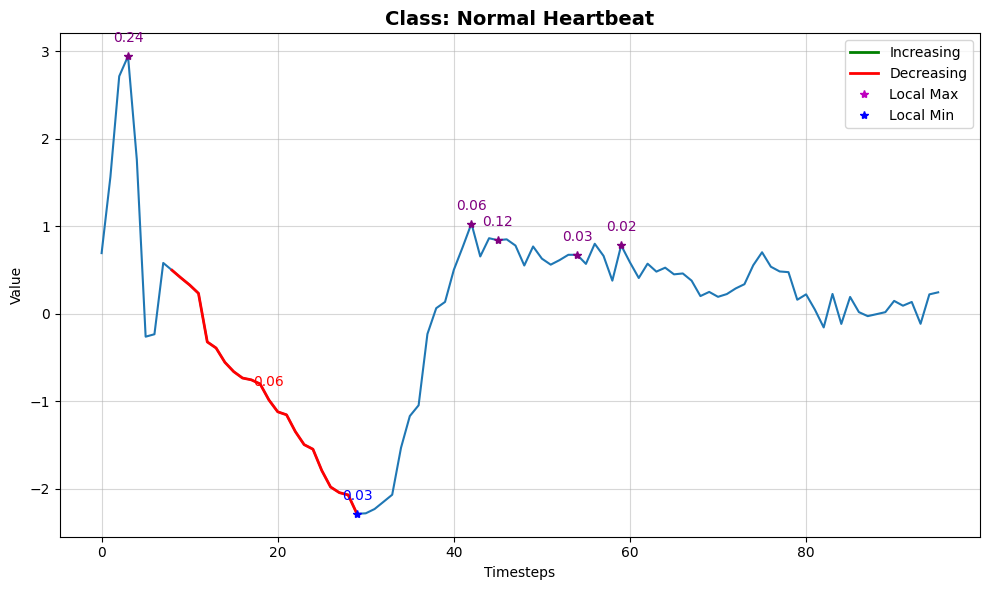

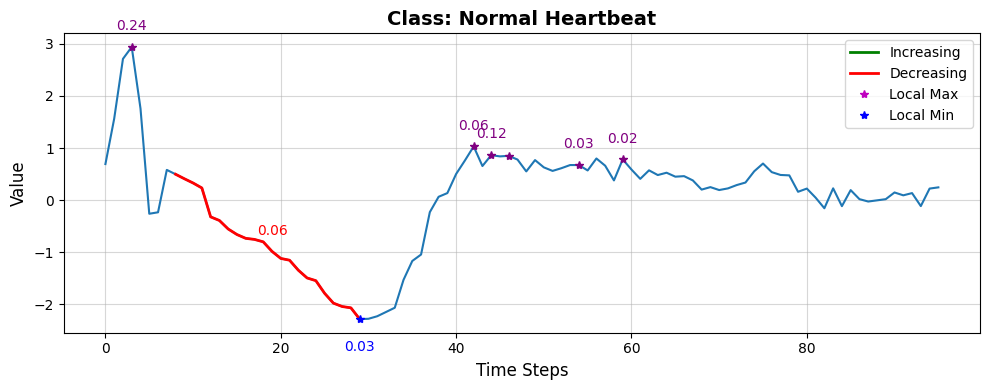

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([4.1801e-10, 1.0000e+00])
Myocardial Infarction:                      0.0000
Normal Heartbeat:                      1.0000


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 9208 samples)
Optimal number of clusters for Increasing_ch1: 16
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 12326 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 24071 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 23741 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 73) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 73


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.87
INFO:lomatce.explainer:Local Prediction (Linear Model): 1.02
INFO:lomatce.explainer:Model Type: Ridge


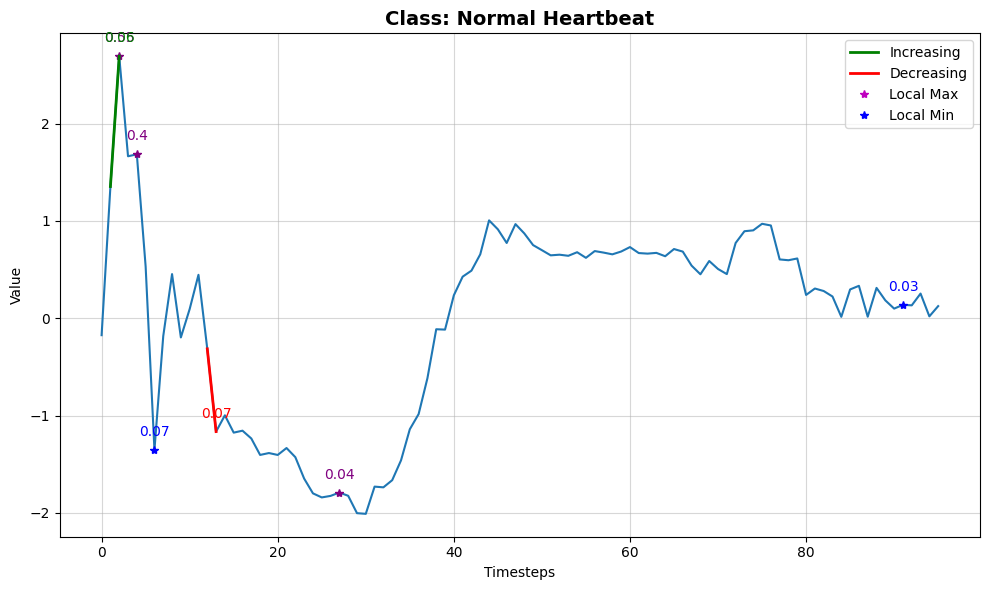

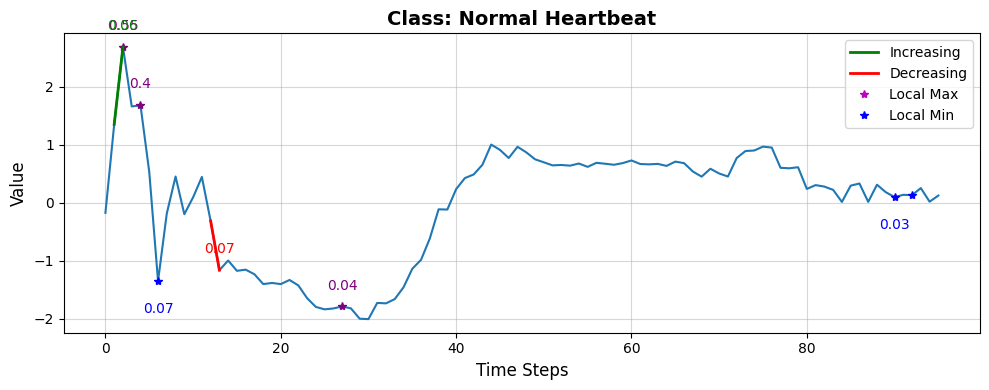

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([1.7563e-10, 1.0000e+00])
Myocardial Infarction:                      0.0000
Normal Heartbeat:                      1.0000


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 13392 samples)
Optimal number of clusters for Increasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 8941 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 26287 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 26050 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 76) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 76


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.12
INFO:lomatce.explainer:Local Prediction (Linear Model): 1.0
INFO:lomatce.explainer:Model Type: Ridge


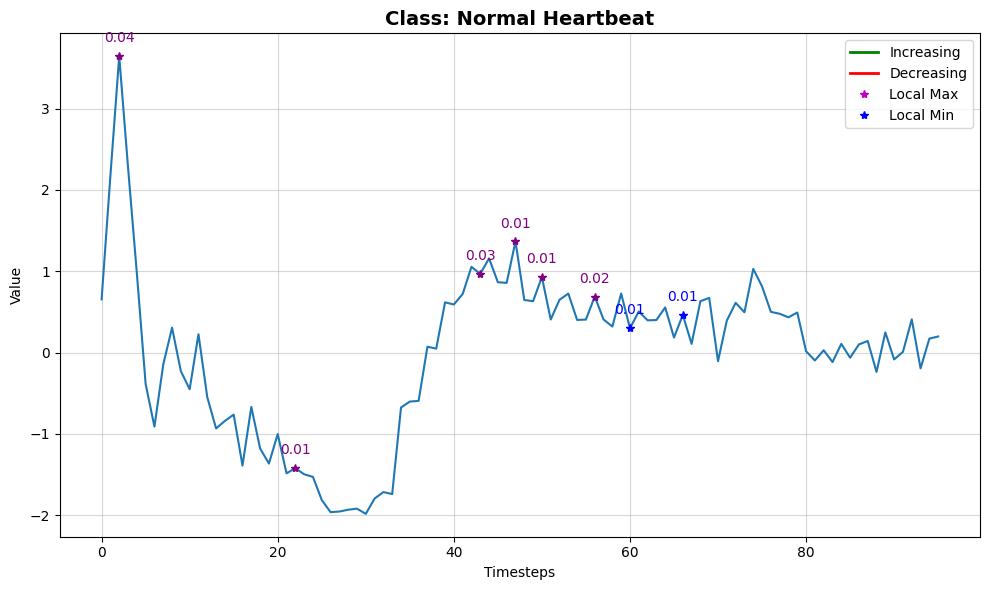

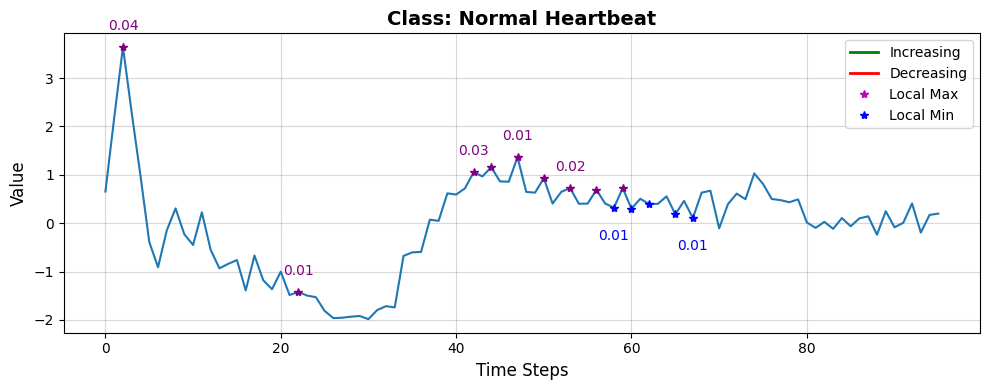

Prediction probability : tensor([6.1838e-15, 1.0000e+00])
Myocardial Infarction:                      0.0000
Normal Heartbeat:                      1.0000


In [20]:
# Define the replacement methods
replacement_methods = ['zero', 'total_mean']

# Initialize a dictionary to store the results
results = {}

# Iterate over the replacement methods
for method in replacement_methods:
    # Initialize a list to store prediction scores for the current method
    print(f'Replacement methods: {method}')
    prediction_scores = []
    
    # Run the function 100 times for the current method
    for _ in range(3):
        # Randomly select an instance
        origi_instance_1 = X_test[np.random.randint(len(X_test))]

        # Call the ts_local_explanation function with the current replacement method
        explanation = lomatce_explainer.explain_instance(origi_instance_1, lambda data : predict_fn(data, learn_new), num_perturbations=1000, class_names=class_labels, replacement_method=method)
        
        # Append the prediction score to the list
        # prediction_scores.append(prediction_score)
    
    # Compute the mean and standard deviation of the prediction scores for the current method
#     mean_prediction_score = np.mean(prediction_scores)
#     std_prediction_score = np.std(prediction_scores)
    
#     # Store the results in the dictionary
#     results[method] = (mean_prediction_score, std_prediction_score)

# # Print the results in tabular format
# print("Replacement Method\tAverage Prediction Score\tStandard Deviation")
# for method, (mean_score, std_score) in results.items():
#     print(f"{method}\t\t\t{mean_score:.2f}  \u00B1 {std_score:.2f}")


### Integrated Gradient

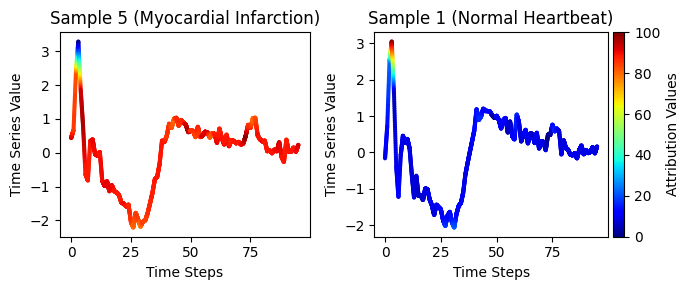

In [21]:
import torch
import numpy as np
from torch import tensor
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from captum.attr import IntegratedGradients
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Define a function to compute Integrated Gradients
def compute_integrated_gradients(x, target):
    integrated_gradients = IntegratedGradients(learn_new.model.cpu())
    attr, delta = integrated_gradients.attribute(x, target=target, return_convergence_delta=True)
    return attr.squeeze().cpu().numpy()

# Function to plot Integrated Gradients
def plot_integrated_gradients(x_sample, target, ax):
    # Compute Integrated Gradients for the sample
    attributions = compute_integrated_gradients(x_sample, target)

    max_length = 3000  # Adjust as needed

    time_steps = torch.arange(len(x_sample.reshape(-1,1)))  # Generate time step indices
    minimum = np.min(attributions)

    attributions = attributions - minimum
    attributions = attributions / max(attributions)
    attributions = attributions * 100

    x = np.linspace(0, x_sample.shape[2] - 1, max_length, endpoint=True)

    # Interpolate the time series values
    f_ts = interp1d(range(x_sample.shape[2]), x_sample[0, 0, :])
    y_ts = f_ts(x)

    # Interpolate the attribution values
    f_cas = interp1d(range(len(attributions)), attributions)
    cas_interpolated = f_cas(x).astype(int)

    # Plot the interpolated attribution values against the interpolated time series
    scatter = ax.scatter(x=x, y=y_ts, c=cas_interpolated, cmap='jet', marker='.', vmin=0, vmax=100, linewidths=0.0)
    return scatter

# Select two samples from the test set for visualization
sample_indices = [5, 1 ]
targets = [0, 1]  # Specify the target for each sample
x_samples = [tensor(X_test[sample_idx][None]) for sample_idx in sample_indices]

# Create subplots side by side
fig, axs = plt.subplots(1, 2, figsize=(7, 3))
labels = class_labels

# Plot Integrated Gradients for each sample
for i, (x_sample, target, ax) in enumerate(zip(x_samples, targets, axs)):
    scatter = plot_integrated_gradients(x_sample, target, ax)
    ax.set_title(f'Sample {sample_indices[i]} ({labels[target]})')
    ax.set_xlabel('Time Steps')
    ax.set_ylabel('Time Series Value')

# Create a new axis on the right side of the last subplot for the color bar
divider = make_axes_locatable(axs[-1])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(scatter, cax=cax)
cbar.set_label('Attribution Values')

plt.tight_layout()
plt.show()


Myocardial Infarction found: 8
Normal Heartbeat found: 22


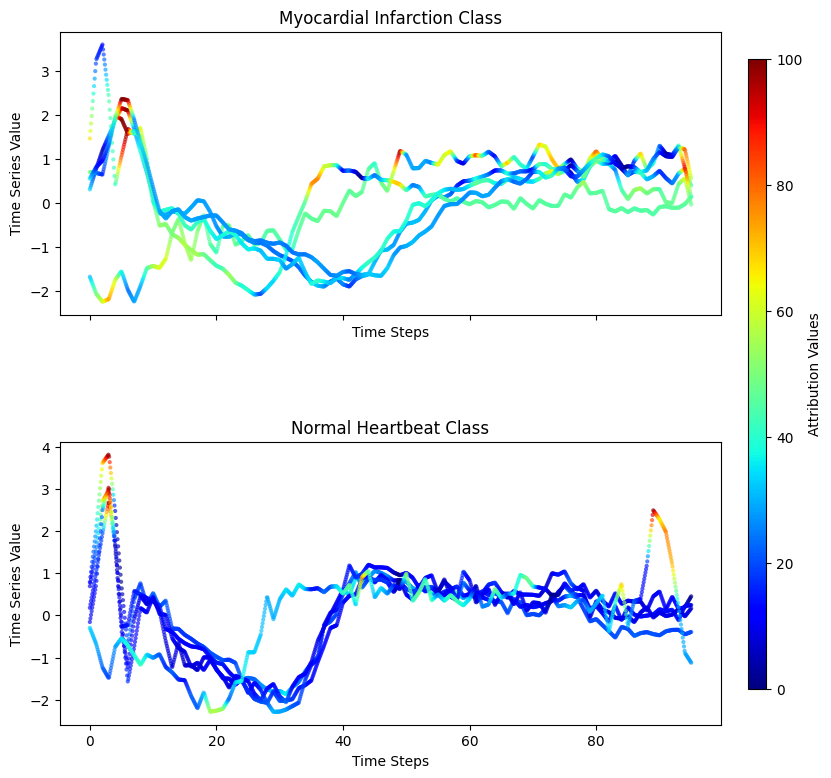

In [22]:
import torch
import numpy as np
from torch import tensor
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from captum.attr import IntegratedGradients
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# ---------------------------------------------------
# Integrated Gradients
# ---------------------------------------------------

def compute_integrated_gradients(x, target):
    model = learn_new.model.cpu()
    model.eval()

    ig = IntegratedGradients(model)

    attr, delta = ig.attribute(
        x.float(),
        target=target,
        return_convergence_delta=True
    )

    return attr.squeeze().detach().cpu().numpy()


# ---------------------------------------------------
# Plot overlaid IG explanations for one predicted class
# ---------------------------------------------------

def plot_class_explanations(ax, class_idx, n_samples=3, max_length=1000):
    pred_indices = np.where(np.array(test_preds) == class_idx)[0]

    print(f"{class_labels[class_idx]} found:", len(pred_indices))

    chosen = np.random.choice(
        pred_indices,
        size=min(n_samples, len(pred_indices)),
        replace=False
    )

    for idx in chosen:
        x_sample = tensor(
            X_test[idx][None],
            dtype=torch.float32
        )

        attributions = compute_integrated_gradients(
            x_sample,
            target=class_idx
        )

        # Normalise attribution to 0–100
        attributions = attributions - np.min(attributions)
        attributions = attributions / (np.max(attributions) + 1e-8)
        attributions = attributions * 100

        x_interp = np.linspace(
            0,
            x_sample.shape[2] - 1,
            max_length,
            endpoint=True
        )

        f_ts = interp1d(
            range(x_sample.shape[2]),
            x_sample[0, 0, :].numpy()
        )
        y_ts = f_ts(x_interp)

        f_attr = interp1d(
            range(len(attributions)),
            attributions
        )
        attr_interp = f_attr(x_interp)

        ax.scatter(
            x_interp,
            y_ts,
            c=attr_interp,
            cmap="jet",
            norm=norm,
            marker=".",
            linewidths=0.0,
            alpha=0.65
        )

    ax.set_title(f"{class_labels[class_idx]} Class")
    ax.set_xlabel("Time Steps")
    ax.set_ylabel("Time Series Value")


# ---------------------------------------------------
# Shared colour scale
# ---------------------------------------------------

norm = Normalize(vmin=0, vmax=100)

# ---------------------------------------------------
# Create figure
# ---------------------------------------------------

fig, axs = plt.subplots(
    len(class_labels),
    1,
    figsize=(9, 9),
    sharex=True
)

if len(class_labels) == 1:
    axs = [axs]

for class_idx, ax in enumerate(axs):
    plot_class_explanations(
        ax,
        class_idx,
        n_samples=5,
        max_length=1000
    )

# Add more vertical space between subplots
fig.subplots_adjust(
    right=0.86,
    hspace=0.45
)

# Shared colourbar on the far right
cbar_ax = fig.add_axes([0.89, 0.15, 0.02, 0.7])

sm = ScalarMappable(norm=norm, cmap="jet")
sm.set_array([])

cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Attribution Values")

plt.show()

### LIME


🔍 Explaining instance 0 — Predicted class: Normal Heartbeat


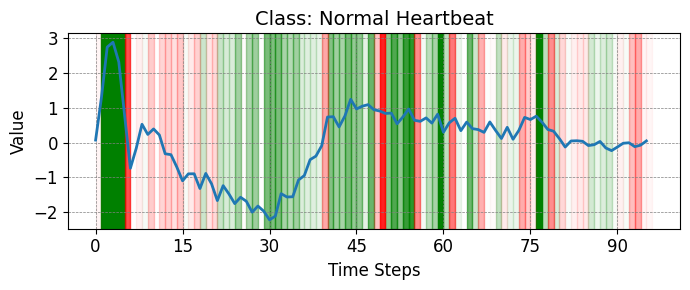


🔍 Explaining instance 1 — Predicted class: Normal Heartbeat


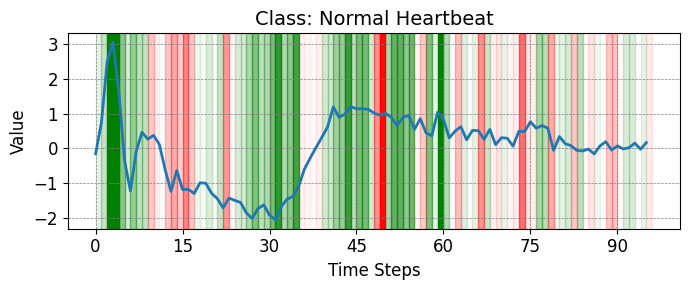


🔍 Explaining instance 2 — Predicted class: Myocardial Infarction


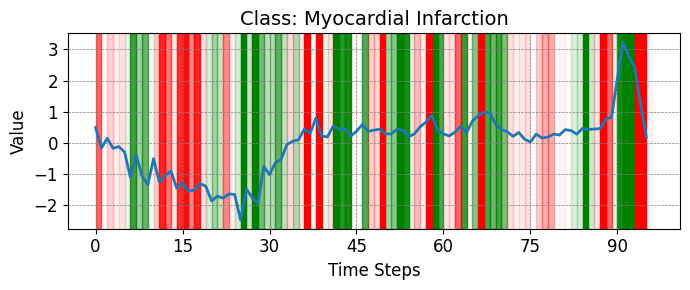


🔍 Explaining instance 3 — Predicted class: Myocardial Infarction


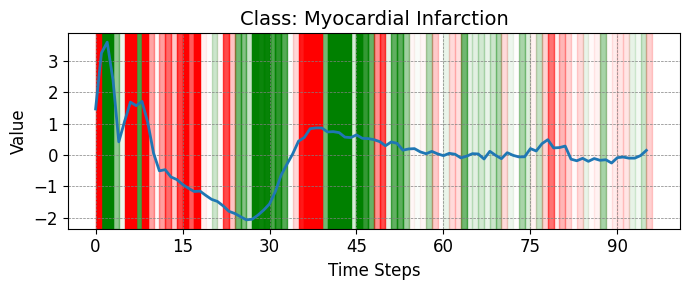


🔍 Explaining instance 4 — Predicted class: Normal Heartbeat


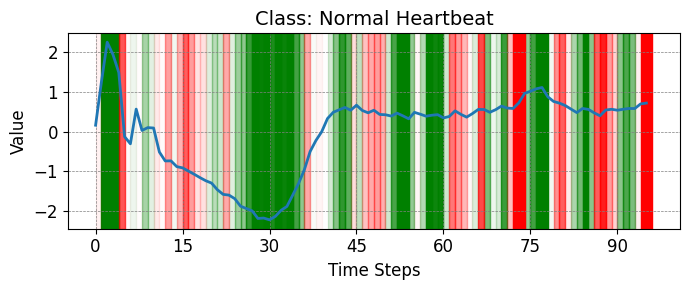

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import math
from lomatce.lime_timeseries import LimeTimeSeriesExplainer
import logging
logging.getLogger().setLevel(logging.WARNING) 

# Predict function that LIME will use
def predict_fn(data):
    if len(data.shape) == 2:
        data = data.reshape(data.shape[0], 1, data.shape[1])  # Handle univariate case
    data_dl = test_loader.test_dataloader(learn_new, data)
    data_probas, _, _ = learn_new.get_preds(dl=data_dl, with_decoded=True, save_preds=None)
    return data_probas.numpy()

# Compute LIME and visualize importance
def compute_lime_importances(flat_series, predict_fn, num_slices=25, num_features=10, num_samples=5000, class_label=None, class_names=None):
    if num_slices is None:
        num_slices = len(flat_series)
    explainer = LimeTimeSeriesExplainer(class_names=class_names)

    exp = explainer.explain_instance(
        flat_series,
        predict_fn,
        num_features=num_features,
        num_samples=num_samples,
        num_slices=num_slices,
        replacement_method='total_mean'
    )

    values_per_slice = math.ceil(len(flat_series) / num_slices)
    segments_weights = exp.as_list()
    sorted_segments = sorted(segments_weights, key=lambda x: x[1], reverse=True)

    # Plot
    plt.figure(figsize=(7, 3))
    plt.plot(flat_series, color='C0', linewidth=2)

    for feature, weight in sorted_segments:
        start = feature * values_per_slice
        end = min(start + values_per_slice, len(flat_series))
        color = 'red' if weight < 0 else 'green'
        alpha = min(abs(weight) * 20, 1.0)
        plt.axvspan(start, end, color=color, alpha=alpha, edgecolor='none')

    plt.title(f'Class: {class_label}', fontsize=14)
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel('Value', fontsize=12)
    plt.grid(True, linestyle='--', linewidth=0.5, color='gray')
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()

    return sorted_segments

# 🔁 Explain multiple instances
num_instances_to_explain = 5  # Change to 6 or more if desired
for idx in range(num_instances_to_explain):
    label_index = int(test_preds[idx])  # Convert '0' or '1' string to int
    class_label = class_labels[label_index]

    instance = X_test[idx]  # Shape: (channels, time)
    flat_series = instance.flatten() if instance.ndim == 2 else instance  # Flatten if 2D

    print(f"\n🔍 Explaining instance {idx} — Predicted class: {class_label}")
    compute_lime_importances(
        flat_series,
        predict_fn,
        num_slices=96,
        num_features=96,
        num_samples=5000,
        class_label=class_label,
        class_names=class_labels
    )


### SHAP


🔍 Explaining instance 0 — Predicted class: Normal Heartbeat


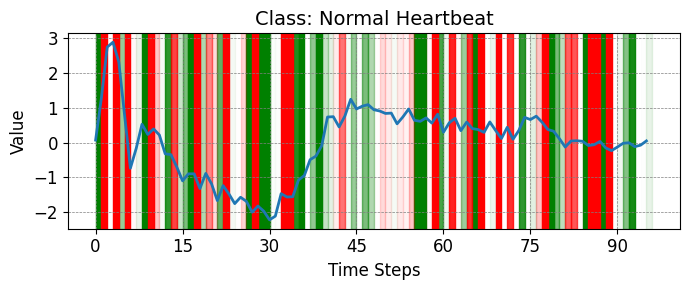


🔍 Explaining instance 1 — Predicted class: Normal Heartbeat


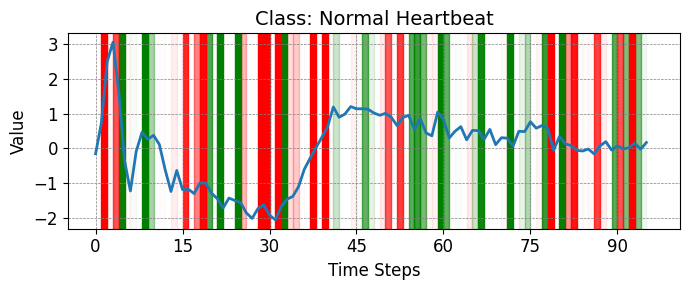


🔍 Explaining instance 2 — Predicted class: Myocardial Infarction


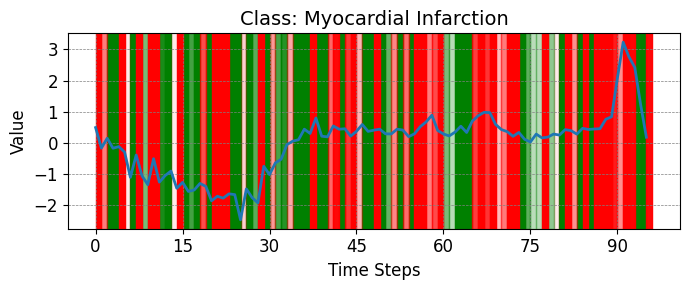


🔍 Explaining instance 3 — Predicted class: Myocardial Infarction


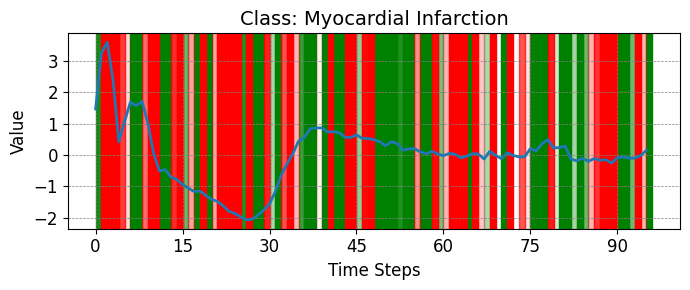


🔍 Explaining instance 4 — Predicted class: Normal Heartbeat


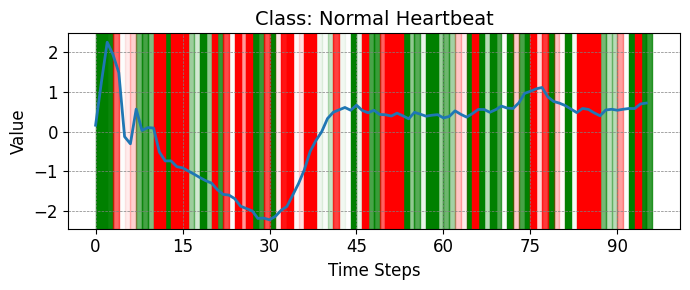

In [28]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import math

# --- 1. Segmenting Function ---
def create_segments(X, num_segments=None):
    num_samples, num_channels, sequence_length = X.shape
    if num_segments is None:
        num_segments = sequence_length
    segment_length = sequence_length // num_segments
    return num_segments, segment_length

# --- 2. Predict Function for SHAP ---
def predict_fn(masks, instance, background_data, num_segments, segment_length, learner):
    masked_inputs = []
    for mask in masks:
        masked_instance = instance.copy()
        for seg_idx in range(num_segments):
            start = seg_idx * segment_length
            end = (seg_idx + 1) * segment_length
            if mask[seg_idx] == 0:
                random_idx = np.random.randint(0, background_data.shape[0])
                background_segment = background_data[random_idx, :, start:end]
                masked_instance[0, :, start:end] = background_segment
        masked_inputs.append(masked_instance[0])
    masked_inputs = np.stack(masked_inputs)  # (num_masks, channels, time)
    data_dl = test_loader.test_dataloader(learner, masked_inputs)
    data_probas, _, _ = learner.get_preds(dl=data_dl, with_decoded=True, save_preds=None)
    return data_probas.numpy()

# --- 3. Plotting SHAP Segment Importance ---
def plot_segment_importance(flat_series, shap_values, segment_length, class_name):
    num_segments = len(shap_values)
    flat_series = flat_series.flatten() if len(flat_series.shape) == 2 else flat_series
    values_per_slice = math.ceil(len(flat_series) / segment_length)
    sorted_segments = sorted(enumerate(shap_values), key=lambda x: x[1], reverse=True)

    plt.figure(figsize=(7, 3))
    plt.plot(flat_series, color='C0', linewidth=2)
    
    for segment_idx, weight in sorted_segments:
        start = segment_idx * values_per_slice
        end = min(start + values_per_slice, len(flat_series))
        color = 'red' if weight < 0 else 'green'
        alpha = min(abs(weight) * 10, 1.0)
        plt.axvspan(start, end, color=color, alpha=alpha, edgecolor='none')

    plt.title(f'Class: {class_name}', fontsize=14)
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel('Value', fontsize=12)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray')
    plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()

# --- 4. SHAP Explanation for Multiple Instances ---
# Set number of segments
num_segments, segment_length = create_segments(X_train, num_segments=None)

# Sample background for masking
background_data = X_train[np.random.choice(len(X_train), min(100, len(X_train)), replace=False)]

# Loop over multiple test instances
num_instances_to_explain = 5

for idx in range(num_instances_to_explain):
    instance_to_explain = X_test[idx:idx+1]  # Shape: (1, C, T)
    label_index = int(test_preds[idx])
    class_name = class_labels[label_index]
    print(f"\n🔍 Explaining instance {idx} — Predicted class: {class_name}")
    # SHAP explainer setup
    predict_fn_shap = lambda masks: predict_fn(
        masks,
        instance=instance_to_explain,
        background_data=background_data,
        num_segments=num_segments,
        segment_length=segment_length,
        learner=learn_new
    )

    explainer = shap.Explainer(predict_fn_shap, np.zeros((1, num_segments)))
    shap_values = explainer.shap_values(np.ones((1, num_segments)))
    
    # Extract SHAP values for the predicted class
    if isinstance(shap_values, list):
        shap_value = shap_values[label_index][0]
    else:
        shap_value = shap_values[0, :, label_index]

    shap_values_flat = np.array(shap_value).flatten()
    sorted_indices = np.argsort(-np.abs(shap_values_flat))
    sorted_shap_values = shap_values_flat[sorted_indices]
    important_time_steps = sorted_indices

    # Plot the explanation
    flat_series = instance_to_explain.reshape(1, instance_to_explain.shape[2])
    plot_segment_importance(flat_series, shap_values_flat, num_segments, class_name)


### SP-LOMATCE

In [23]:
from lomatce.sp_lomatce import SPLOMATCE

In [24]:
def predict_fn(data, learner):
    if len(data.shape) == 2:
        data = data.reshape(data.shape[0], 1, data.shape[1])
    data_dl = test_loader.test_dataloader(learner, data)
    data_probas, _, data_preds = learner.get_preds(dl=data_dl, with_decoded=True, save_preds=None)
    return data_probas, data_preds

In [25]:
# Initialize SP-LOMATCE
splomatce_explainer = SPLOMATCE(class_labels=class_labels, dataset_name="ECG200", lomatce_explainer=lomatce_explainer, predict_fn=lambda data: predict_fn(data, learn_new), output_dir=base_dir)


In [26]:
X_merged = np.concatenate([X_valid, X_test], axis=0)
y_merged = np.concatenate([valid_preds, test_preds], axis=0)
print(f'Shape of X_merged :{X_merged.shape}')
print(f'Shape of y_merged :{y_merged.shape}')
print(f'X_mergedt type: {X_merged.dtype}, y_merged type: {y_merged.dtype}, y_test type: {y_test.dtype}')

Shape of X_merged :(60, 1, 96)
Shape of y_merged :(60,)
X_mergedt type: float32, y_merged type: int64, y_test type: <U2


INFO:lomatce.explainer:Starting time series local explanation



=== Running SP-LOMATCE for class Myocardial Infarction ===


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 11515 samples)
Optimal number of clusters for Increasing_ch1: 17
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 14052 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 15074 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 14124 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 74) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 74


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.64
INFO:lomatce.explainer:Local Prediction (Linear Model): 1.0
INFO:lomatce.explainer:Model Type: Ridge


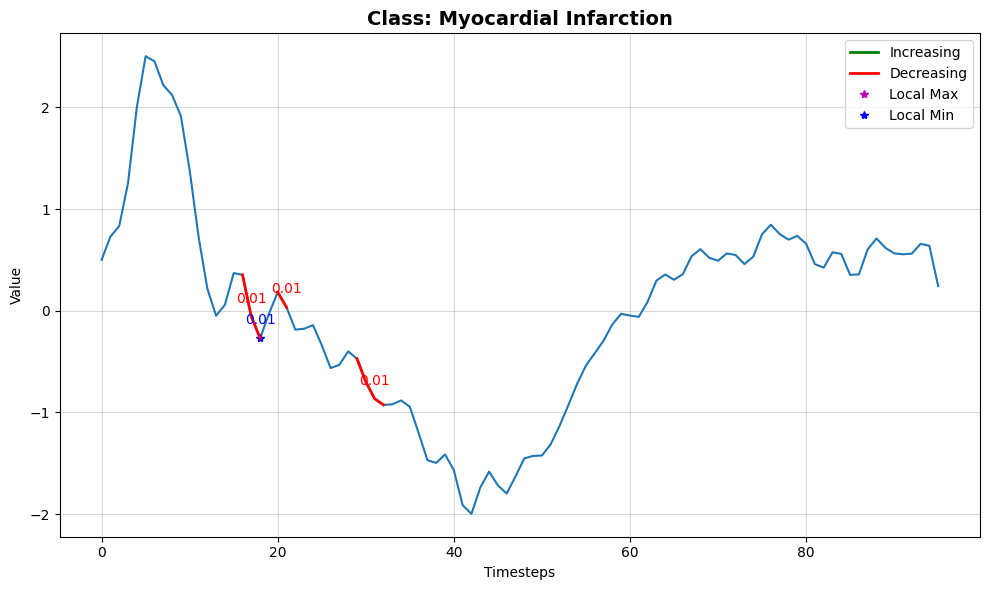

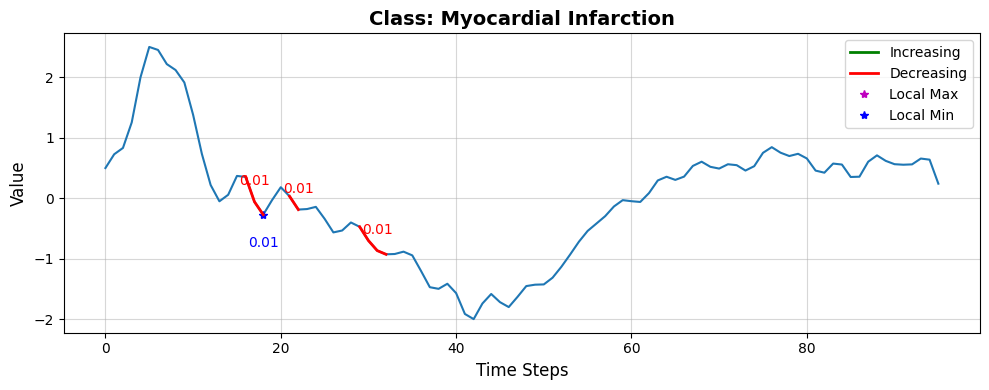

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([9.9952e-01, 4.7796e-04])
Myocardial Infarction:                      0.9995
Normal Heartbeat:                      0.0005


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 9765 samples)
Optimal number of clusters for Increasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 15754 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 21930 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 20752 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 76) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 76


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.79
INFO:lomatce.explainer:Local Prediction (Linear Model): 0.54
INFO:lomatce.explainer:Model Type: Ridge


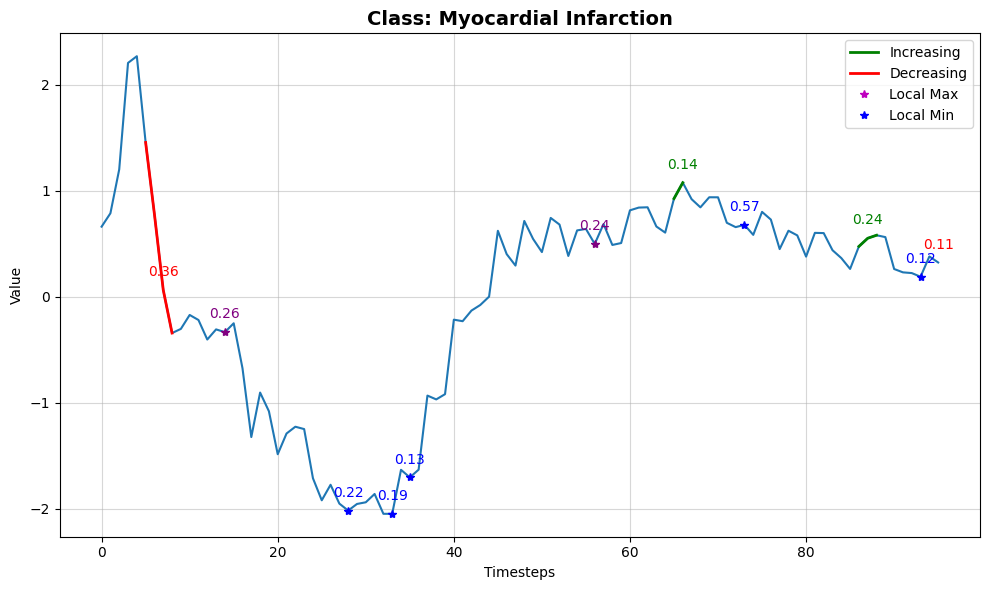

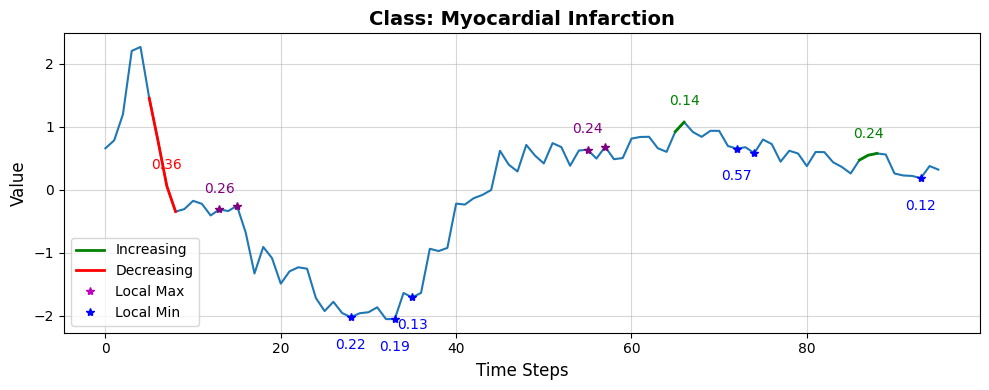

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([0.5208, 0.4792])
Myocardial Infarction:                      0.5208
Normal Heartbeat:                      0.4792


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 7299 samples)
Optimal number of clusters for Increasing_ch1: 15
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 10761 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 11853 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 10763 samples)
Optimal number of clusters for LocalMin_ch1: 18


INFO:lomatce.explainer:Final data shape: (1001, 71) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 71


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.8
INFO:lomatce.explainer:Local Prediction (Linear Model): 1.0
INFO:lomatce.explainer:Model Type: Ridge


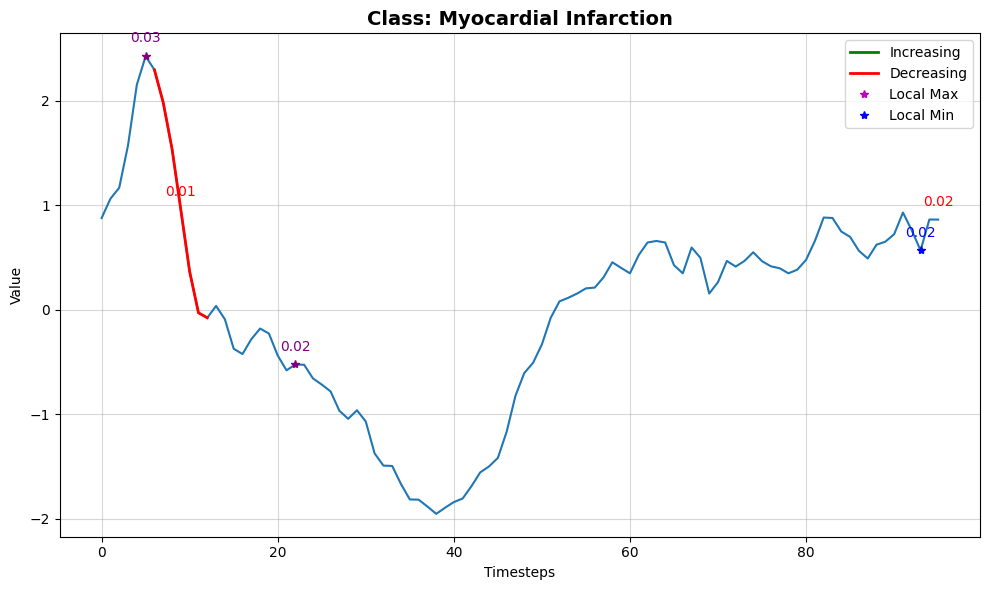

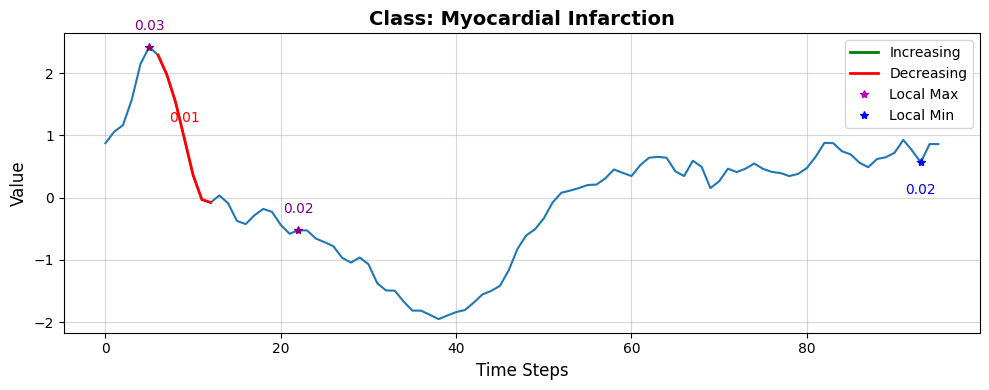

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([9.9987e-01, 1.3447e-04])
Myocardial Infarction:                      0.9999
Normal Heartbeat:                      0.0001


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 9972 samples)
Optimal number of clusters for Increasing_ch1: 16
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 11709 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 14447 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 13409 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 73) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 73


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.7
INFO:lomatce.explainer:Local Prediction (Linear Model): 0.99
INFO:lomatce.explainer:Model Type: Ridge


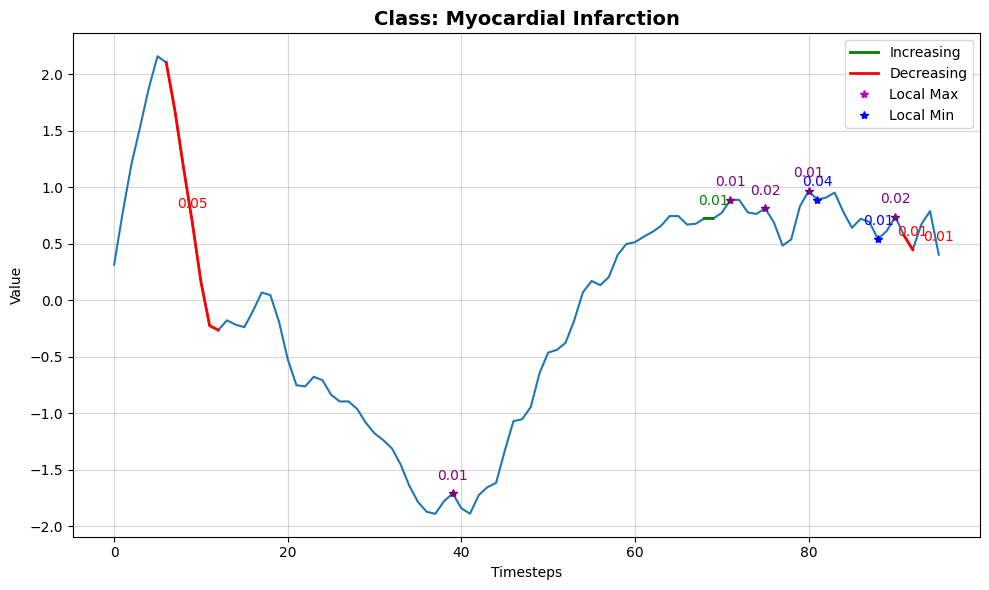

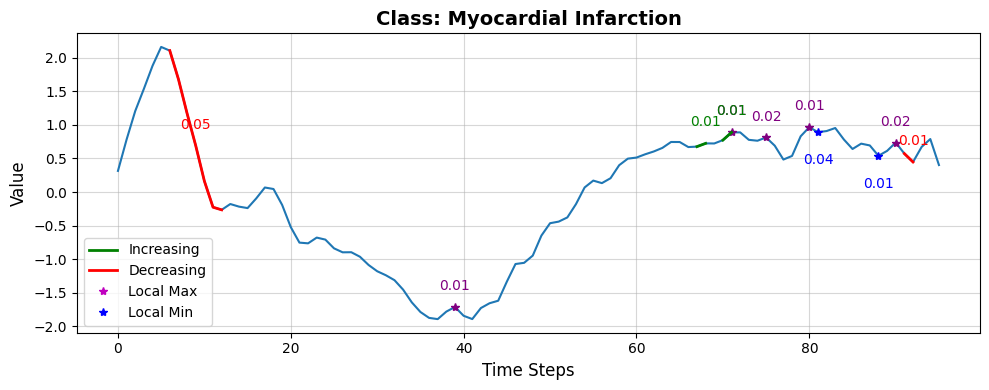

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([0.9984, 0.0016])
Myocardial Infarction:                      0.9984
Normal Heartbeat:                      0.0016


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 9123 samples)
Optimal number of clusters for Increasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 9015 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 11929 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 11761 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 76) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 76


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.85
INFO:lomatce.explainer:Local Prediction (Linear Model): 0.79
INFO:lomatce.explainer:Model Type: Ridge


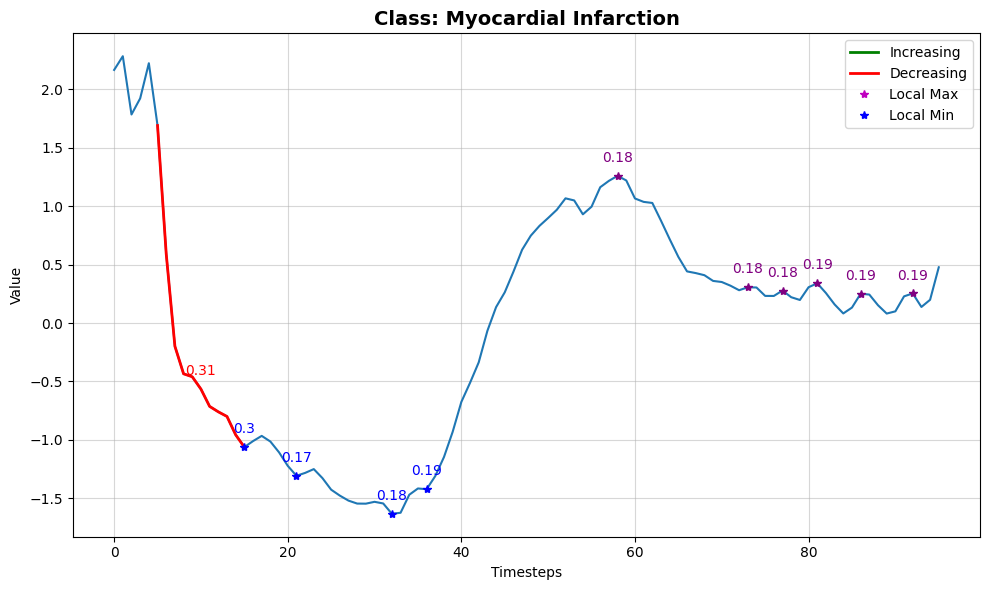

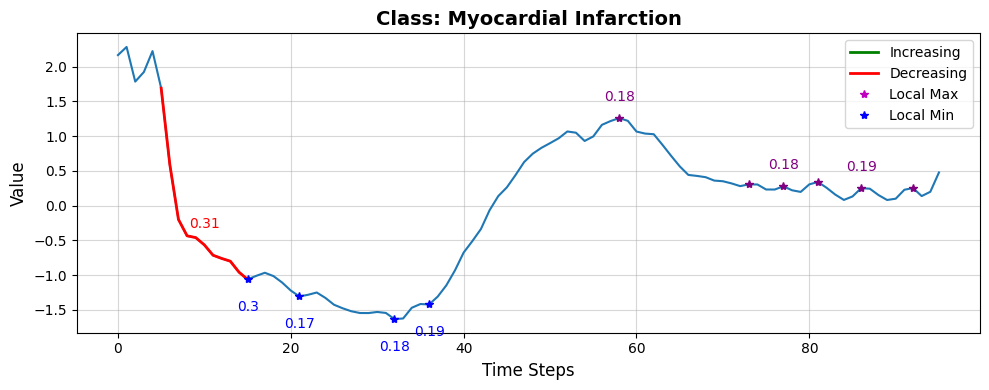

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([0.9764, 0.0236])
Myocardial Infarction:                      0.9764
Normal Heartbeat:                      0.0236


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 13270 samples)
Optimal number of clusters for Increasing_ch1: 17
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 11532 samples)
Optimal number of clusters for Decreasing_ch1: 16
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 16866 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 15921 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 71) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 71


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.8
INFO:lomatce.explainer:Local Prediction (Linear Model): 1.0
INFO:lomatce.explainer:Model Type: Ridge


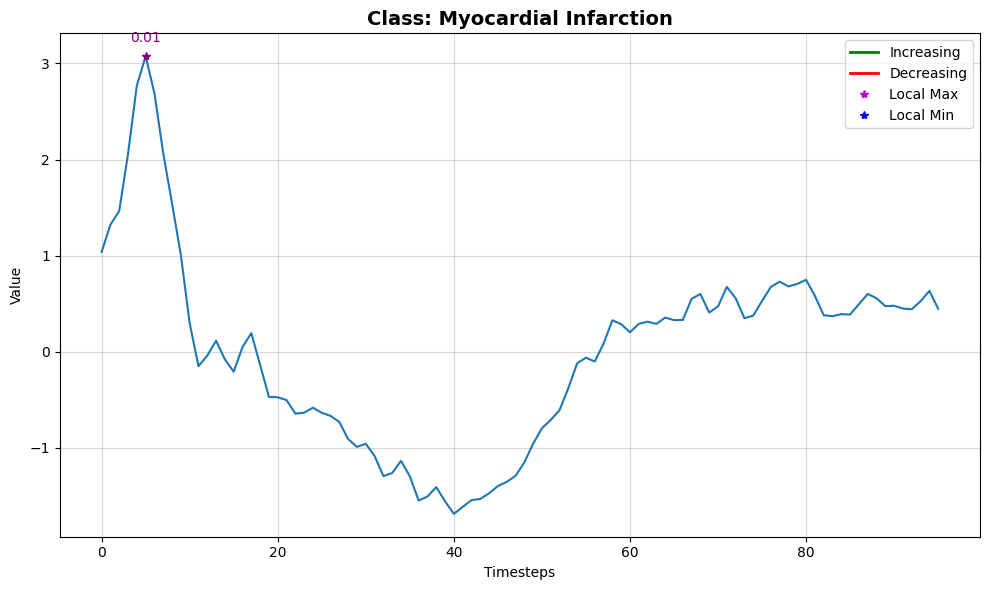

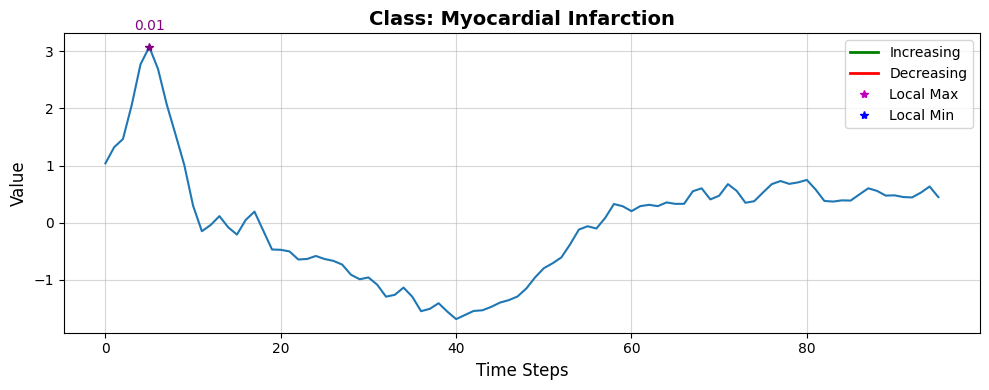

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([1.0000e+00, 6.3925e-08])
Myocardial Infarction:                      1.0000
Normal Heartbeat:                      0.0000


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 8961 samples)
Optimal number of clusters for Increasing_ch1: 16
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 14109 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 14253 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 13407 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 73) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 73


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.58
INFO:lomatce.explainer:Local Prediction (Linear Model): 1.0
INFO:lomatce.explainer:Model Type: Ridge


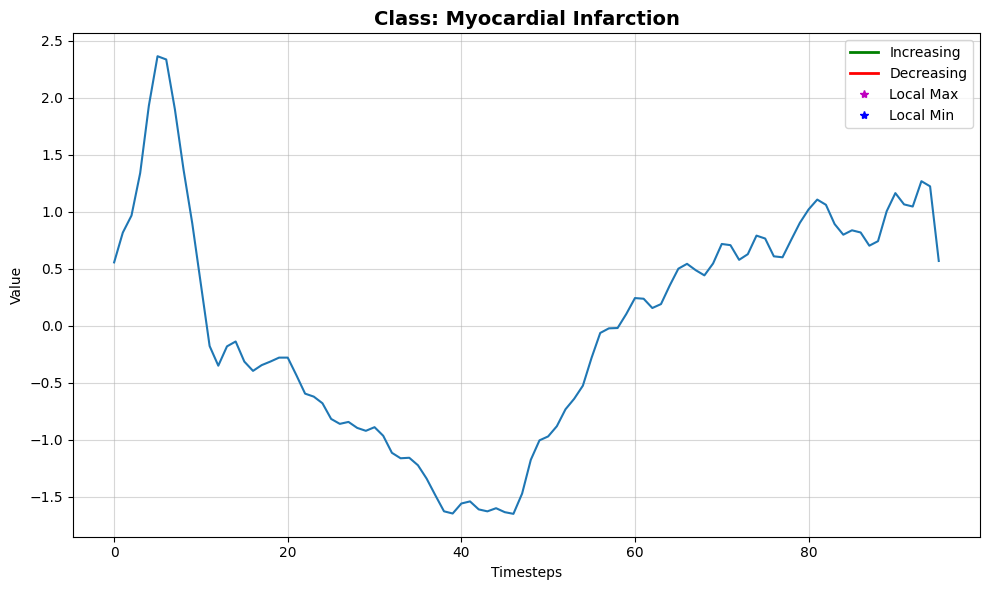

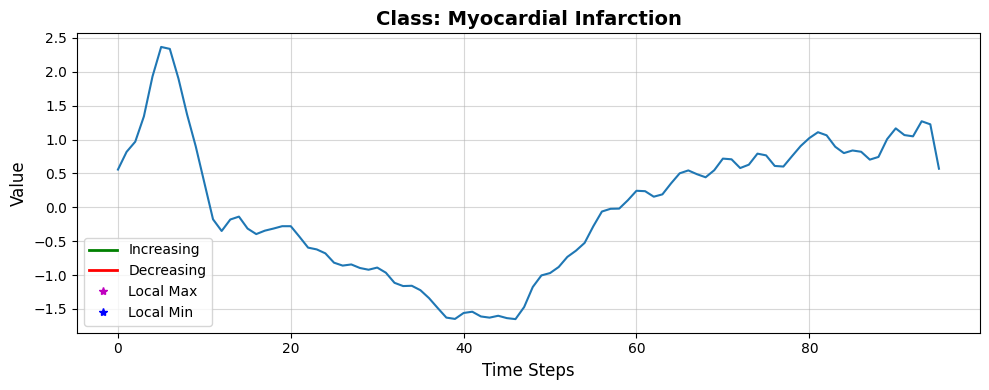

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([9.9999e-01, 9.2901e-06])
Myocardial Infarction:                      1.0000
Normal Heartbeat:                      0.0000


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 12459 samples)
Optimal number of clusters for Increasing_ch1: 18
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 15155 samples)
Optimal number of clusters for Decreasing_ch1: 15
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 17850 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 17824 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 71) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 71


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.65
INFO:lomatce.explainer:Local Prediction (Linear Model): 1.01
INFO:lomatce.explainer:Model Type: Ridge


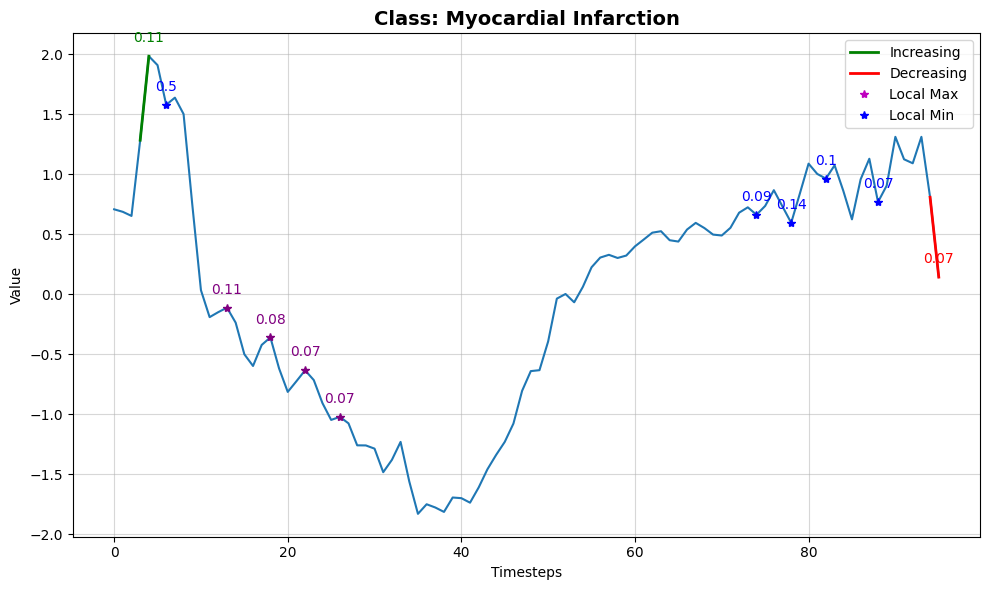

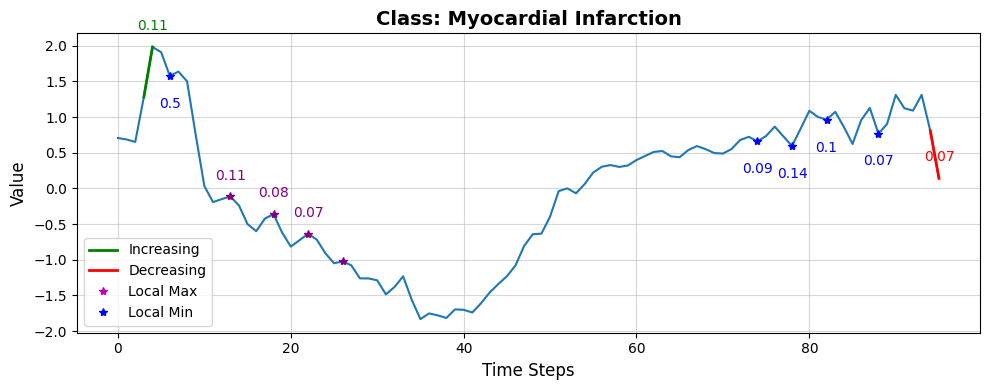

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([0.9836, 0.0164])
Myocardial Infarction:                      0.9836
Normal Heartbeat:                      0.0164


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 11512 samples)
Optimal number of clusters for Increasing_ch1: 18
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 12437 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 17641 samples)
Optimal number of clusters for LocalMax_ch1: 18
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 16692 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 74) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 74


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.8
INFO:lomatce.explainer:Local Prediction (Linear Model): 0.96
INFO:lomatce.explainer:Model Type: Ridge


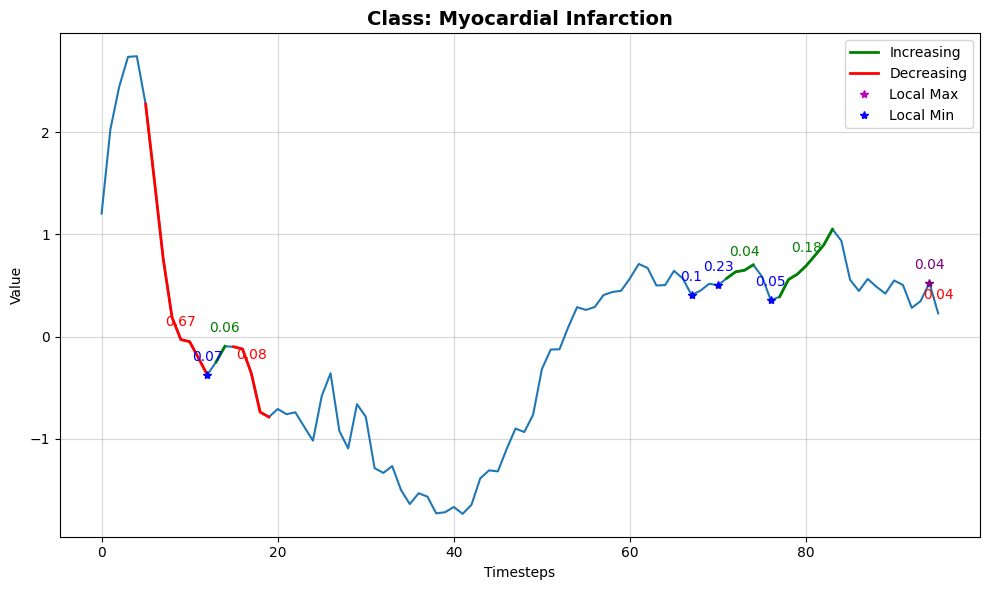

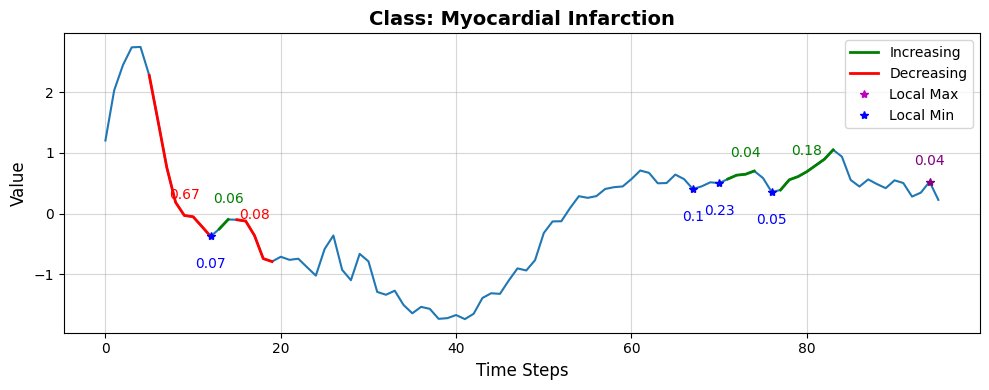

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([0.9613, 0.0387])
Myocardial Infarction:                      0.9613
Normal Heartbeat:                      0.0387


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 15726 samples)
Optimal number of clusters for Increasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 9976 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 23853 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 22576 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 76) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 76


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.76
INFO:lomatce.explainer:Local Prediction (Linear Model): 0.93
INFO:lomatce.explainer:Model Type: Ridge


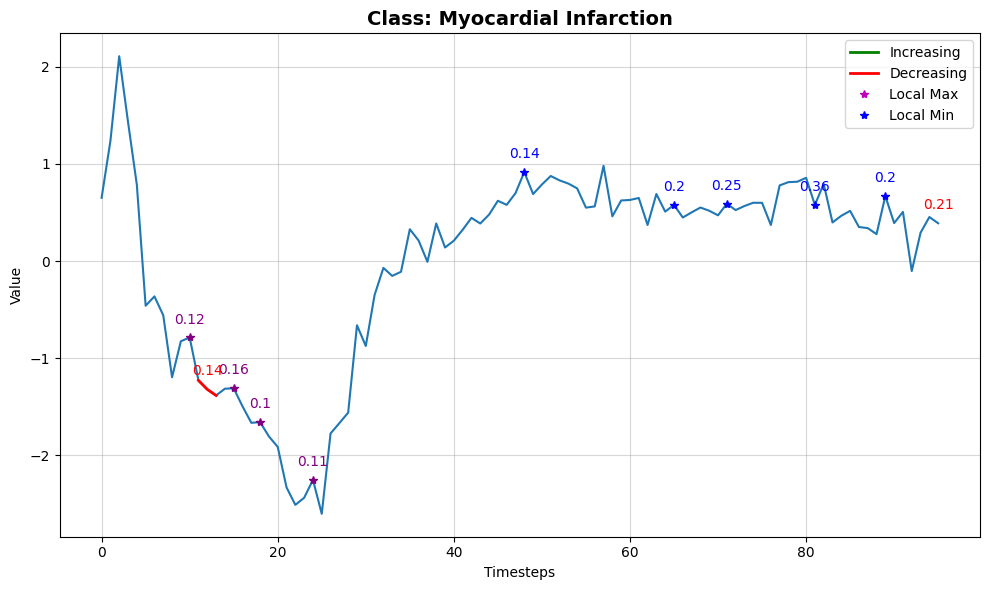

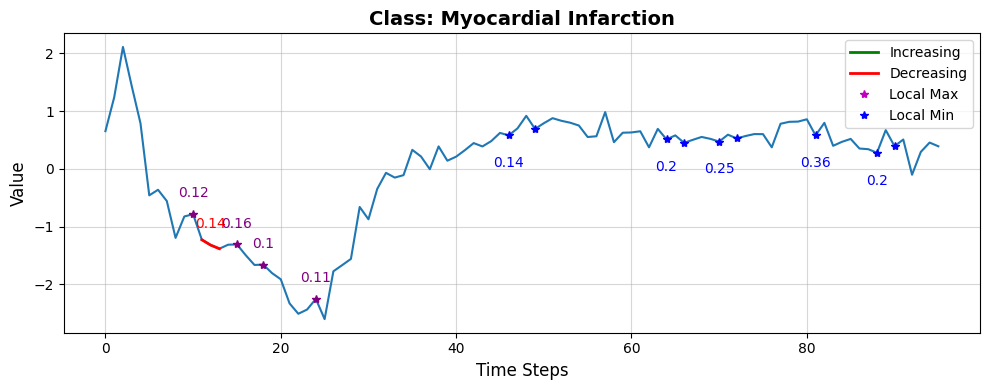

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([0.9301, 0.0699])
Myocardial Infarction:                      0.9301
Normal Heartbeat:                      0.0699


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 18320 samples)
Optimal number of clusters for Increasing_ch1: 18
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 15802 samples)
Optimal number of clusters for Decreasing_ch1: 18
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 20254 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 20067 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 74) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 74


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.62
INFO:lomatce.explainer:Local Prediction (Linear Model): 0.93
INFO:lomatce.explainer:Model Type: Ridge


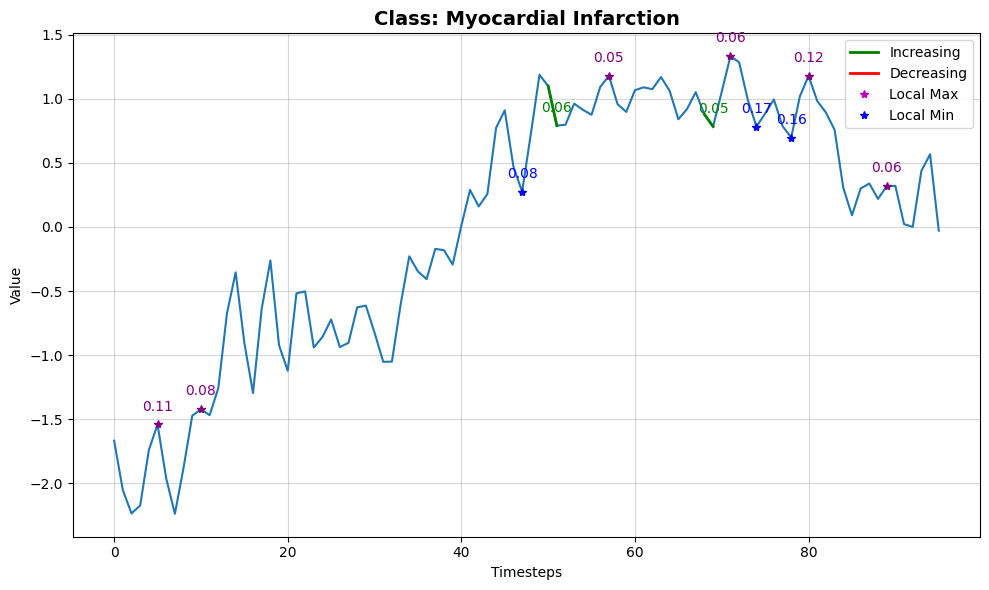

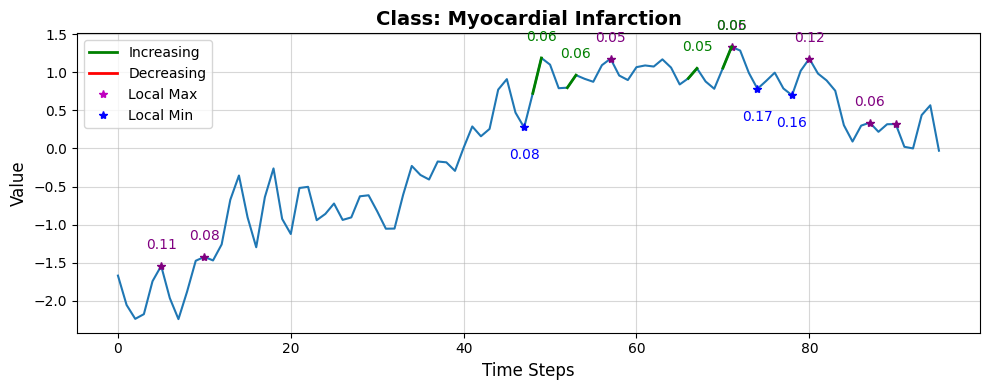

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([0.9482, 0.0518])
Myocardial Infarction:                      0.9482
Normal Heartbeat:                      0.0518


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 7403 samples)
Optimal number of clusters for Increasing_ch1: 15
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 9811 samples)
Optimal number of clusters for Decreasing_ch1: 18
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 14329 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 15200 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 71) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 71


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.42
INFO:lomatce.explainer:Local Prediction (Linear Model): 1.0
INFO:lomatce.explainer:Model Type: Ridge


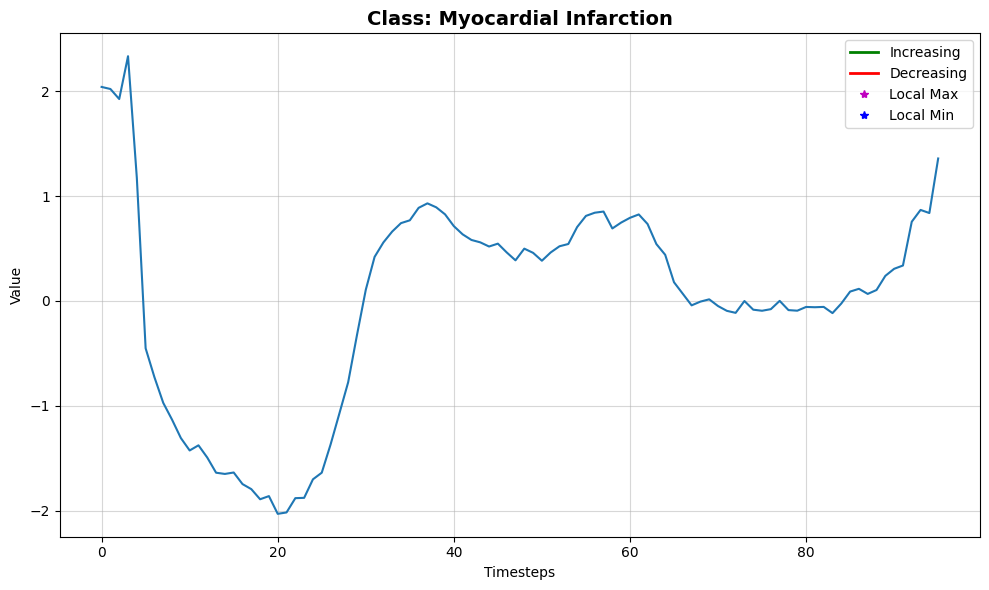

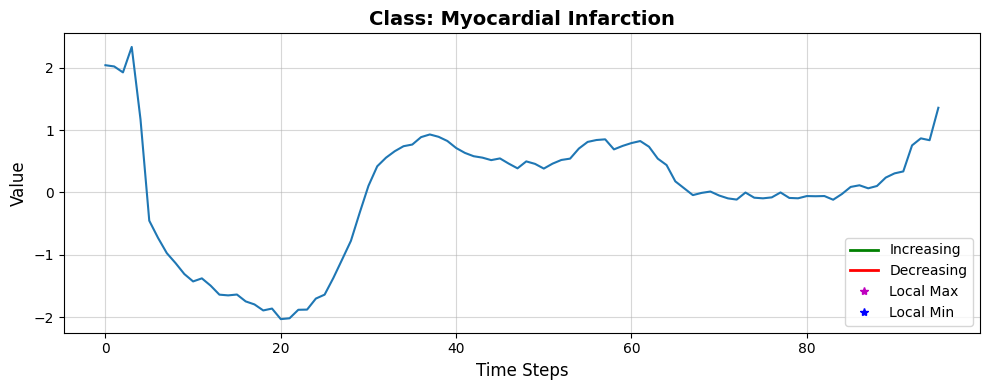

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([1.0000e+00, 4.3582e-08])
Myocardial Infarction:                      1.0000
Normal Heartbeat:                      0.0000


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 9912 samples)
Optimal number of clusters for Increasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 6379 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 15882 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 16045 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 76) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 76


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.85
INFO:lomatce.explainer:Local Prediction (Linear Model): 0.8
INFO:lomatce.explainer:Model Type: Ridge


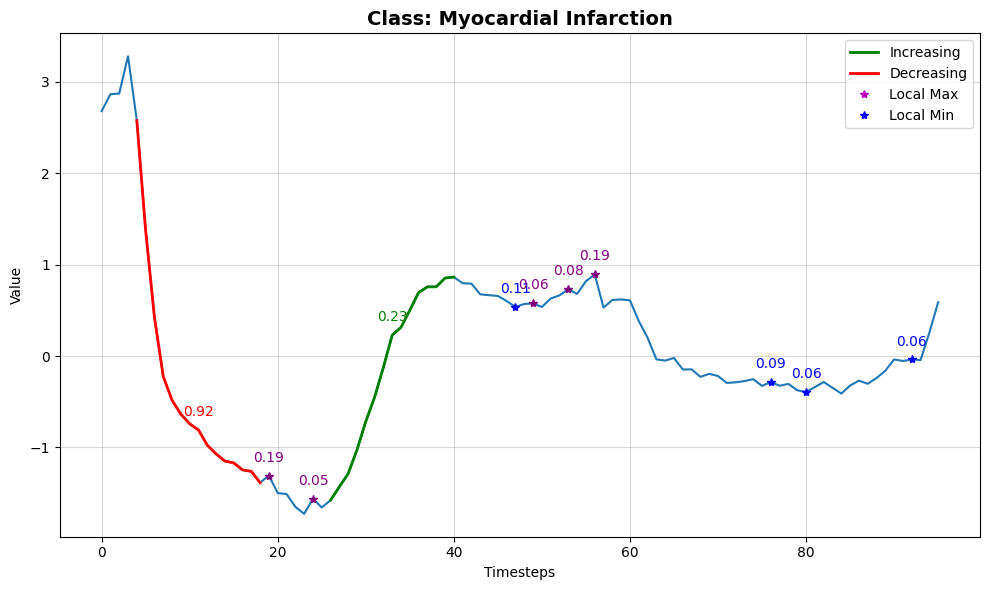

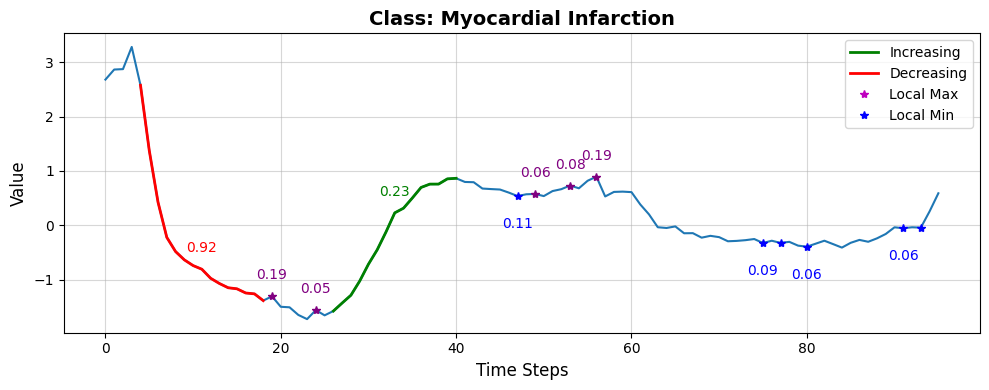

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([0.8359, 0.1641])
Myocardial Infarction:                      0.8359
Normal Heartbeat:                      0.1641


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 5610 samples)
Optimal number of clusters for Increasing_ch1: 17
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 14386 samples)
Optimal number of clusters for Decreasing_ch1: 18
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 17182 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 16132 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 73) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 73


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.84
INFO:lomatce.explainer:Local Prediction (Linear Model): 0.78
INFO:lomatce.explainer:Model Type: Ridge


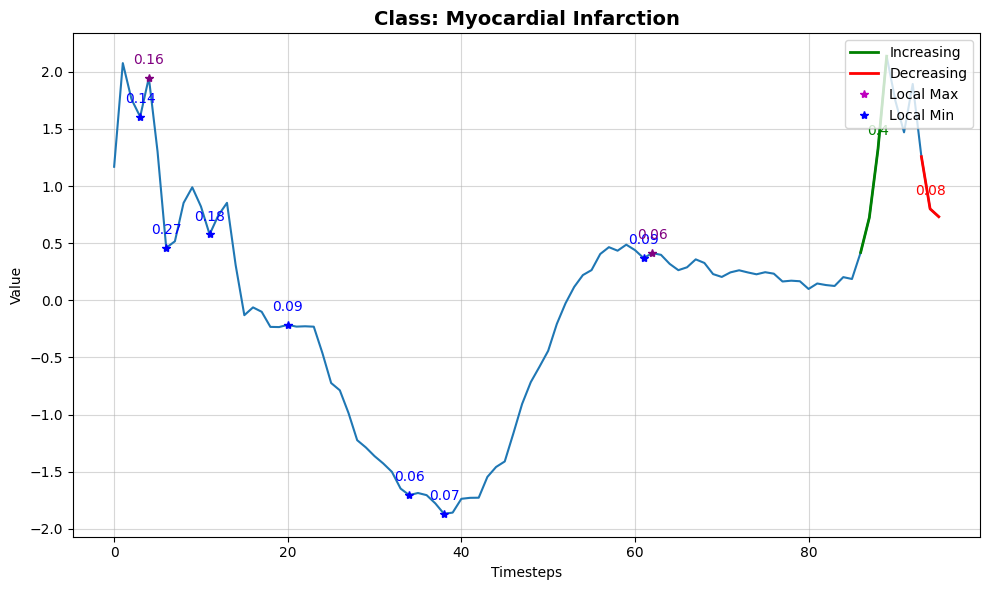

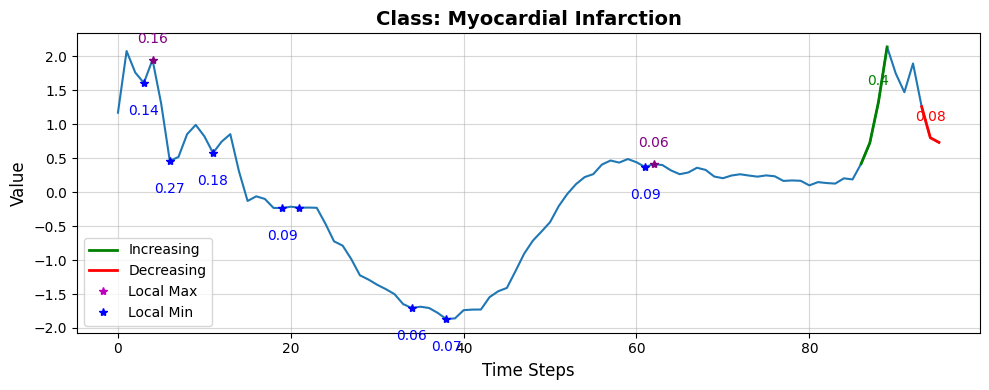

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([0.7908, 0.2092])
Myocardial Infarction:                      0.7908
Normal Heartbeat:                      0.2092


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 8875 samples)
Optimal number of clusters for Increasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 11476 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 23766 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 23391 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 76) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 76


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.83
INFO:lomatce.explainer:Local Prediction (Linear Model): 0.89
INFO:lomatce.explainer:Model Type: Ridge


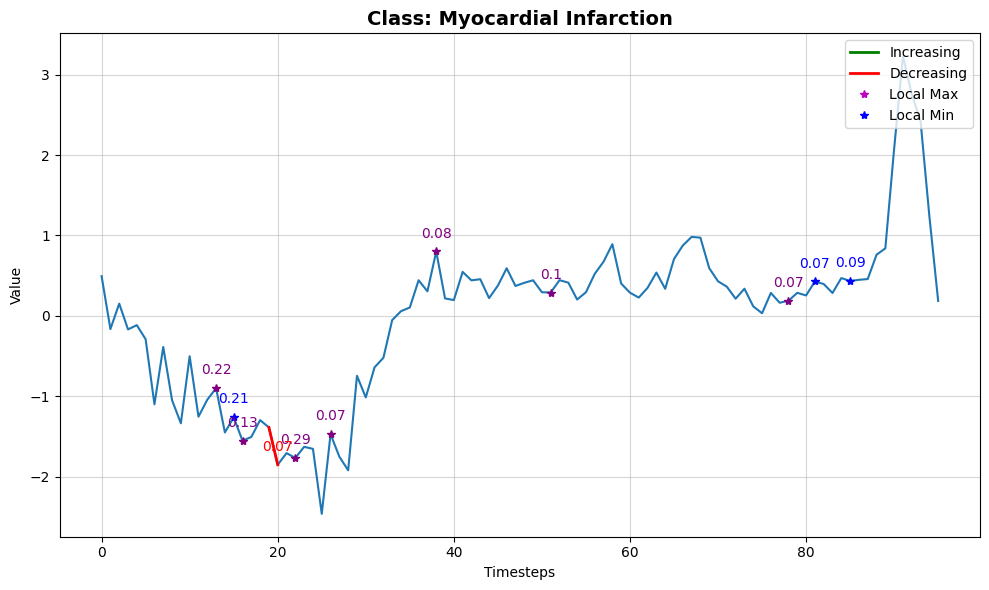

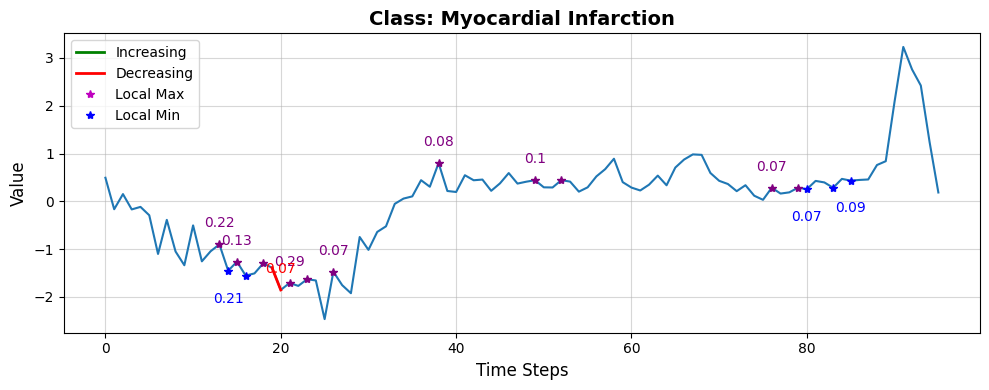

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([0.9368, 0.0632])
Myocardial Infarction:                      0.9368
Normal Heartbeat:                      0.0632


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 8051 samples)
Optimal number of clusters for Increasing_ch1: 18
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 11635 samples)
Optimal number of clusters for Decreasing_ch1: 14
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 16178 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 14935 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 70) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 70


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.53
INFO:lomatce.explainer:Local Prediction (Linear Model): 1.01
INFO:lomatce.explainer:Model Type: Ridge


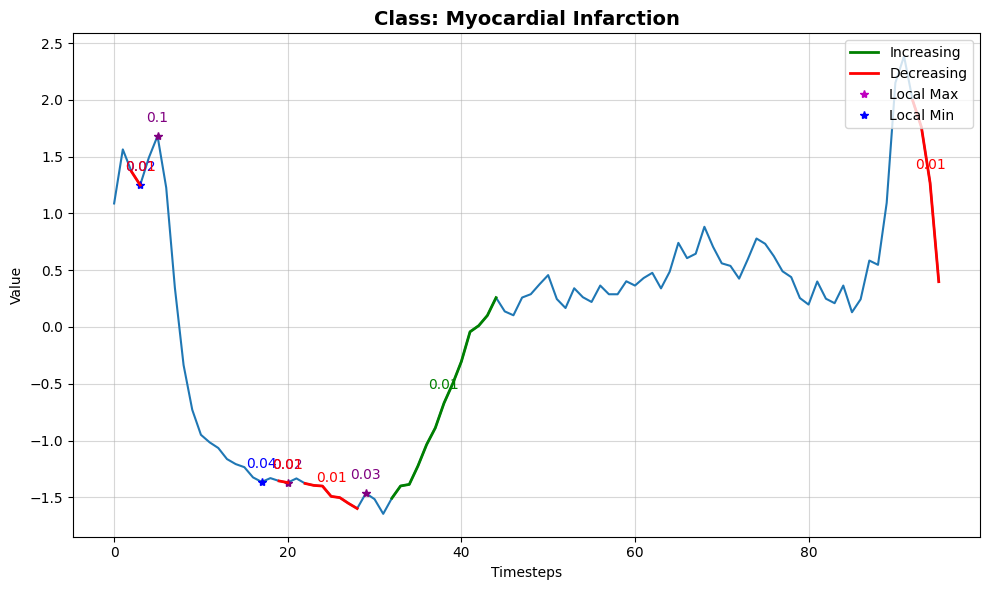

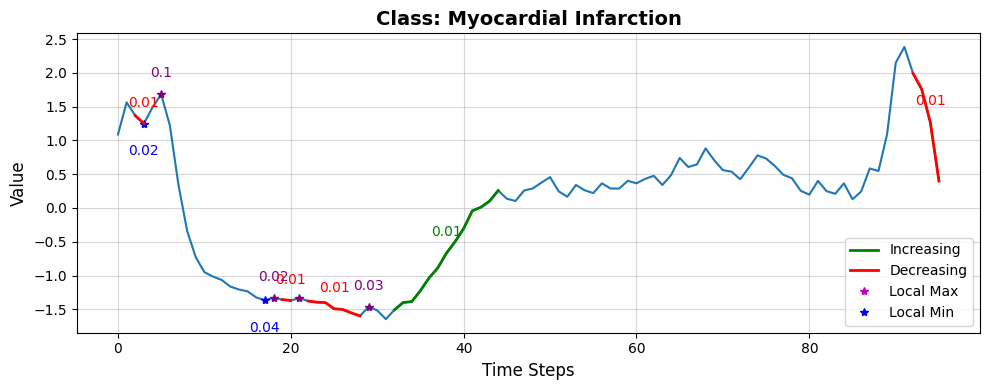

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([9.9990e-01, 1.0384e-04])
Myocardial Infarction:                      0.9999
Normal Heartbeat:                      0.0001


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 9814 samples)
Optimal number of clusters for Increasing_ch1: 18
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 9911 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 21064 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 19855 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 75) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 75


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.56
INFO:lomatce.explainer:Local Prediction (Linear Model): 1.0
INFO:lomatce.explainer:Model Type: Ridge


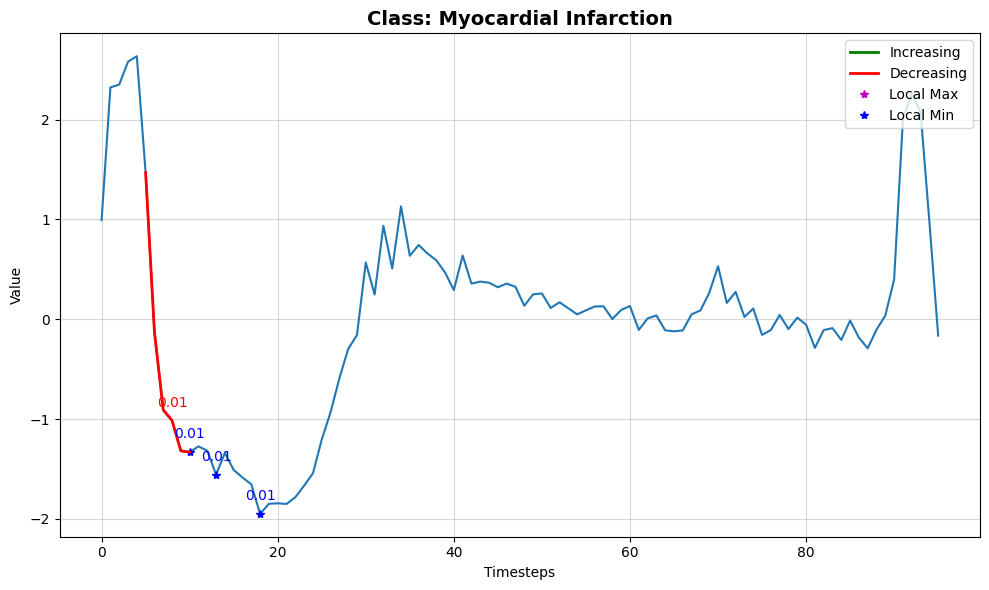

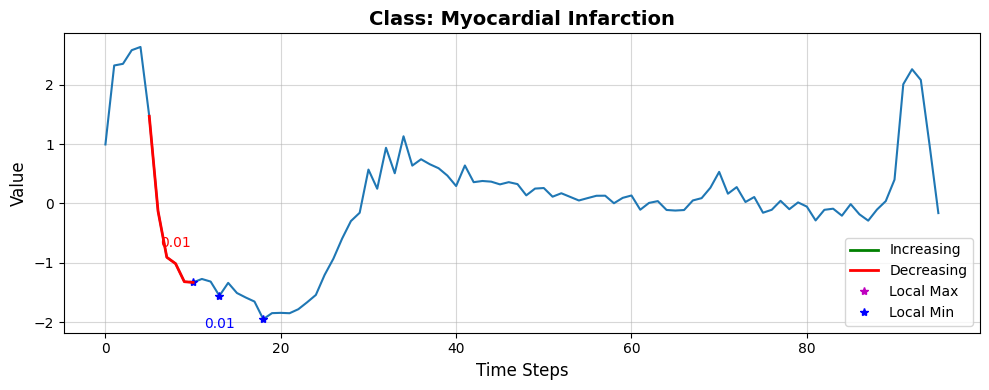

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([9.9999e-01, 6.2273e-06])
Myocardial Infarction:                      1.0000
Normal Heartbeat:                      0.0000


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 9201 samples)
Optimal number of clusters for Increasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 12328 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 19641 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 19578 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 76) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 76


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.82
INFO:lomatce.explainer:Local Prediction (Linear Model): 0.72
INFO:lomatce.explainer:Model Type: Ridge


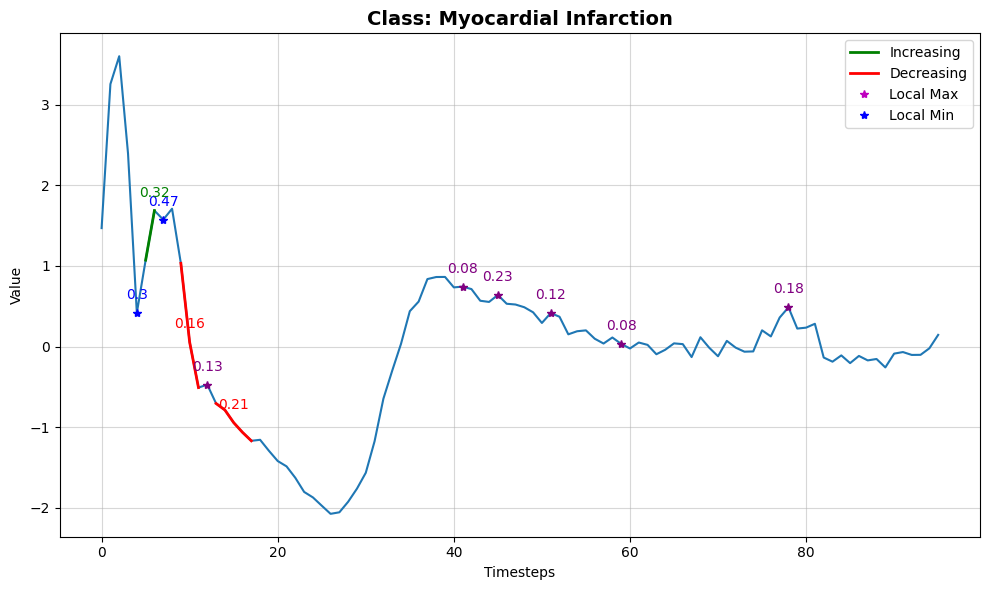

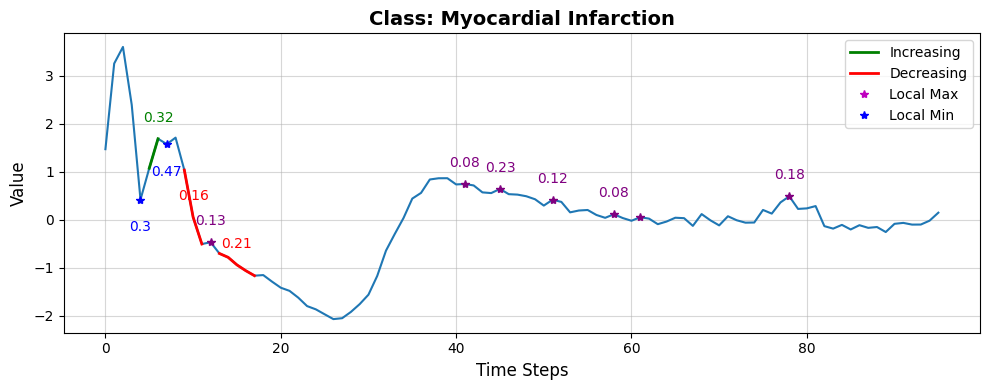

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([0.7987, 0.2013])
Myocardial Infarction:                      0.7987
Normal Heartbeat:                      0.2013

📈 Global Faithfulness (Avg Local Fidelity): 0.7139

=== Running SP-LOMATCE for class Normal Heartbeat ===


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 12542 samples)
Optimal number of clusters for Increasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 11427 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 17775 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 16723 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 76) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 76


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.91
INFO:lomatce.explainer:Local Prediction (Linear Model): 0.99
INFO:lomatce.explainer:Model Type: Ridge


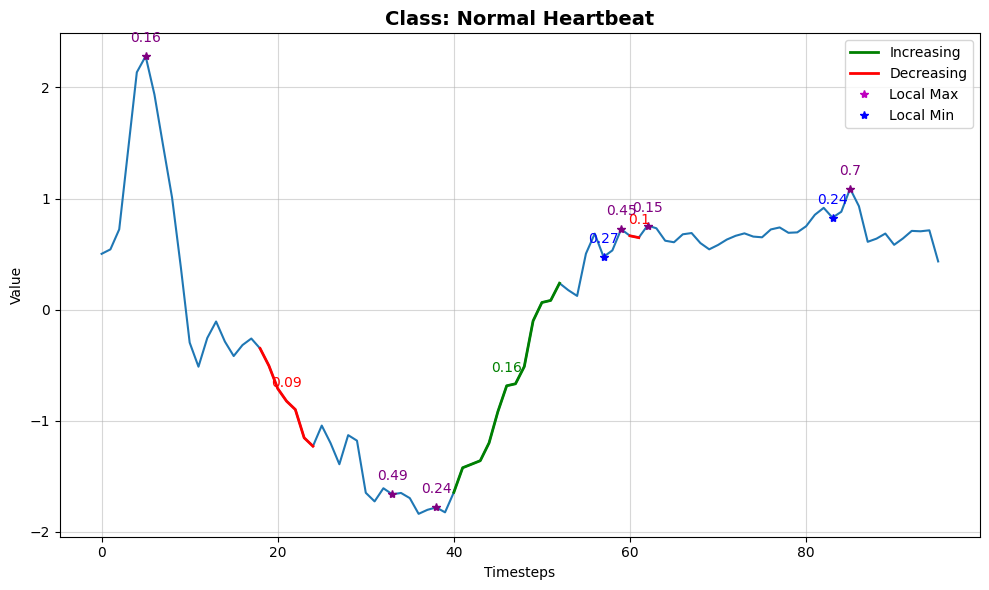

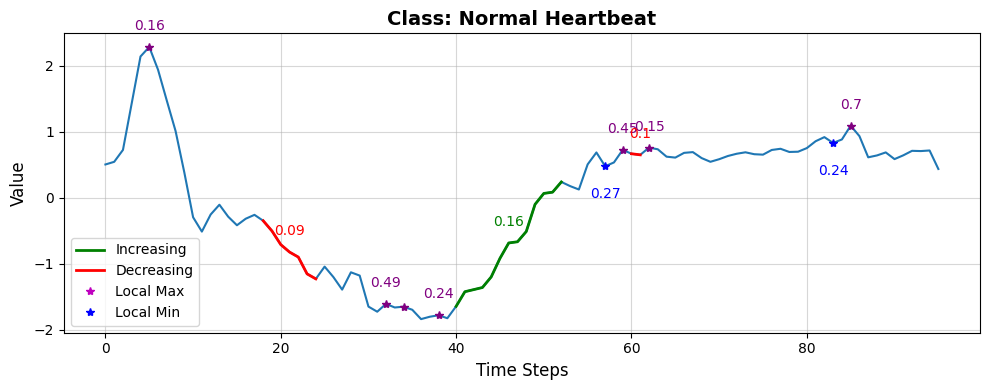

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([0.0169, 0.9831])
Myocardial Infarction:                      0.0169
Normal Heartbeat:                      0.9831


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 10705 samples)
Optimal number of clusters for Increasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 9808 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 17795 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 17685 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 76) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 76


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.76
INFO:lomatce.explainer:Local Prediction (Linear Model): 1.04
INFO:lomatce.explainer:Model Type: Ridge


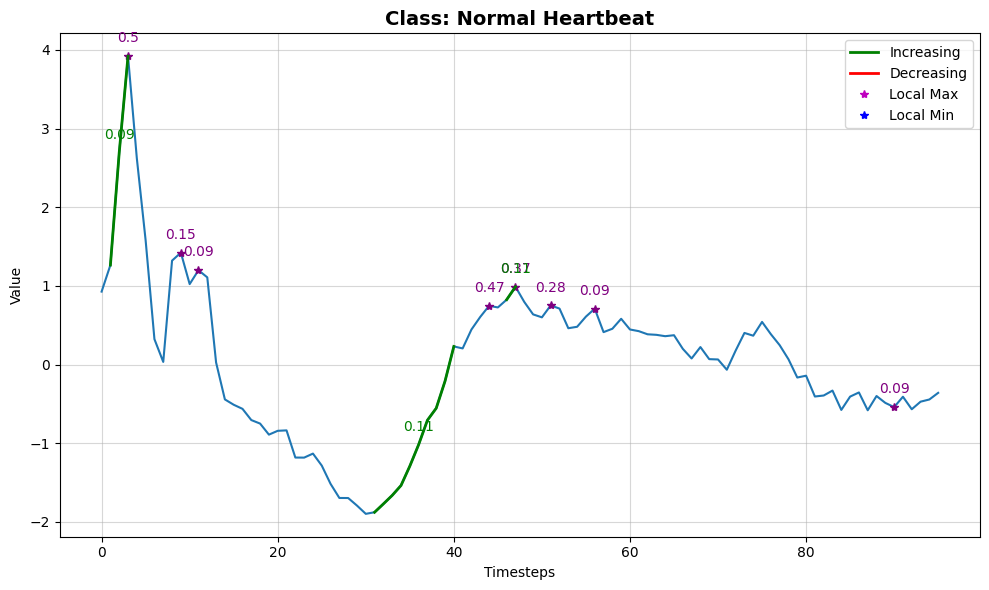

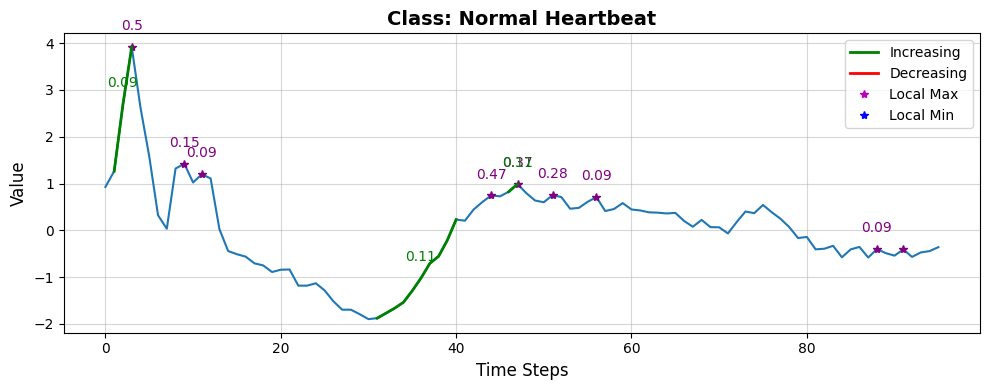

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([2.6427e-06, 1.0000e+00])
Myocardial Infarction:                      0.0000
Normal Heartbeat:                      1.0000


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 6677 samples)
Optimal number of clusters for Increasing_ch1: 13
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 8941 samples)
Optimal number of clusters for Decreasing_ch1: 18
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 16911 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 16630 samples)
Optimal number of clusters for LocalMin_ch1: 18


INFO:lomatce.explainer:Final data shape: (1001, 68) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 68


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.53
INFO:lomatce.explainer:Local Prediction (Linear Model): 1.01
INFO:lomatce.explainer:Model Type: Ridge


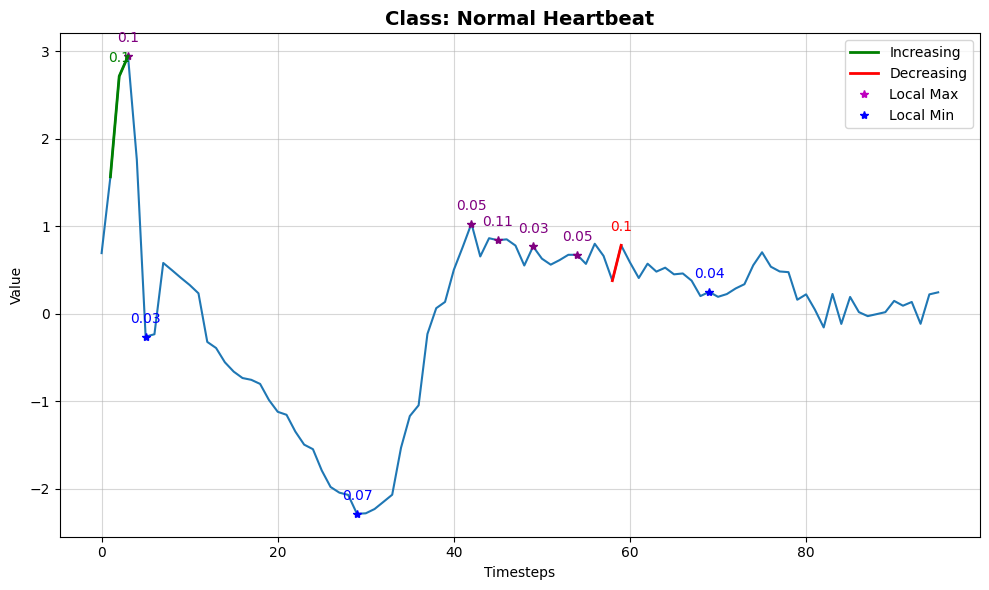

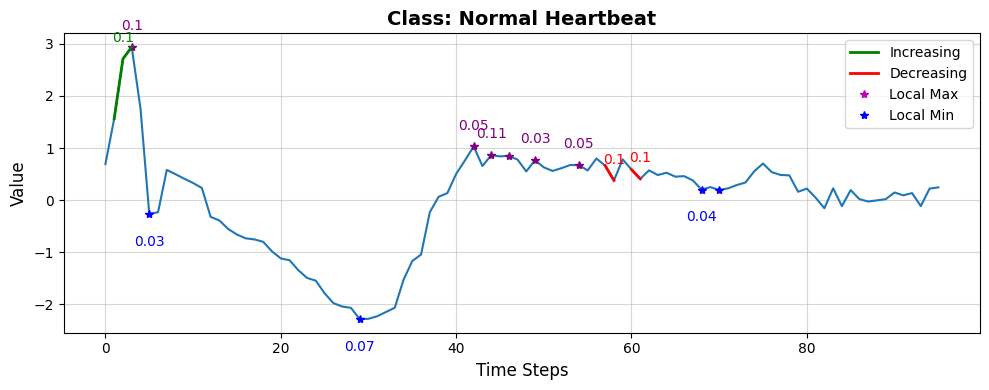

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([4.1801e-10, 1.0000e+00])
Myocardial Infarction:                      0.0000
Normal Heartbeat:                      1.0000


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 8352 samples)
Optimal number of clusters for Increasing_ch1: 18
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 9649 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 22916 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 22590 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 75) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 75


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.93
INFO:lomatce.explainer:Local Prediction (Linear Model): 1.01
INFO:lomatce.explainer:Model Type: Ridge


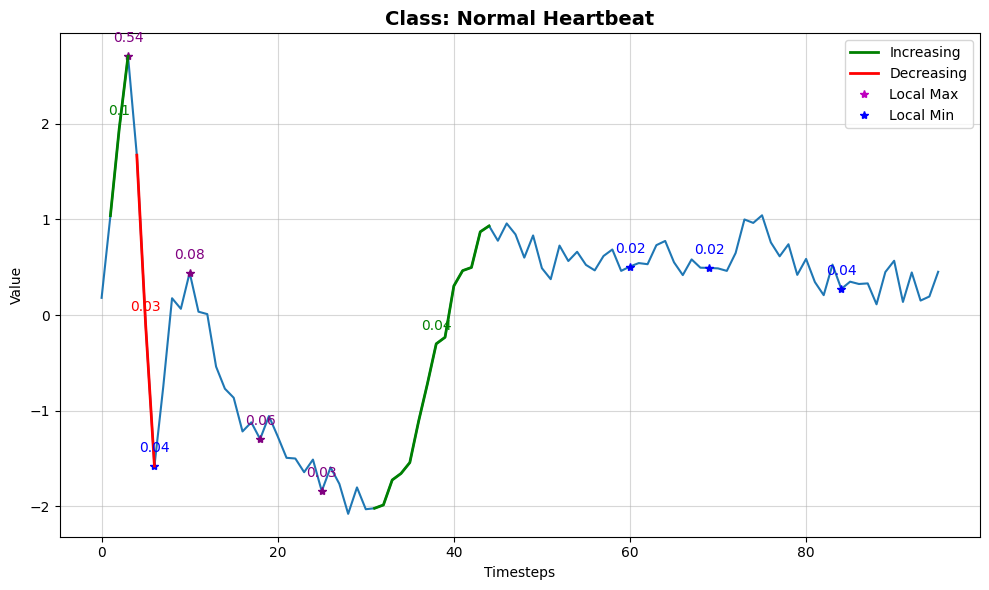

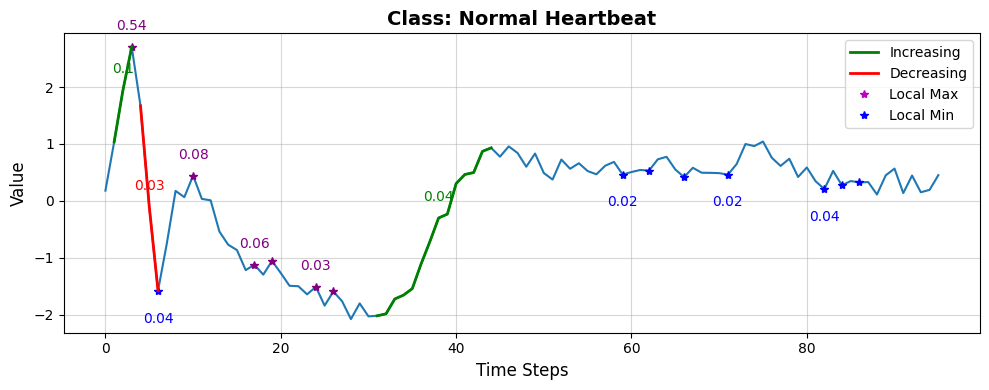

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([1.4172e-10, 1.0000e+00])
Myocardial Infarction:                      0.0000
Normal Heartbeat:                      1.0000


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 10809 samples)
Optimal number of clusters for Increasing_ch1: 18
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 14240 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 24529 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 23465 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 75) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 75


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.17
INFO:lomatce.explainer:Local Prediction (Linear Model): 1.01
INFO:lomatce.explainer:Model Type: Ridge


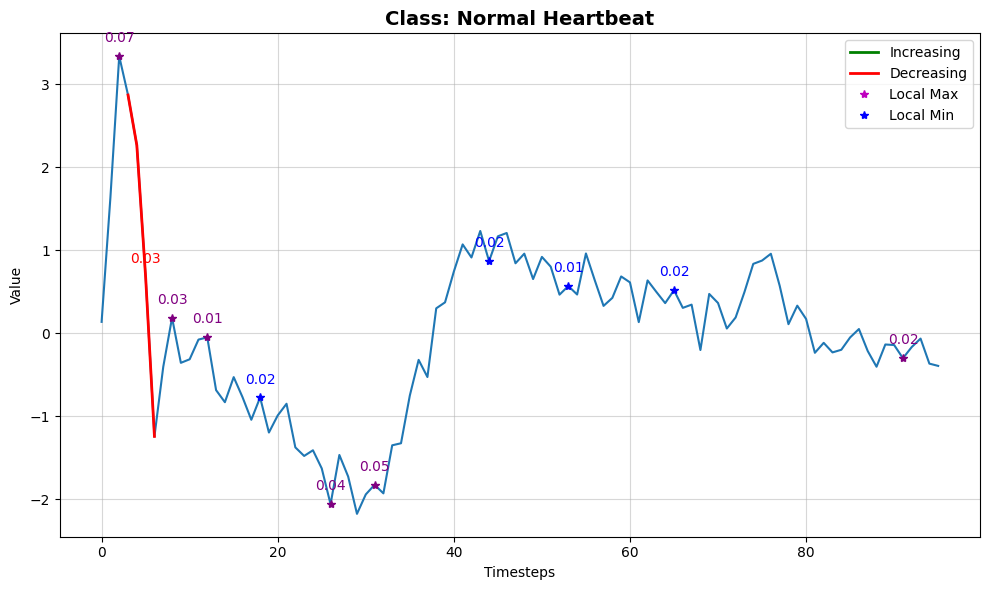

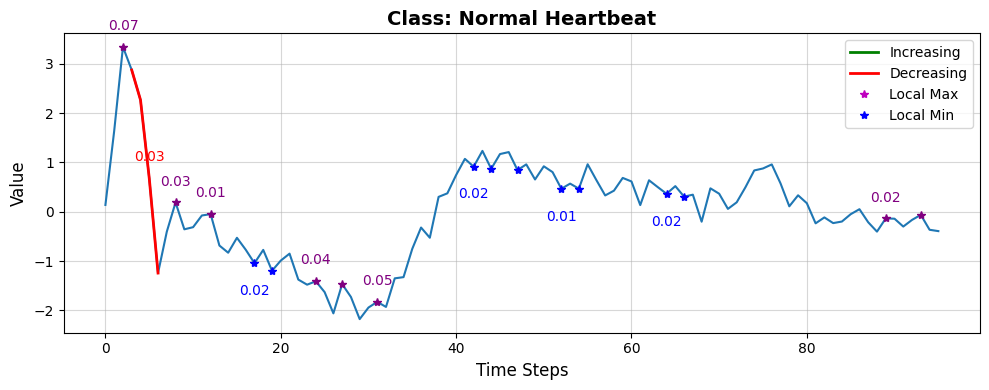

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([1.4436e-16, 1.0000e+00])
Myocardial Infarction:                      0.0000
Normal Heartbeat:                      1.0000


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 11694 samples)
Optimal number of clusters for Increasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 10677 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 21056 samples)
Optimal number of clusters for LocalMax_ch1: 18
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 20847 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 75) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 75


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.59
INFO:lomatce.explainer:Local Prediction (Linear Model): 1.08
INFO:lomatce.explainer:Model Type: Ridge


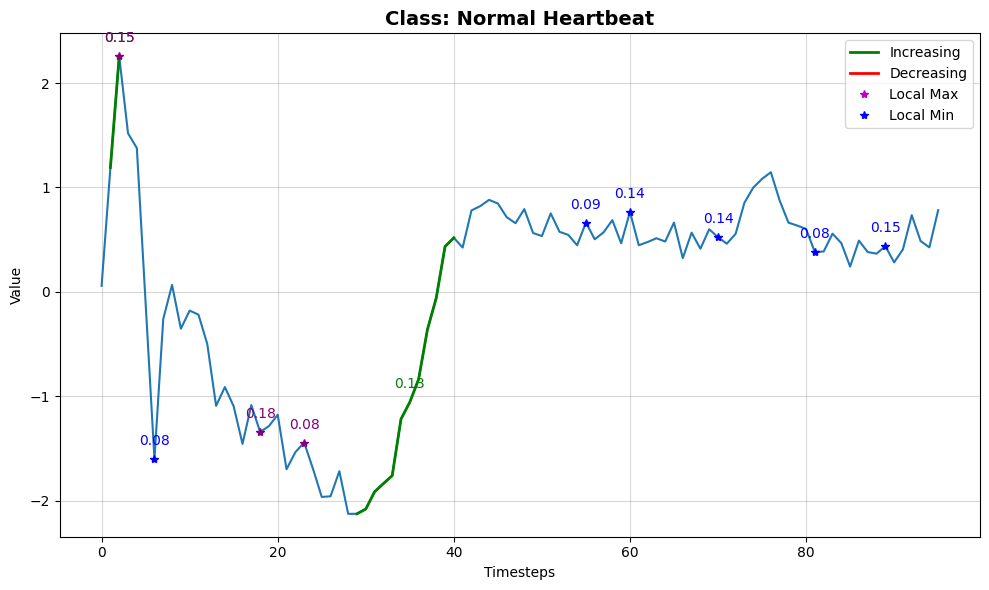

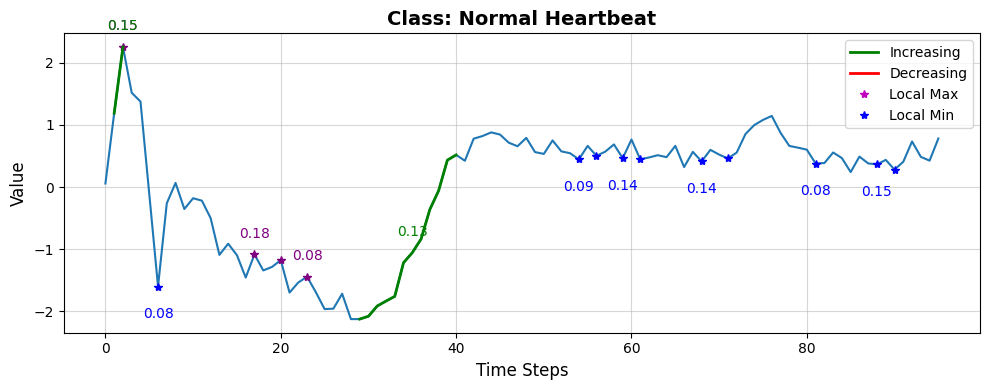

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([6.3353e-08, 1.0000e+00])
Myocardial Infarction:                      0.0000
Normal Heartbeat:                      1.0000


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 13348 samples)
Optimal number of clusters for Increasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 8989 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 26341 samples)
Optimal number of clusters for LocalMax_ch1: 18
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 26085 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 75) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 75


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.25
INFO:lomatce.explainer:Local Prediction (Linear Model): 1.0
INFO:lomatce.explainer:Model Type: Ridge


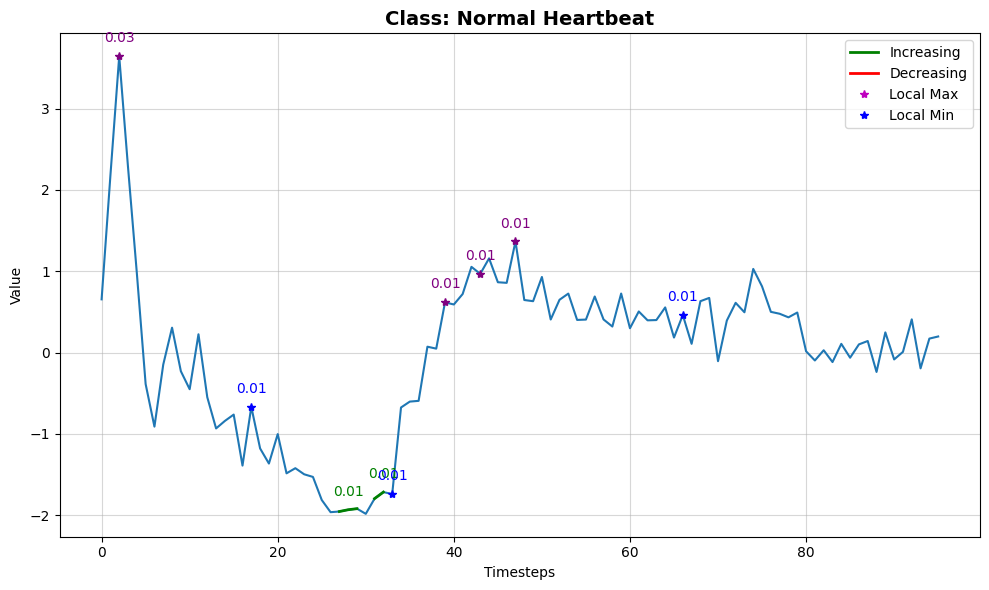

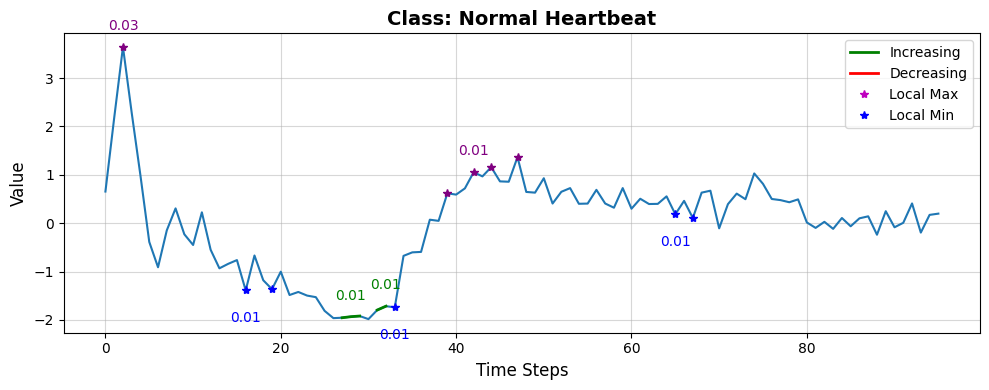

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([6.1838e-15, 1.0000e+00])
Myocardial Infarction:                      0.0000
Normal Heartbeat:                      1.0000


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 9201 samples)
Optimal number of clusters for Increasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 12325 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 20223 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 20144 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 76) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 76


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.65
INFO:lomatce.explainer:Local Prediction (Linear Model): 1.03
INFO:lomatce.explainer:Model Type: Ridge


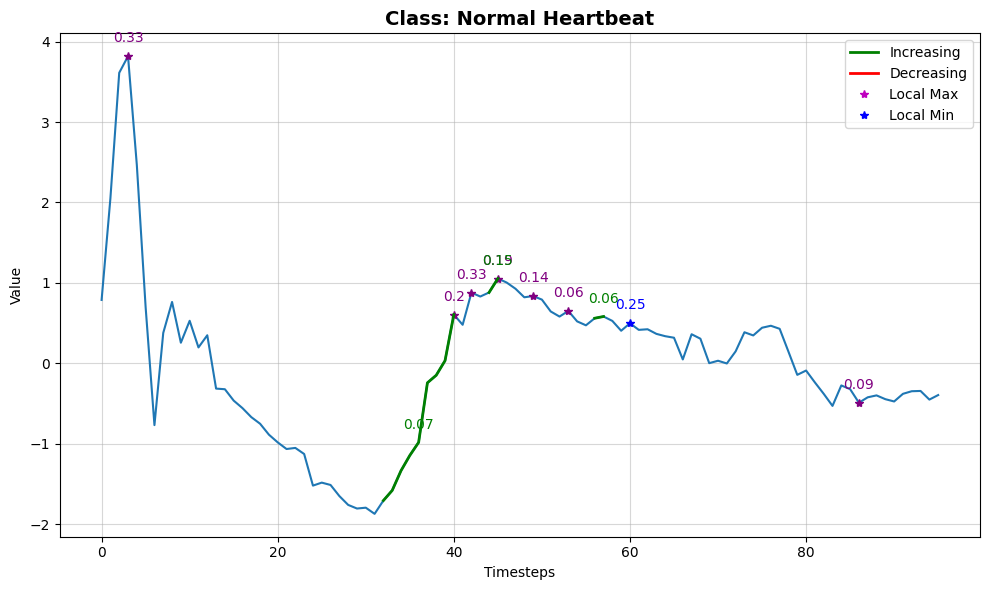

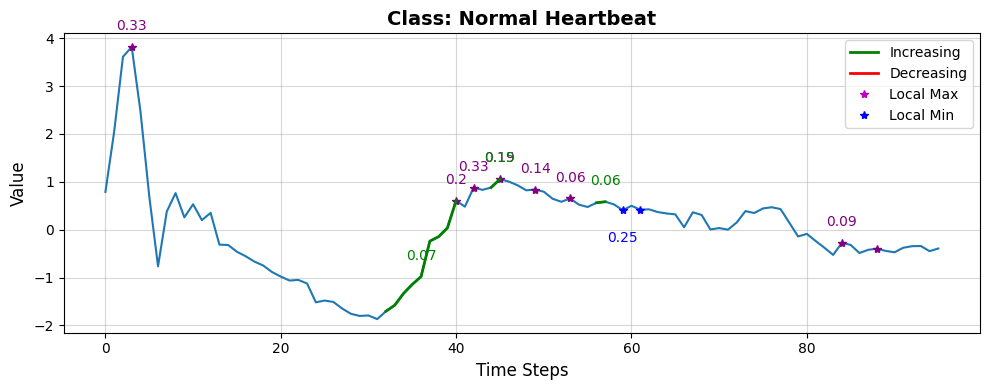

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([1.1087e-09, 1.0000e+00])
Myocardial Infarction:                      0.0000
Normal Heartbeat:                      1.0000


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 13009 samples)
Optimal number of clusters for Increasing_ch1: 17
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 15919 samples)
Optimal number of clusters for Decreasing_ch1: 18
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 23210 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 21919 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 73) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 73


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.89
INFO:lomatce.explainer:Local Prediction (Linear Model): 1.05
INFO:lomatce.explainer:Model Type: Ridge


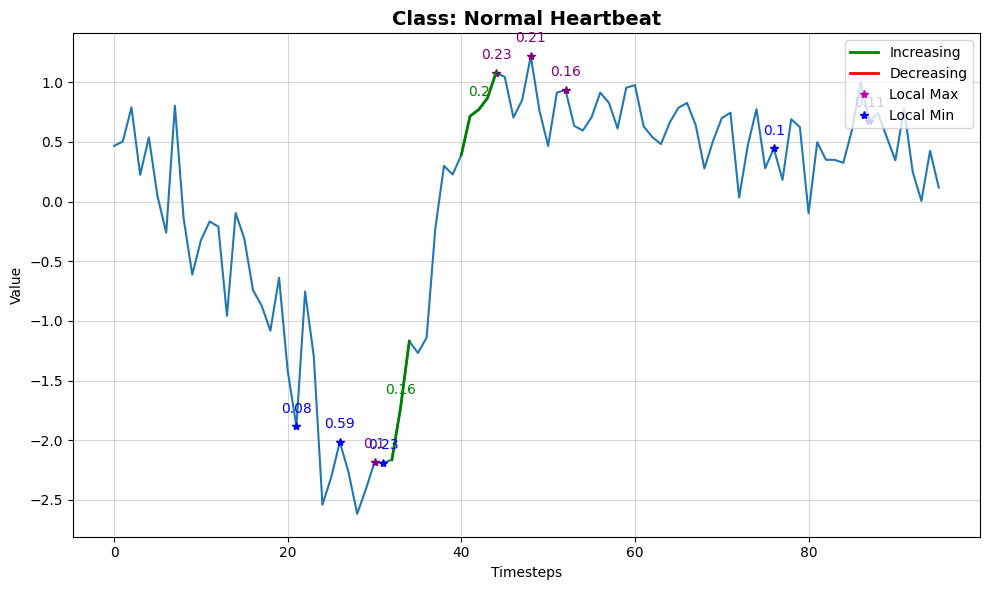

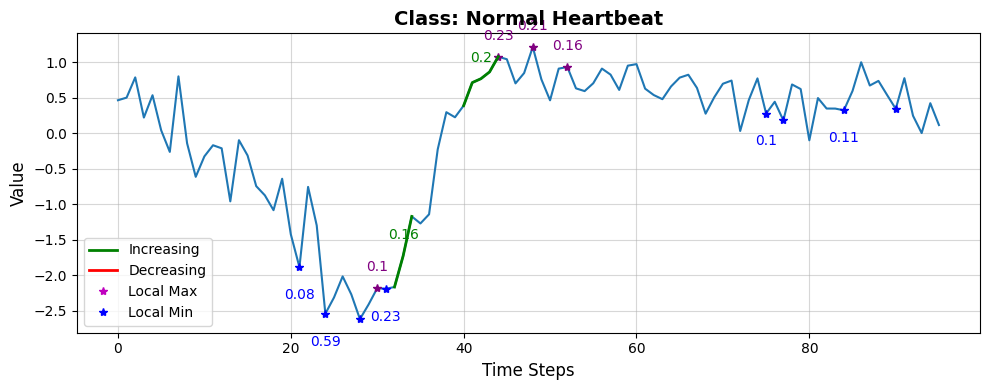

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([0.0019, 0.9981])
Myocardial Infarction:                      0.0019
Normal Heartbeat:                      0.9981


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 9244 samples)
Optimal number of clusters for Increasing_ch1: 18
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 11348 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 23786 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 23590 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 75) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 75


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.19
INFO:lomatce.explainer:Local Prediction (Linear Model): 1.01
INFO:lomatce.explainer:Model Type: Ridge


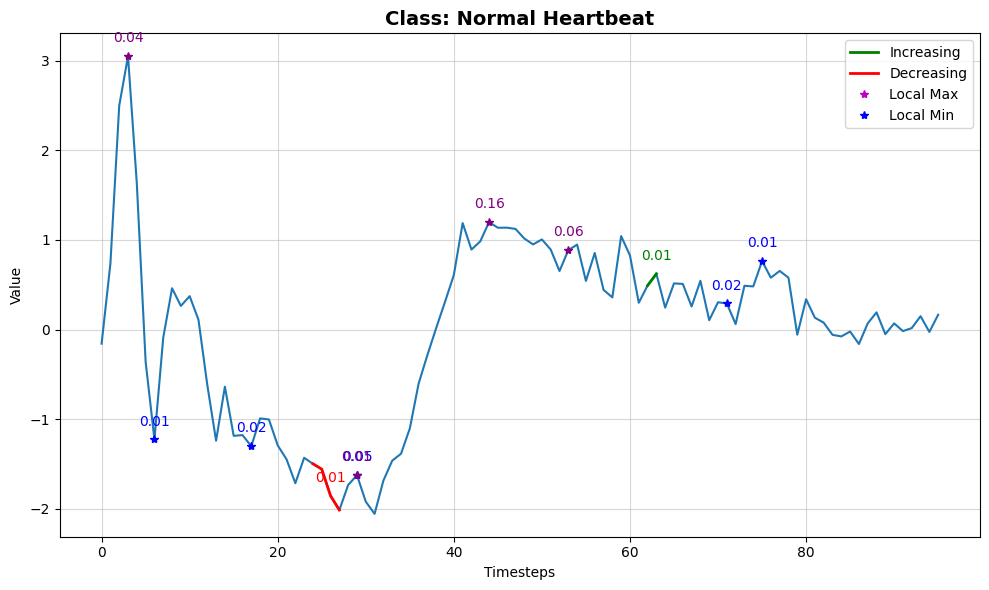

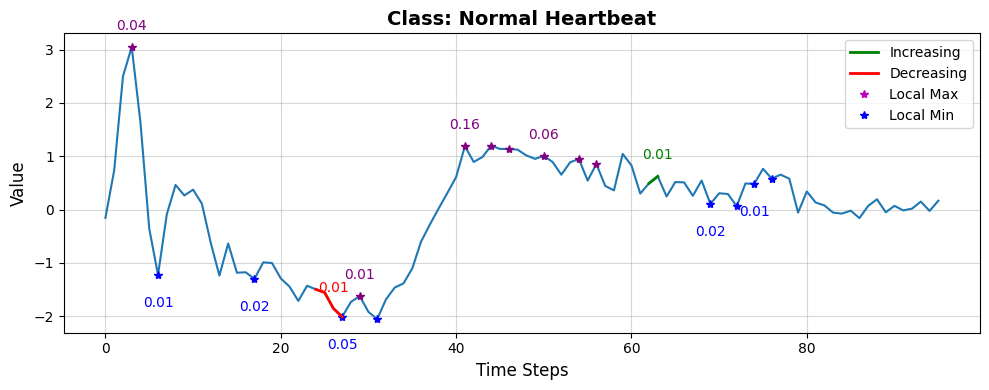

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([1.9722e-12, 1.0000e+00])
Myocardial Infarction:                      0.0000
Normal Heartbeat:                      1.0000


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 9153 samples)
Optimal number of clusters for Increasing_ch1: 18
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 10640 samples)
Optimal number of clusters for Decreasing_ch1: 18
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 16202 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 15901 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 74) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 74


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.84
INFO:lomatce.explainer:Local Prediction (Linear Model): 1.04
INFO:lomatce.explainer:Model Type: Ridge


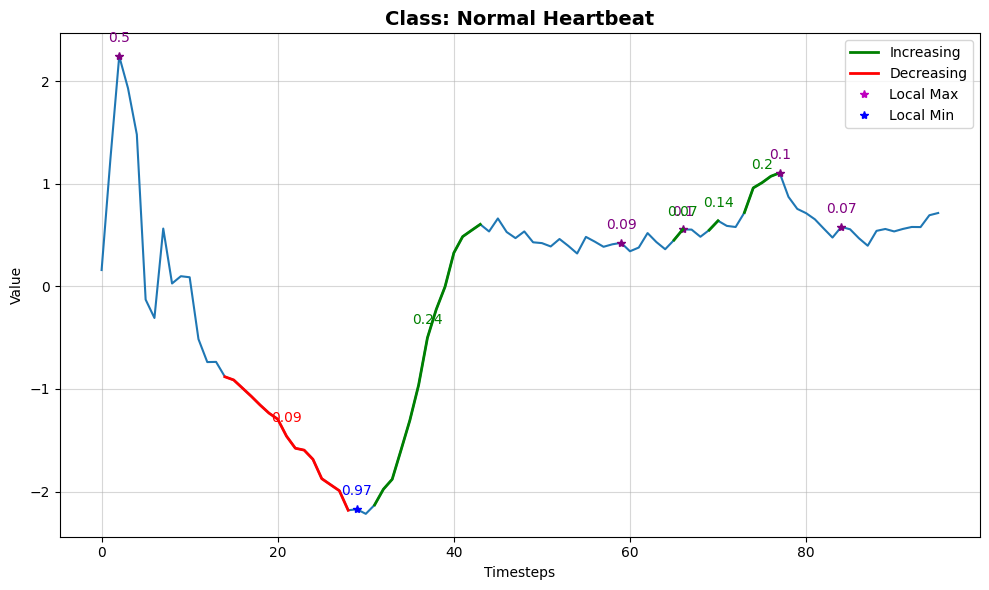

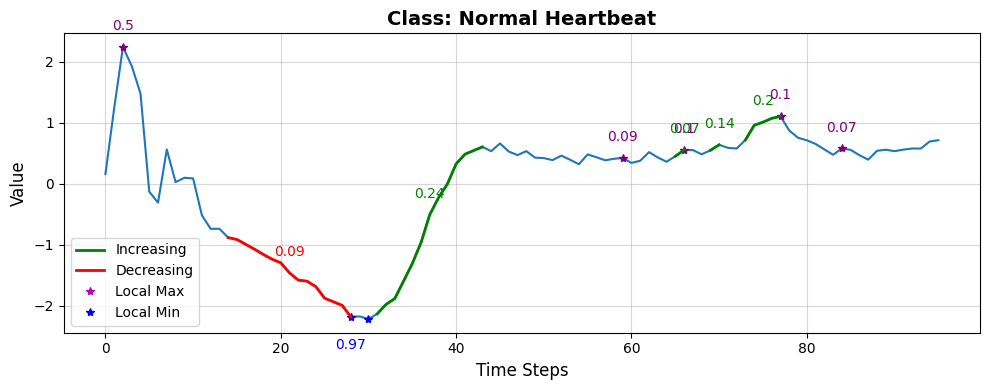

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([9.9466e-05, 9.9990e-01])
Myocardial Infarction:                      0.0001
Normal Heartbeat:                      0.9999


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 7480 samples)
Optimal number of clusters for Increasing_ch1: 16
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 14993 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 19463 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 19264 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 73) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 73


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.47
INFO:lomatce.explainer:Local Prediction (Linear Model): 1.02
INFO:lomatce.explainer:Model Type: Ridge


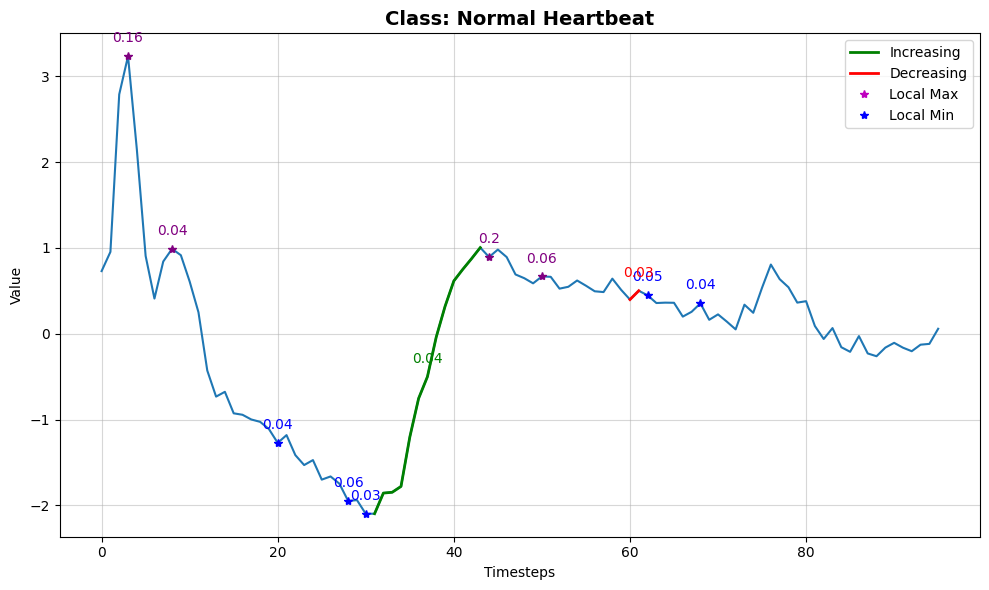

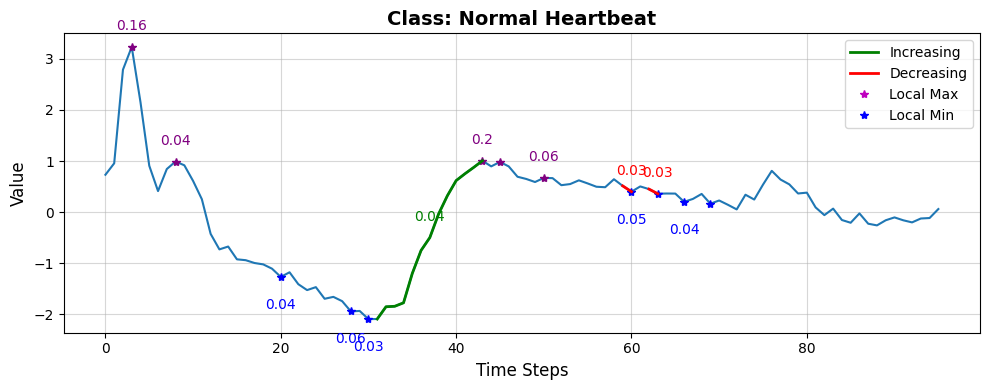

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([3.5997e-11, 1.0000e+00])
Myocardial Infarction:                      0.0000
Normal Heartbeat:                      1.0000


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 11717 samples)
Optimal number of clusters for Increasing_ch1: 17
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 10564 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 19553 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 19228 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 74) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 74


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.76
INFO:lomatce.explainer:Local Prediction (Linear Model): 1.05
INFO:lomatce.explainer:Model Type: Ridge


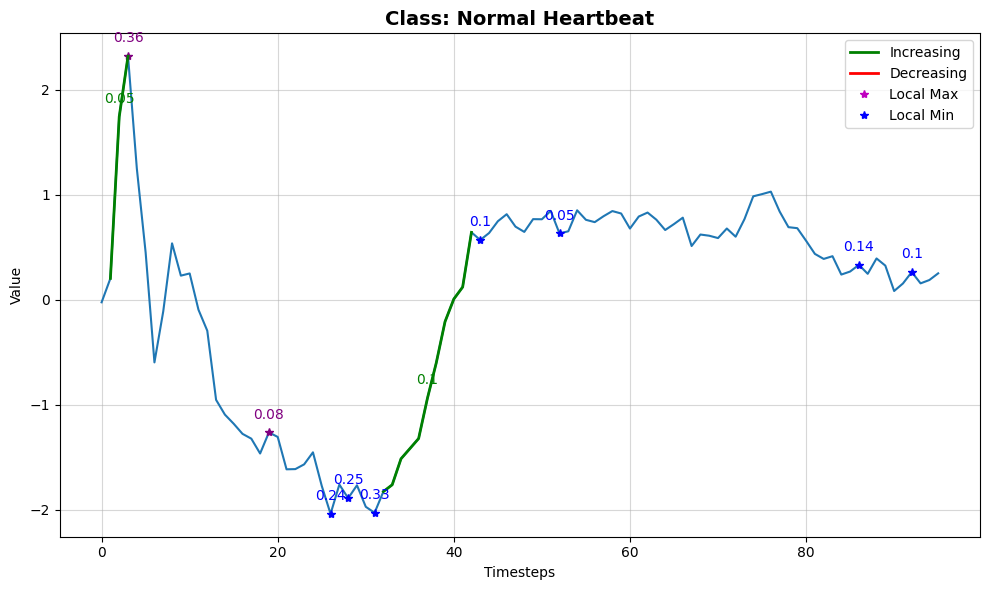

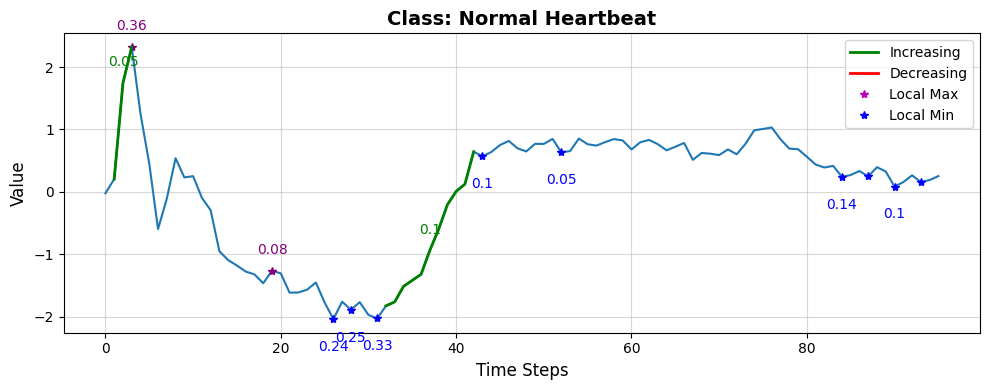

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([5.0446e-06, 9.9999e-01])
Myocardial Infarction:                      0.0000
Normal Heartbeat:                      1.0000


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 13417 samples)
Optimal number of clusters for Increasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 9832 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 25452 samples)
Optimal number of clusters for LocalMax_ch1: 18
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 25356 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 75) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 75


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.78
INFO:lomatce.explainer:Local Prediction (Linear Model): 0.99
INFO:lomatce.explainer:Model Type: Ridge


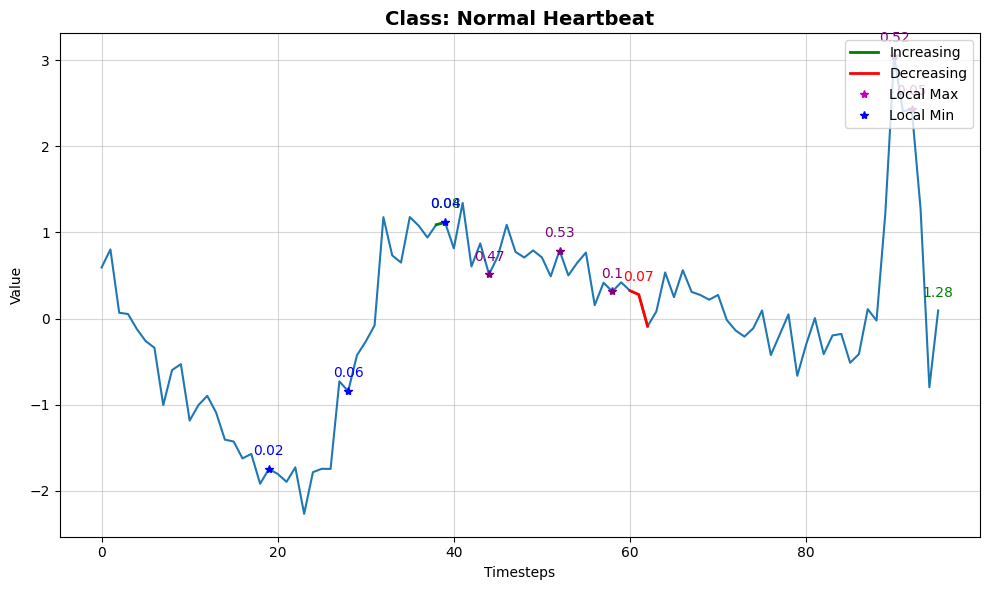

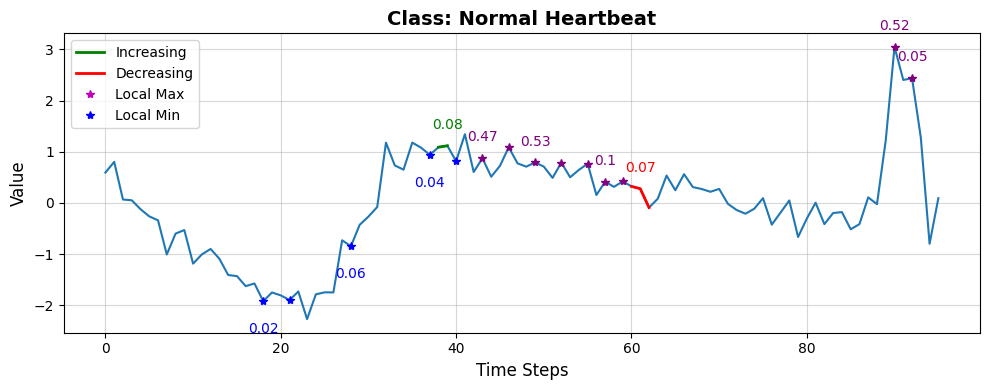

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([1.9931e-06, 1.0000e+00])
Myocardial Infarction:                      0.0000
Normal Heartbeat:                      1.0000


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 10051 samples)
Optimal number of clusters for Increasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 12385 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 20241 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 20061 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 76) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 76


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.75
INFO:lomatce.explainer:Local Prediction (Linear Model): 1.0
INFO:lomatce.explainer:Model Type: Ridge


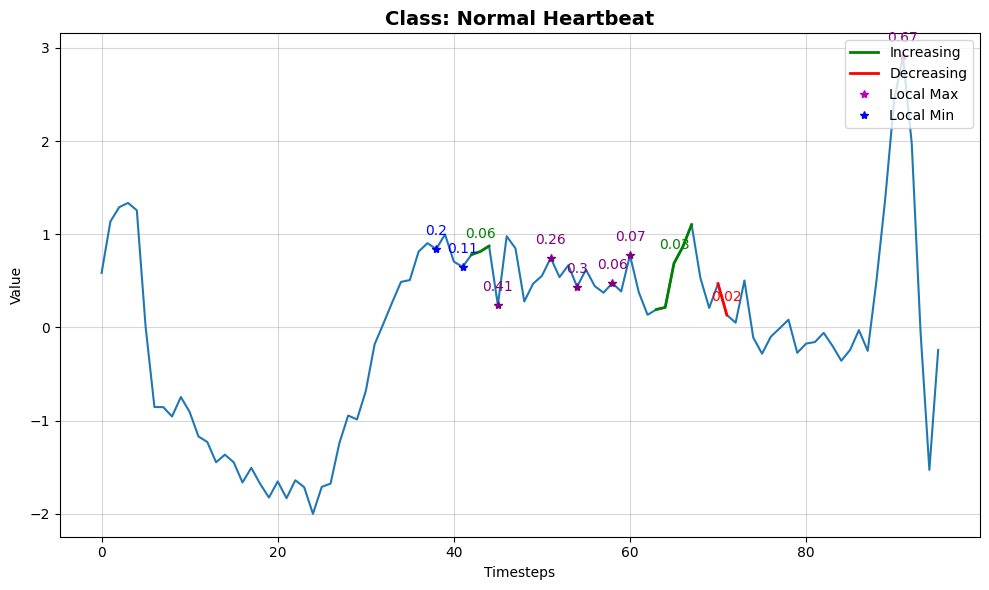

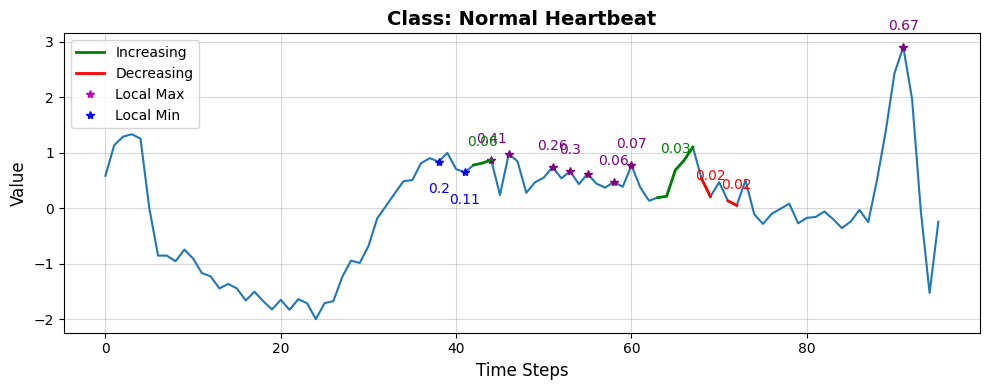

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([2.7849e-07, 1.0000e+00])
Myocardial Infarction:                      0.0000
Normal Heartbeat:                      1.0000


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 10733 samples)
Optimal number of clusters for Increasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 14051 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 23617 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 23524 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 76) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 76


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.62
INFO:lomatce.explainer:Local Prediction (Linear Model): 1.03
INFO:lomatce.explainer:Model Type: Ridge


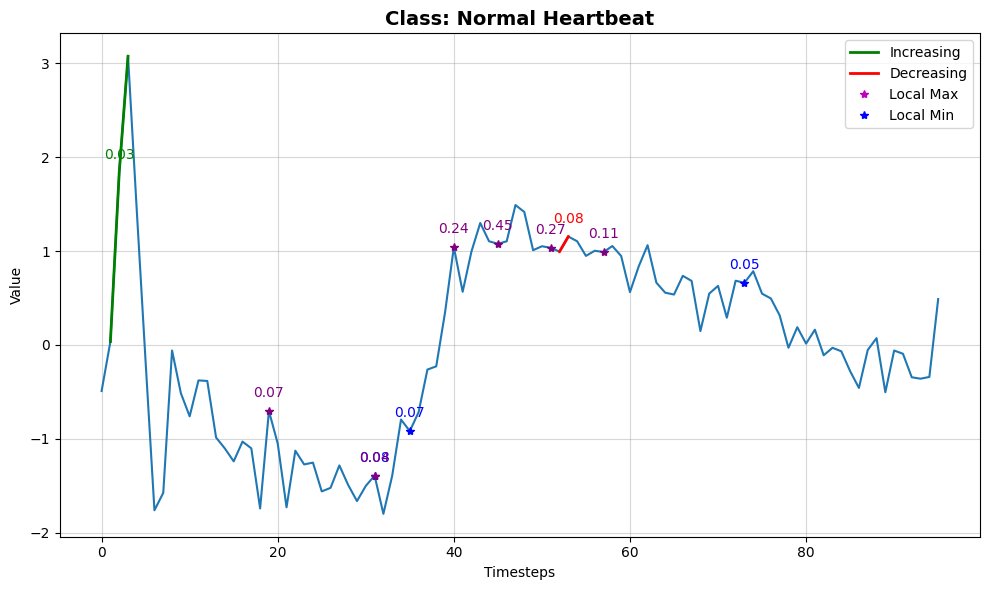

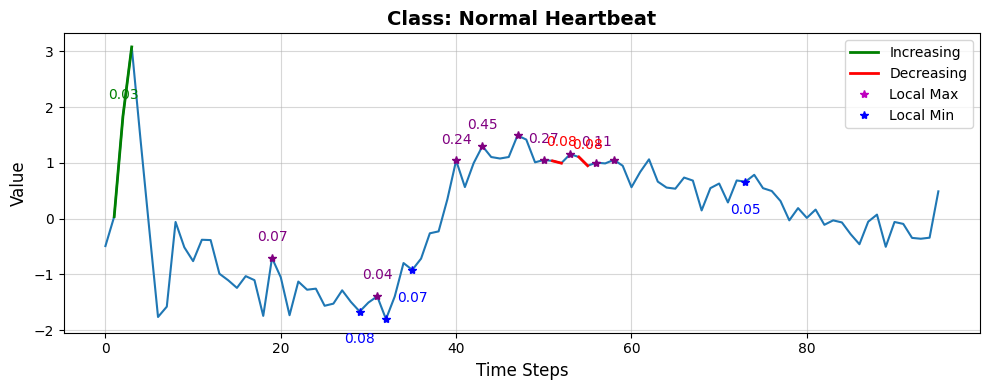

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([8.9500e-09, 1.0000e+00])
Myocardial Infarction:                      0.0000
Normal Heartbeat:                      1.0000


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 11704 samples)
Optimal number of clusters for Increasing_ch1: 18
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 12496 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 27053 samples)
Optimal number of clusters for LocalMax_ch1: 18
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 26751 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 74) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 74


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.65
INFO:lomatce.explainer:Local Prediction (Linear Model): 1.18
INFO:lomatce.explainer:Model Type: Ridge


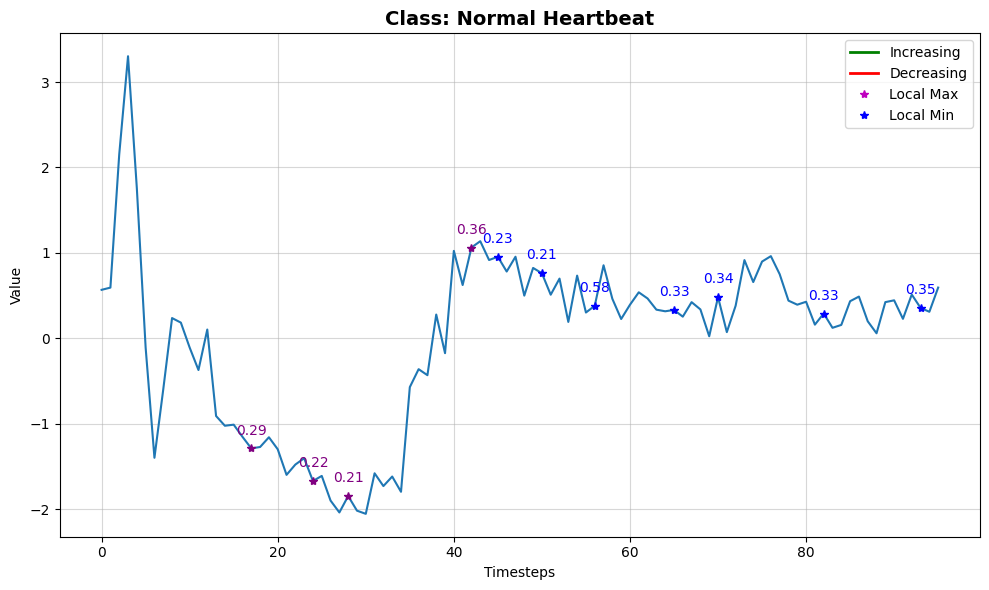

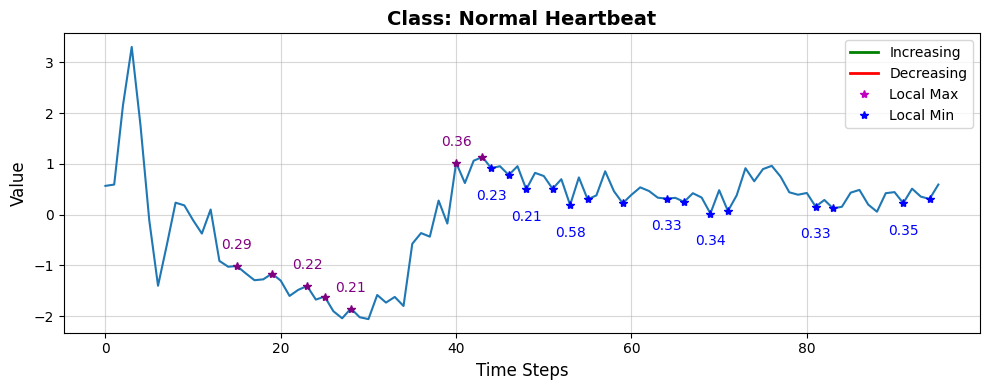

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([1.5198e-09, 1.0000e+00])
Myocardial Infarction:                      0.0000
Normal Heartbeat:                      1.0000


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 7278 samples)
Optimal number of clusters for Increasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 12375 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 20599 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 20309 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 76) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 76


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.86
INFO:lomatce.explainer:Local Prediction (Linear Model): 0.71
INFO:lomatce.explainer:Model Type: Ridge


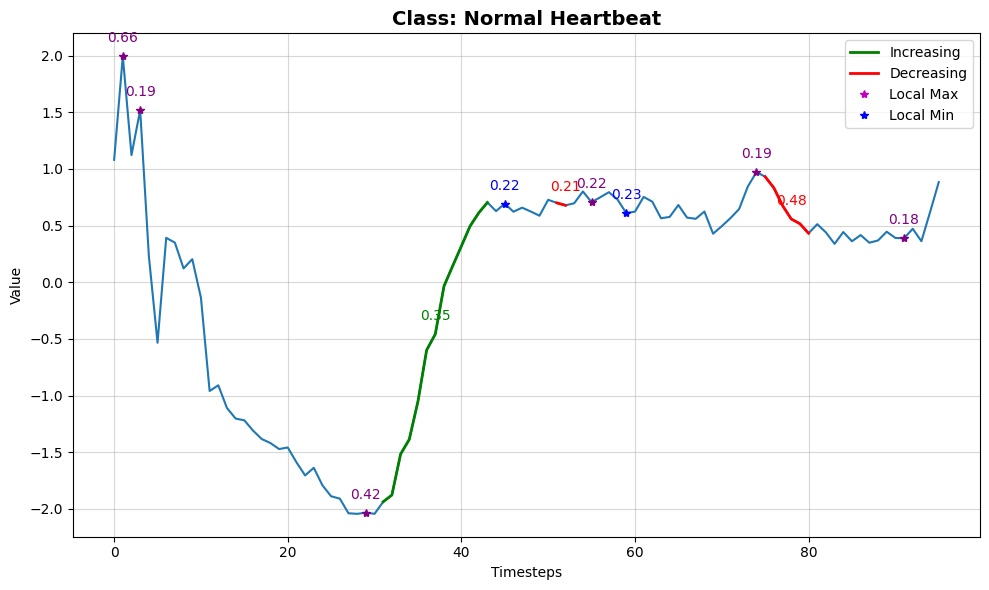

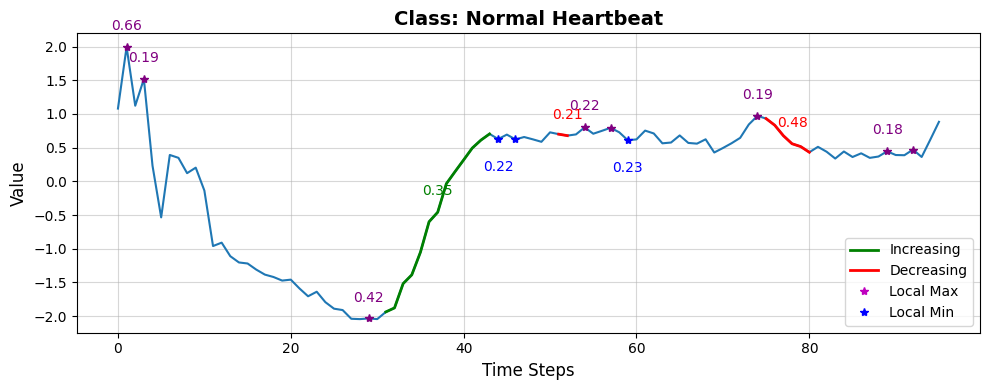

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([0.1988, 0.8012])
Myocardial Infarction:                      0.1988
Normal Heartbeat:                      0.8012


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 12594 samples)
Optimal number of clusters for Increasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 11458 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 21896 samples)
Optimal number of clusters for LocalMax_ch1: 18
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 21749 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 75) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 75


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.18
INFO:lomatce.explainer:Local Prediction (Linear Model): 1.01
INFO:lomatce.explainer:Model Type: Ridge


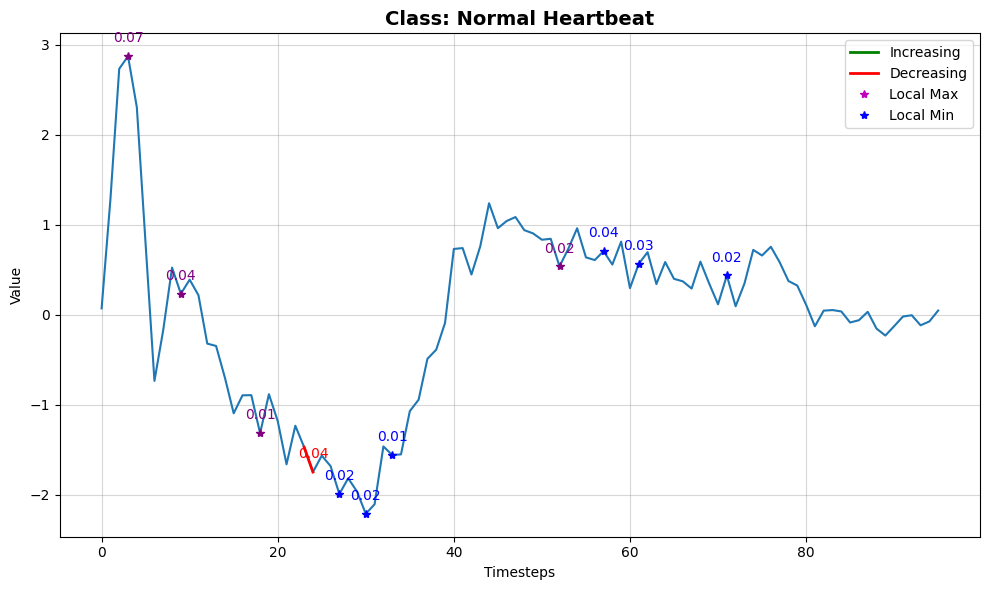

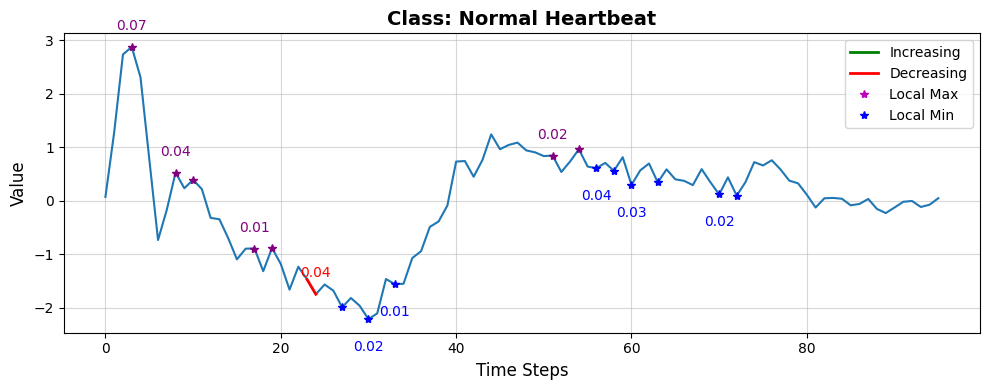

INFO:lomatce.explainer:Starting time series local explanation


Prediction probability : tensor([8.1907e-11, 1.0000e+00])
Myocardial Infarction:                      0.0000
Normal Heartbeat:                      1.0000


INFO:lomatce.explainer:Perturbed instances shape for classifier: (1001, 1, 96)
INFO:lomatce.explainer:Processing events for 1001 instances


Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 9896 samples)
Optimal number of clusters for Increasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 11621 samples)
Optimal number of clusters for Decreasing_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 17796 samples)
Optimal number of clusters for LocalMax_ch1: 19
Running on 5/20 CPU cores
Testing up to 20 clusters (adaptive based on 17690 samples)
Optimal number of clusters for LocalMin_ch1: 19


INFO:lomatce.explainer:Final data shape: (1001, 76) (instances x features)
INFO:lomatce.explainer:Number of instances: 1001
INFO:lomatce.explainer:Number of features (clusters): 76


INFO:lomatce.explainer:Applying linear regression
INFO:lomatce.explainer:R-Score (Local Fidelity): 0.18
INFO:lomatce.explainer:Local Prediction (Linear Model): 1.01
INFO:lomatce.explainer:Model Type: Ridge


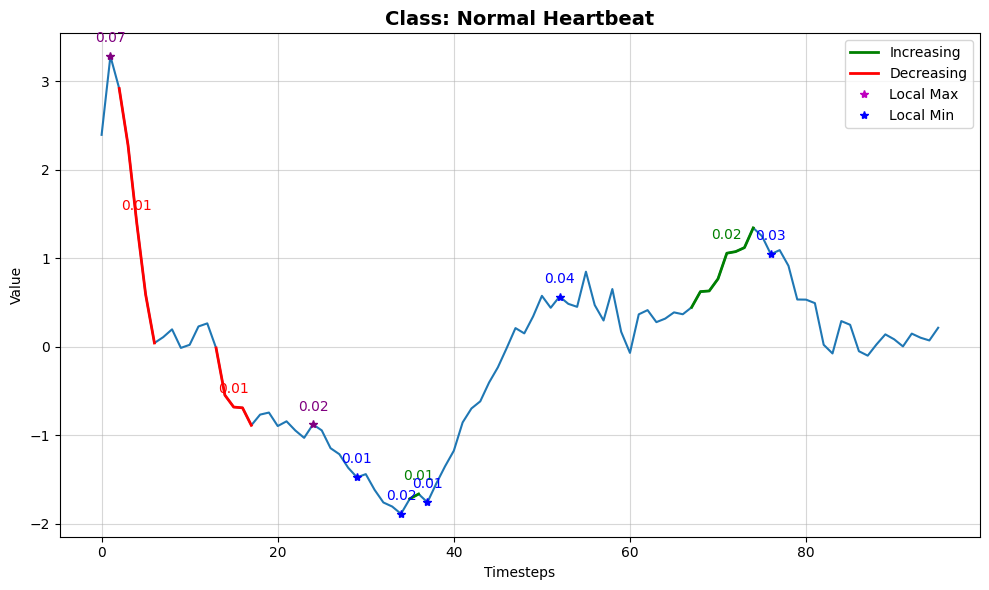

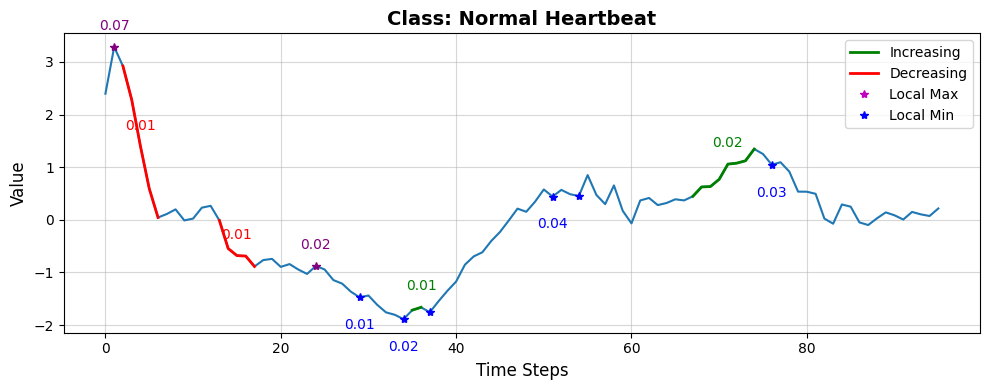

Prediction probability : tensor([5.9898e-09, 1.0000e+00])
Myocardial Infarction:                      0.0000
Normal Heartbeat:                      1.0000

📈 Global Faithfulness (Avg Local Fidelity): 0.5973

=== 📊 Final Visualization for All Classes ===



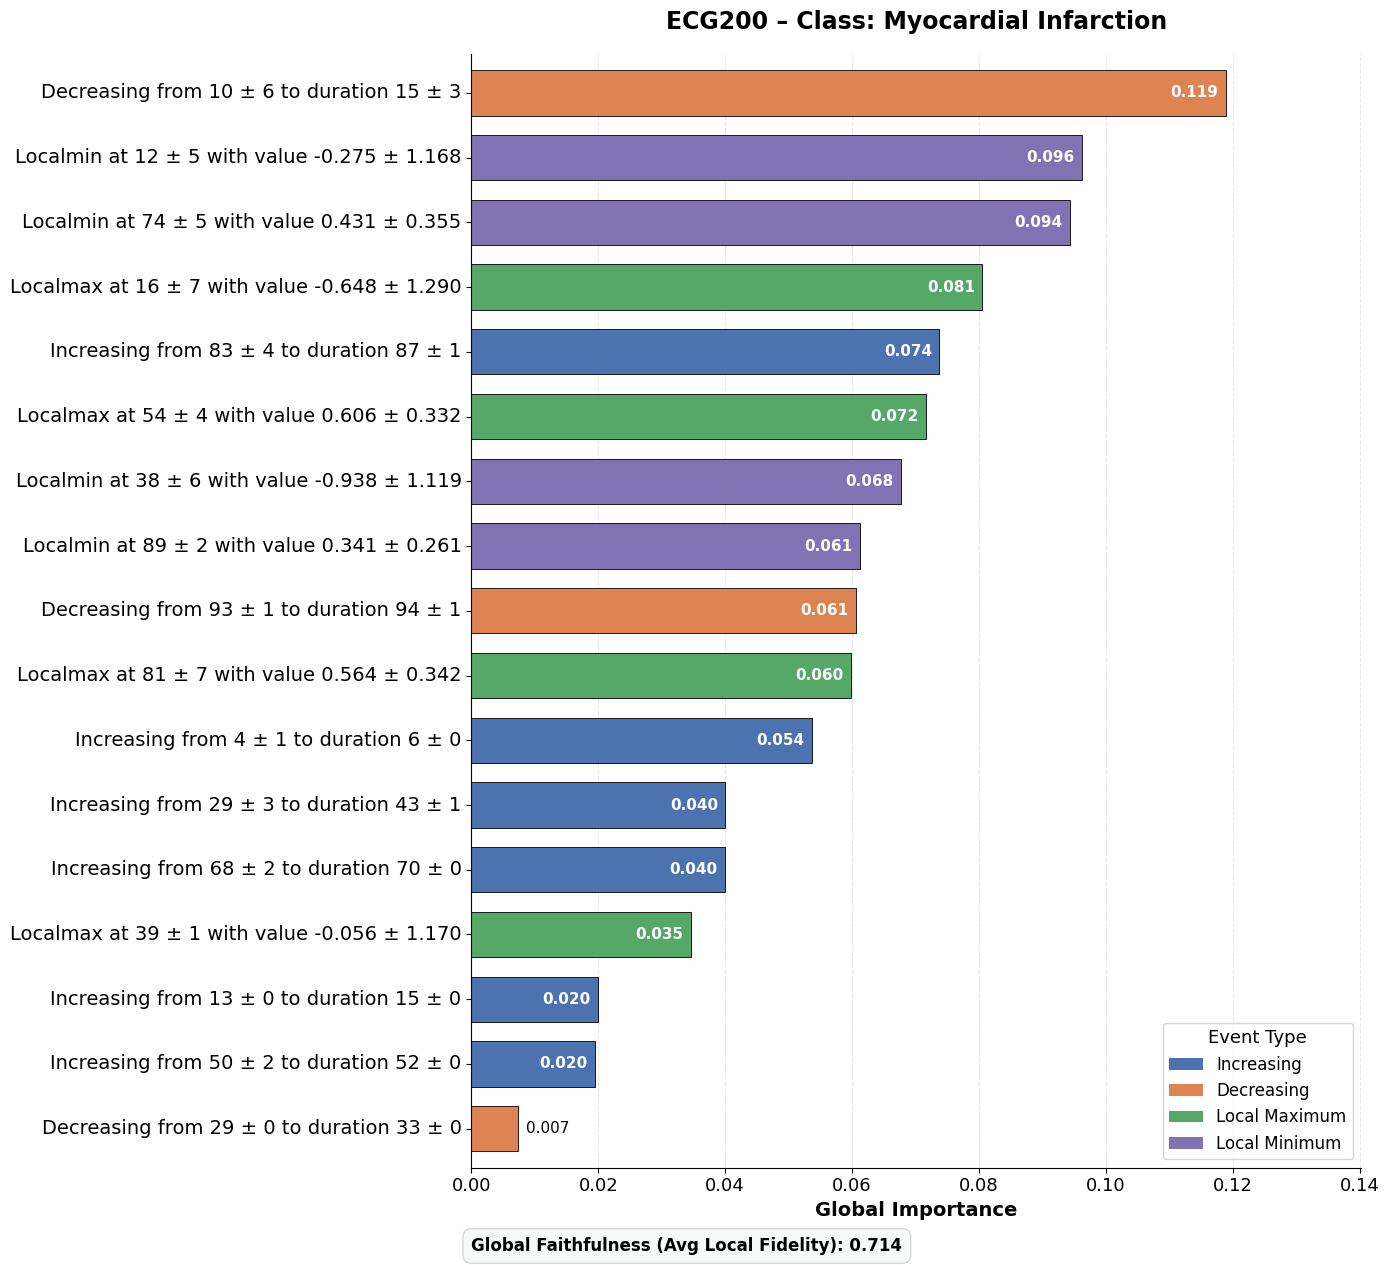

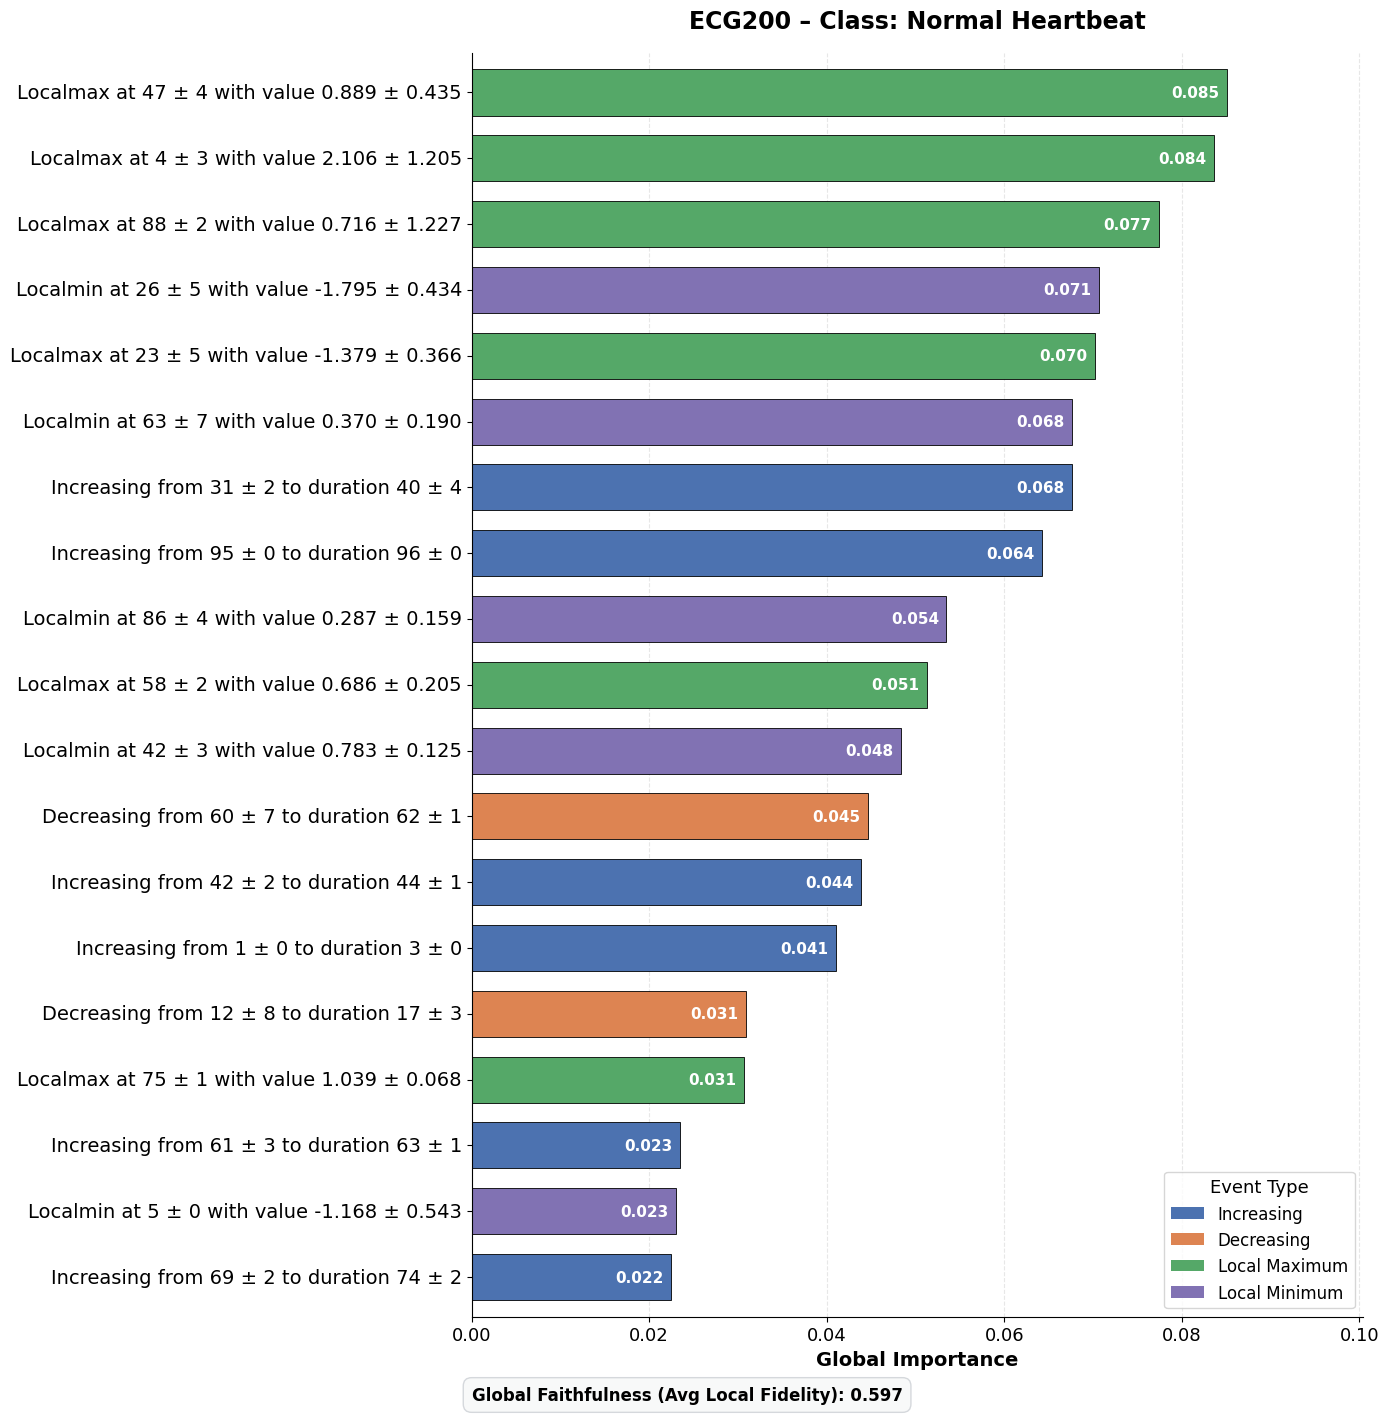

In [27]:
result_p95 = splomatce_explainer.run(X_merged, y_merged, n_per_class=20, B=20, merge_percentile=95)